# Prefix / KV-cache-drop — root cause analysis

This notebook consolidates two investigations into one story about the yz stack's
prefix-cache / throughput drop:

- **Part 1 — Load-state check (experiments 95 & 96).** Per-pod load state over time for the
  two 2026-07-11 yz captures (95 = external scrape of the `142` reference; 96 = internal
  `prod_latency_collector` on our router). Establishes the baseline behaviour and the
  us-vs-them picture.
- **Part 2 — Root-cause diagnosis (runs 102 & 103, cross-checked vs local bz and the pre-update
  run 96).** Shows the throughput collapse is driven by **GPU KV-cache saturation → LMCache P2P
  host-staging pin deadlock**, is specific to the yz large-prompt saturated soak, reproduces on a
  **pre-update** yz run (96), and is **not** caused by the observability update.

> The two parts were previously separate notebooks (`load-state-95-96` and
> `server-degradation-102-103`); their outputs are preserved as-is. Each part is self-contained —
> if you *Run All*, Part 2's setup cell re-establishes its own paths/helpers.

---
# Part 1 — Load-state check (experiments 95 & 96)
_(originally `load-state-95-96.ipynb`)_

# Load-state check: experiments 95 & 96

Quick look at the **load state over time, per pod** for the two new runs, using the
existing `metrics.jsonl` scraping helper (`experiment_analysis.load_experiment_prom_samples`).

- **Exp 95** - external scrape of `7.150.2.142:8077` (bare vLLM, `metrics.jsonl` only). Has latency **percentiles**.
- **Exp 96** - internal `prod_latency_collector` (router `10.50.156.65`). Also has `logs.json`, `vllm-logs/`, and **router-side** metrics; latency is **averages** only.

Note: this capture (2026-07-11) predates the `*_rpm` / cumulative-token fields, so
per-minute values are derived in-notebook as `per_sec * 60` (shown on the right axis of each rate panel).

## Canonical endpoint mapping

The three data sources identify pods differently, so every cell normalizes to one
canonical **endpoint** label. The IP<->name mapping is **confirmed** from each pod's
own `vllm.log` / `kv-sidecar.log` (not inferred from load):

| endpoint | server IP | role |
|---|---|---|
| `vllm-minimax-m2-0` | `7.150.6.33`  | ours |
| `vllm-minimax-m2-1` | `7.150.1.218` | ours |
| `them-142`          | `7.150.2.142` | external baseline (exp 95 target) |

- vLLM engine metrics (`metrics.jsonl`) are keyed by `IP:port:engine`; each of our
  servers runs **2 DP engines**, kept visible as `...:0` / `...:1`.
- `logs.json` and sidecar metrics are keyed by pod name.
- `label_endpoints()` (setup cell) rewrites each row's `instance` to the canonical
  `endpoint_engine` name and adds `endpoint` (server-level) + `instance_raw` columns,
  so plots/tables show consistent names instead of a mix of IPs and pod names.

In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from experiment_analysis import load_experiment_prom_samples

EXPERIMENTS_ROOT = "/home/saeid/llm-la/src/client/experiments_yz"  # yz runs 95/96 live here

# Per-second rate columns that also get a per-minute twin axis / companion.
_RATE_COLS = [
    "derived_rps", "request_success_per_sec",
    "prefill_tokens_per_sec", "gen_tokens_per_sec",
    "router_admission_rps", "router_outgoing_rps",
]
_RPM_MAP = {
    "derived_rps": "derived_rpm",
    "request_success_per_sec": "request_success_per_min",
    "prefill_tokens_per_sec": "prefill_tokens_per_min",
    "gen_tokens_per_sec": "gen_tokens_per_min",
    "router_admission_rps": "router_admission_rpm",
    "router_outgoing_rps": "router_outgoing_rpm",
}

# Canonical endpoint identity. The data mixes identifiers: vLLM engine metrics are
# keyed by IP:port:engine, while logs.json and sidecar metrics use the pod name.
# Mapping below is CONFIRMED from each pod's own vllm.log / kv-sidecar.log:
#   vllm-minimax-m2-0 -> 7.150.6.33   (ours)
#   vllm-minimax-m2-1 -> 7.150.1.218  (ours)
#   7.150.2.142                        -> them (external baseline)
ENDPOINT_MAP = {
    "7.150.6.33":        "vllm-minimax-m2-0",  # ours
    "7.150.1.218":       "vllm-minimax-m2-1",  # ours
    "7.150.2.142":       "them-142",           # external baseline
    "vllm-minimax-m2-0": "vllm-minimax-m2-0",
    "vllm-minimax-m2-1": "vllm-minimax-m2-1",
}
US_ENDPOINTS = ("vllm-minimax-m2-0", "vllm-minimax-m2-1")
THEM_ENDPOINTS = ("them-142",)


def _parse_endpoint(instance):
    """Map any identifier -> (endpoint_name, engine_rank_or_None).

    engine_rank is only kept for the IP:port:rank vLLM rows so we can still see the
    two DP engines per endpoint; name/sidecar rows collapse to the endpoint."""
    s = str(instance)
    for prefix, name in ENDPOINT_MAP.items():
        if s.startswith(prefix):
            rank = None
            if prefix.startswith("7.150"):
                m = re.search(r":(\d+)$", s)
                if m:
                    rank = m.group(1)
            return name, rank
    return None, None


def label_endpoints(df, col="instance"):
    """Add canonical `endpoint` (server-level) and `endpoint_engine` (with DP rank)
    columns, and rewrite the primary label `col` to the canonical name so every plot
    shows consistent endpoint names instead of a mix of IPs and pod names. The raw
    identifier is preserved in `instance_raw`."""
    df = df.copy()
    if col not in df.columns:
        return df
    ep, epe = [], []
    for v in df[col]:
        n, r = _parse_endpoint(v)
        ep.append(n)
        epe.append((f"{n}:{r}" if (n and r is not None) else n) if n else None)
    df["endpoint"] = ep
    df["endpoint_engine"] = epe
    df["instance_raw"] = df[col]
    df[col] = [e if e else raw for e, raw in zip(epe, df[col])]
    return df


def engine_rows(df, endpoints=None):
    """Keep only real vLLM engine metric rows (identified by a DP-engine rank, e.g.
    `...:0` / `...:1`), optionally restricted to the given canonical endpoints. Drops
    router (`172.16...`), model-name (`served-model-...`) and sidecar name-only rows
    that otherwise show up as flat zero lines in the per-pod plots."""
    d = df
    if "endpoint_engine" in d.columns:
        d = d[d["endpoint_engine"].astype(str).str.contains(":", na=False)]
    if endpoints is not None and "endpoint" in d.columns:
        d = d[d["endpoint"].isin(endpoints)]
    return d.copy()


def add_per_min(df):
    """This capture predates the *_rpm fields, so derive per-minute = per_sec * 60
    for whatever rate columns are present. Also add an elapsed-minutes x-axis."""
    df = df.copy()
    for rps, rpm in _RPM_MAP.items():
        if rps in df.columns and rpm not in df.columns:
            df[rpm] = df[rps] * 60.0
    if "ts" in df.columns and df["ts"].notna().any():
        t0 = df["ts"].min()
        df["elapsed_min"] = (df["ts"] - t0).dt.total_seconds() / 60.0
    df = label_endpoints(df, col="instance")  # unify IP/name -> canonical endpoint label
    return df


def load_summary(df):
    """Per-pod (instance) load-state summary (mean/max)."""
    cols = [c for c in [
        "requests_running", "requests_waiting",
        "derived_rps", "derived_rpm",
        "request_success_per_sec",
        "prefill_tokens_per_sec", "gen_tokens_per_sec",
        "kv_cache_usage_perc",
    ] if c in df.columns]
    if not cols or "instance" not in df.columns:
        return pd.DataFrame()
    return df.groupby("instance")[cols].agg(["mean", "max"]).round(2)


def _x60_twin(ax):
    """Right y-axis showing the same series in per-minute units (x60)."""
    lo, hi = ax.get_ylim()
    ax2 = ax.twinx()
    ax2.set_ylim(lo * 60.0, hi * 60.0)
    ax2.set_ylabel("per minute", fontsize=8)
    ax2.tick_params(labelsize=7)
    return ax2


def plot_series(df, cols, title):
    """One subplot per column; one line per pod (instance). Rate columns get a
    per-minute twin axis. Missing/all-NaN columns are skipped, NaNs dropped."""
    cols = [c for c in cols if c in df.columns and df[c].notna().any()]
    if not cols:
        print("no plottable columns for:", title)
        return
    x = "elapsed_min" if "elapsed_min" in df.columns else "ts"
    instances = sorted(df["instance"].dropna().unique())
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        for inst in instances:
            sub = df[df["instance"] == inst].dropna(subset=[col])
            if sub.empty:
                continue
            ax.plot(sub[x], sub[col], label=str(inst), linewidth=1.2)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=2, loc="upper right")
        if col in _RATE_COLS:
            _x60_twin(ax)
    axes[-1].set_xlabel("elapsed (min)" if x == "elapsed_min" else "time (UTC)")
    fig.suptitle(title, fontsize=13, y=1.001)
    fig.tight_layout()
    plt.show()


def plot_load_state(df, title, extra_cols=None):
    """Standard per-pod load-state panels (queue depth, rps, token throughput, kv)."""
    base_cols = [
        "requests_running", "requests_waiting",
        "derived_rps", "request_success_per_sec",
        "prefill_tokens_per_sec", "gen_tokens_per_sec",
        "kv_cache_usage_perc",
    ]
    if extra_cols:
        base_cols = base_cols + list(extra_cols)
    plot_series(df, base_cols, title)

## Section A - Exp 95 (external scrape / `7.150.2.142`)

Bare vLLM, `metrics.jsonl` only. `derived_rps` is the flow-balance incoming estimate
(`request_success_per_sec + d(running+waiting)/dt`). Latency percentiles are available here.

exp 95 rows: 12762 | pods: ['them-142:0', 'them-142:1']


requests_running       requests_waiting      derived_rps        \
                       mean   max             mean  max        mean   max   
instance                                                                    
them-142:0             2.01  13.0              0.0  1.0        0.03  0.36   
them-142:1             1.79  14.0              0.0  1.0        0.03  0.36   

           derived_rpm        request_success_per_sec        \
                  mean    max                    mean   max   
instance                                                      
them-142:0        1.80  21.71                    0.03  0.36   
them-142:1        1.66  21.71                    0.03  0.36   

           prefill_tokens_per_sec           gen_tokens_per_sec          \
                             mean       max               mean     max   
instance                                                                 
them-142:0                1293.05  22207.79              38.80  132.84   
them-142:1                1197.32  25217.00              32.69  116.75   

           kv_cache_usage_perc        
                          mean   max  
instance                              
them-142:0                0.06  0.73  
them-142:1                0.05  0.66

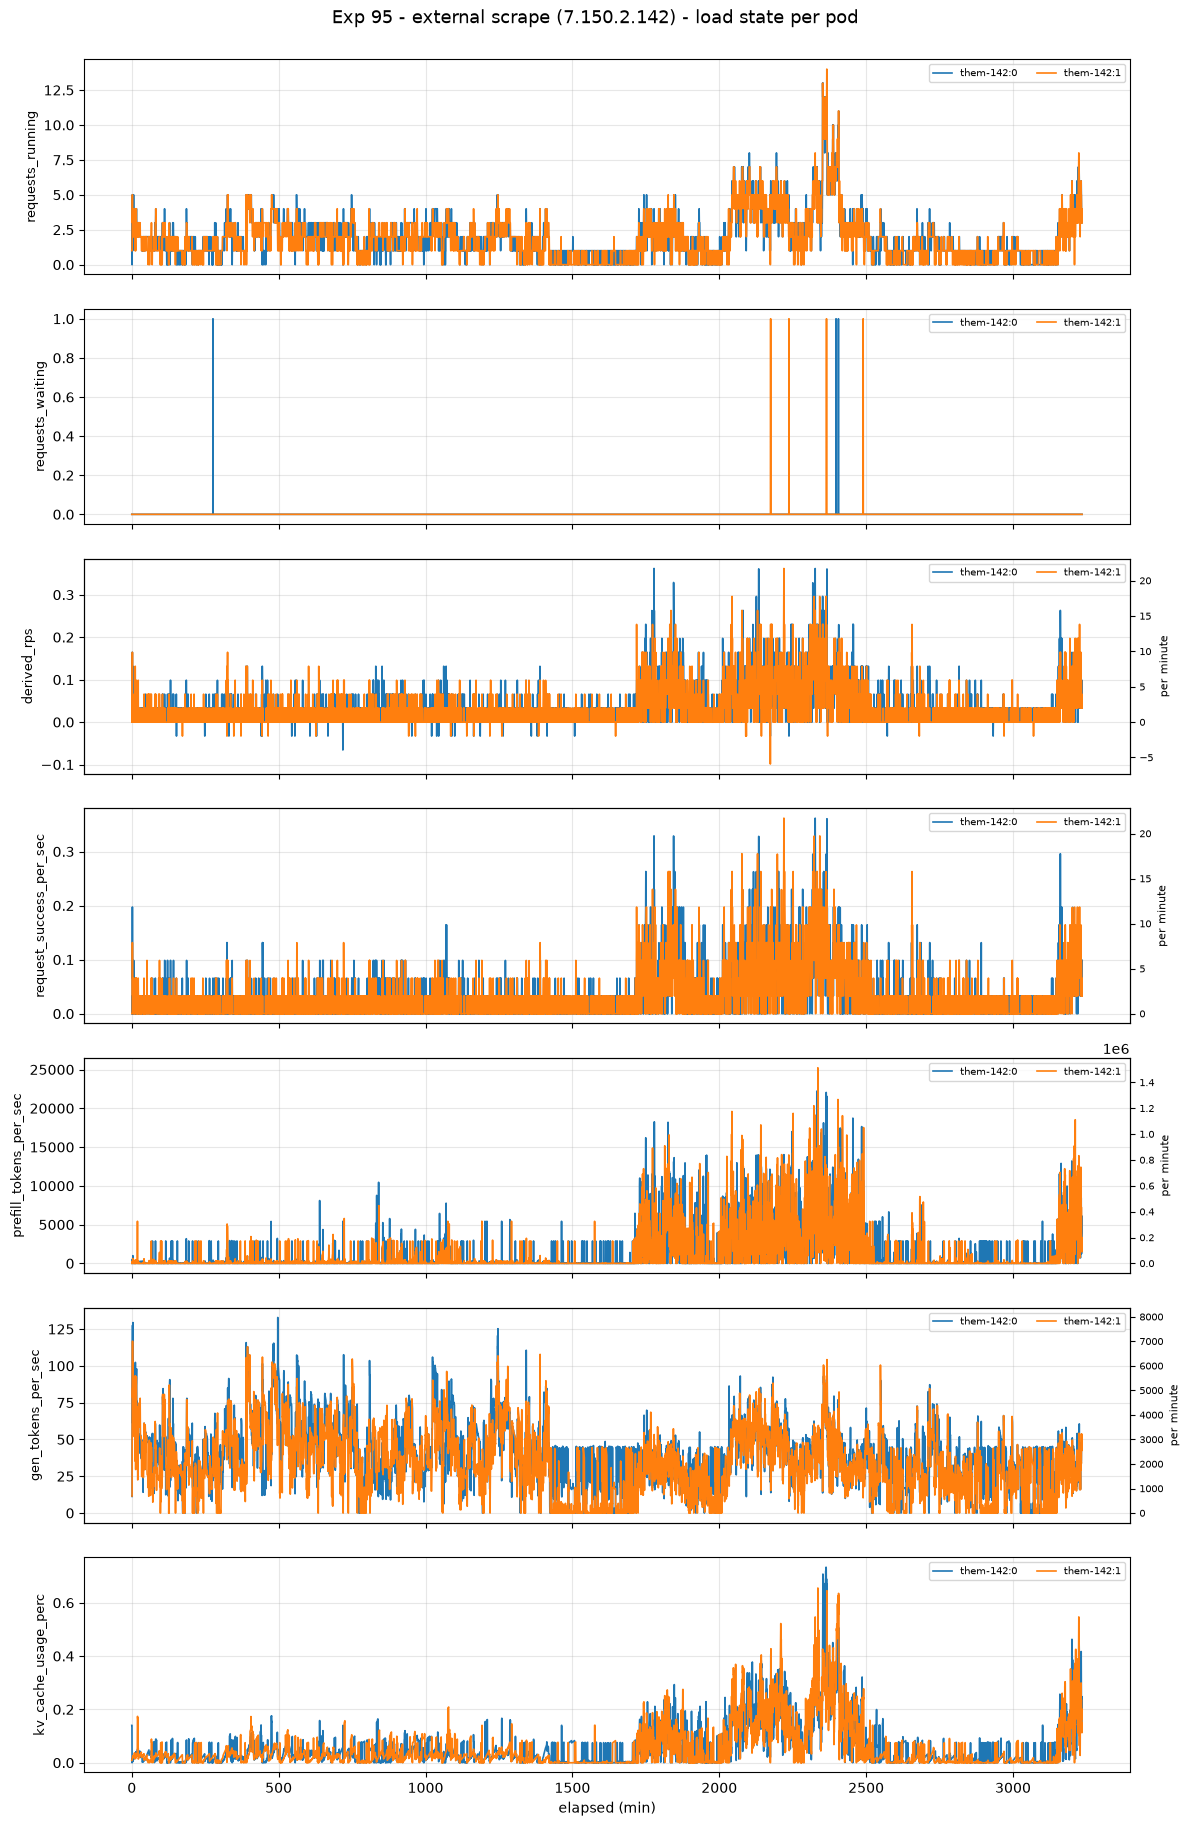

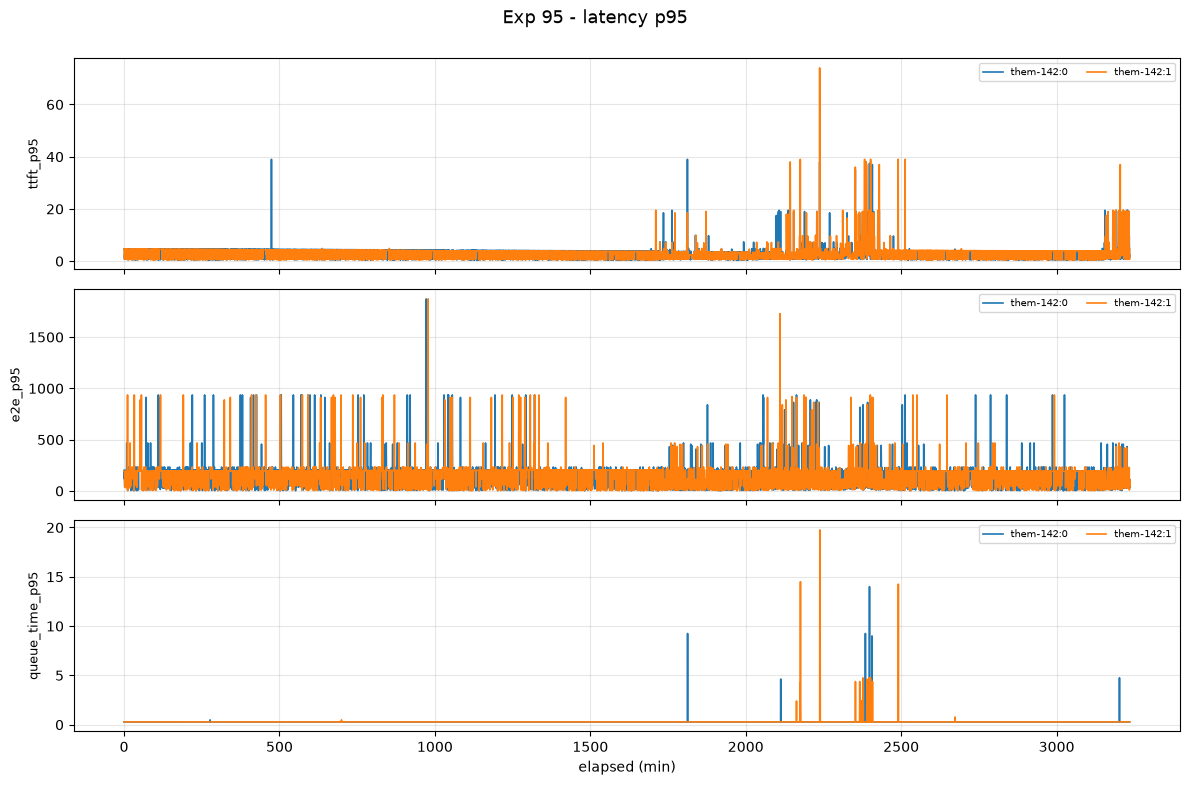

In [2]:
df95 = add_per_min(load_experiment_prom_samples(exp_id=95, experiments_root=EXPERIMENTS_ROOT))
print("exp 95 rows:", len(df95), "| pods:", sorted(df95["instance"].dropna().unique()))
display(load_summary(df95))
plot_load_state(df95, "Exp 95 - external scrape (7.150.2.142) - load state per pod")
plot_series(df95, ["ttft_p95", "e2e_p95", "queue_time_p95"], "Exp 95 - latency p95")

## Section B - Exp 96 (internal collector / router `10.50.156.65`)

Internal `prod_latency_collector`. Adds router-side metrics (`router_admission_rps`,
`router_outgoing_rps`, `router_queue_length`) which let us cross-check `derived_rps`
against the true incoming rate. Latency is averages only here.

exp 96 rows: 64400 | pods: ['172.16.135.4:8080', 'served-model-minmax', 'them-142:0', 'them-142:1', 'vllm-minimax-m2-0', 'vllm-minimax-m2-0:0', 'vllm-minimax-m2-0:1', 'vllm-minimax-m2-1', 'vllm-minimax-m2-1:0', 'vllm-minimax-m2-1:1']


requests_running       requests_waiting       derived_rps  \
                                mean   max             mean   max        mean   
instance                                                                        
vllm-minimax-m2-0:0             3.15  19.0             0.00   2.0        0.02   
vllm-minimax-m2-0:1             2.88  16.0             0.04   3.0        0.01   
vllm-minimax-m2-1:0             4.12  16.0             0.13  13.0        0.02   
vllm-minimax-m2-1:1             3.72  24.0             0.03  12.0        0.02   

                          derived_rpm        request_success_per_sec        \
                      max        mean    max                    mean   max   
instance                                                                     
vllm-minimax-m2-0:0  0.41        1.01  24.59                    0.02  0.34   
vllm-minimax-m2-0:1  0.31        0.87  18.46                    0.01  0.31   
vllm-minimax-m2-1:0  0.38        1.37  22.76                    0.02  0.38   
vllm-minimax-m2-1:1  0.31        1.06  18.62                    0.02  0.31   

                    prefill_tokens_per_sec           gen_tokens_per_sec  \
                                      mean       max               mean   
instance                                                                  
vllm-minimax-m2-0:0                 842.97  22801.34              24.53   
vllm-minimax-m2-0:1                 738.73  22067.59              19.31   
vllm-minimax-m2-1:0                1166.22  27520.55              28.67   
vllm-minimax-m2-1:1                 849.64  22432.54              24.32   

                             
                        max  
instance                     
vllm-minimax-m2-0:0  117.38  
vllm-minimax-m2-0:1  114.39  
vllm-minimax-m2-1:0  114.59  
vllm-minimax-m2-1:1  110.64

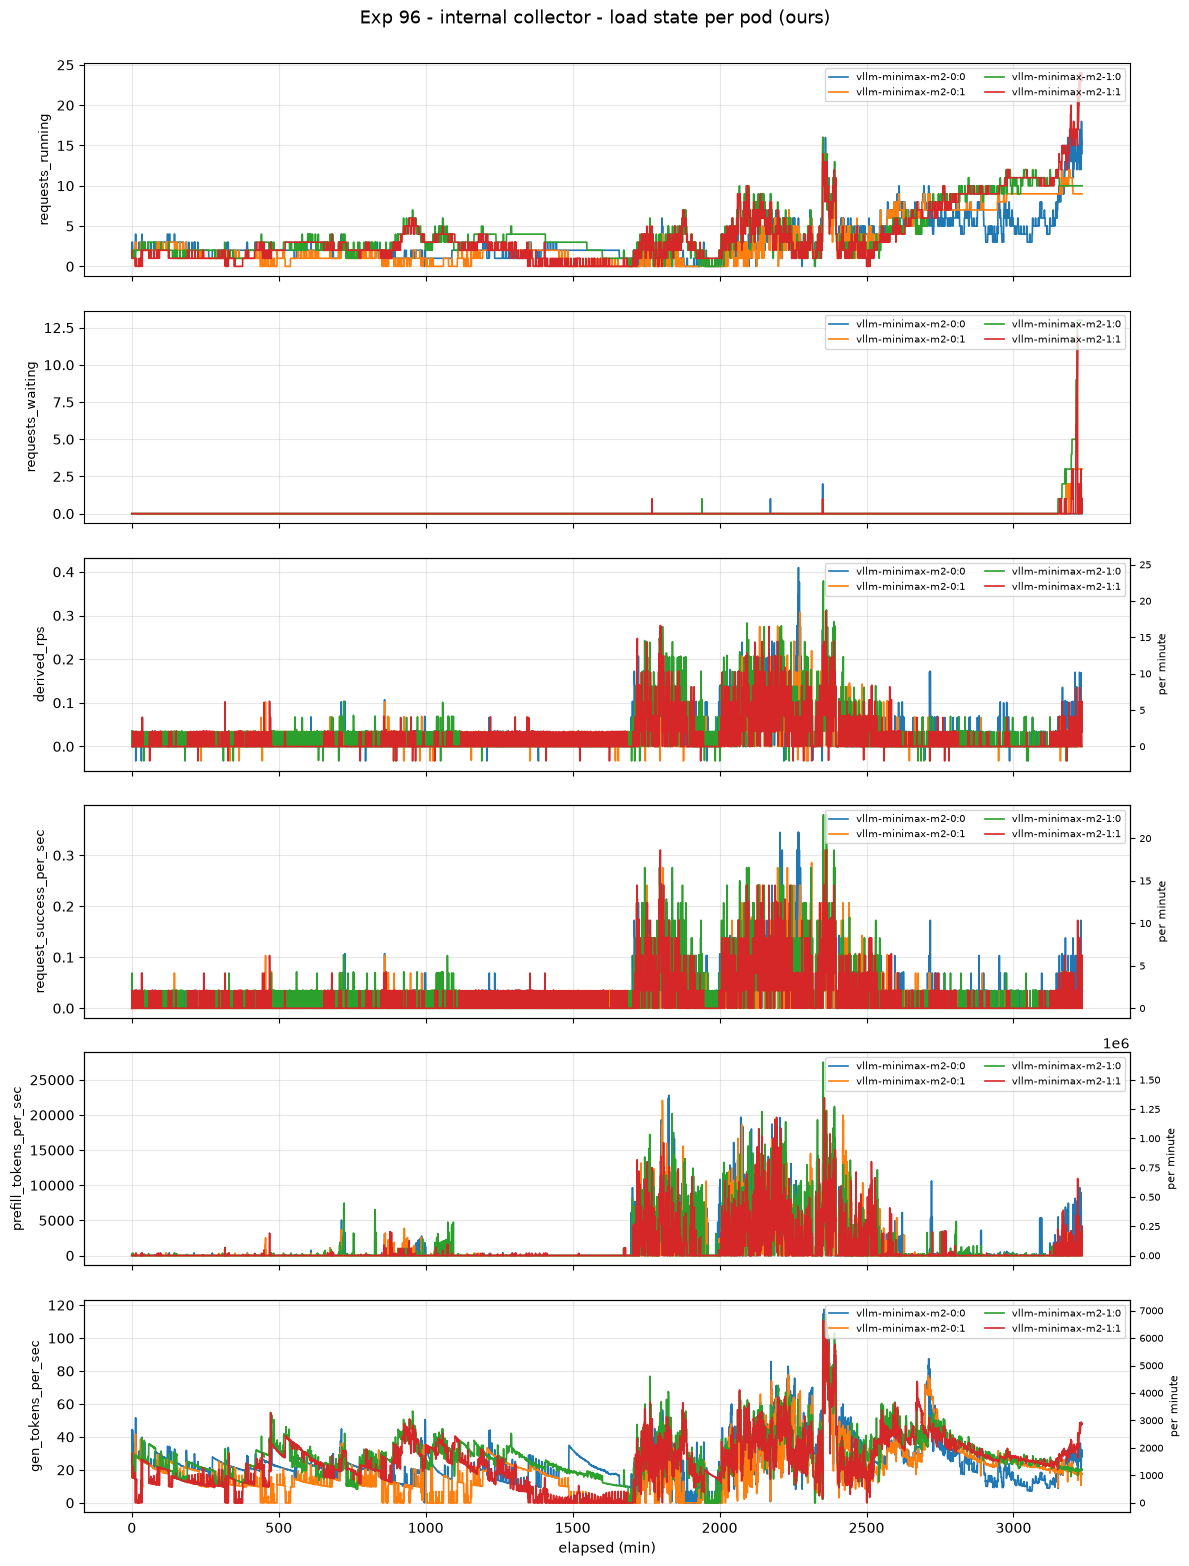

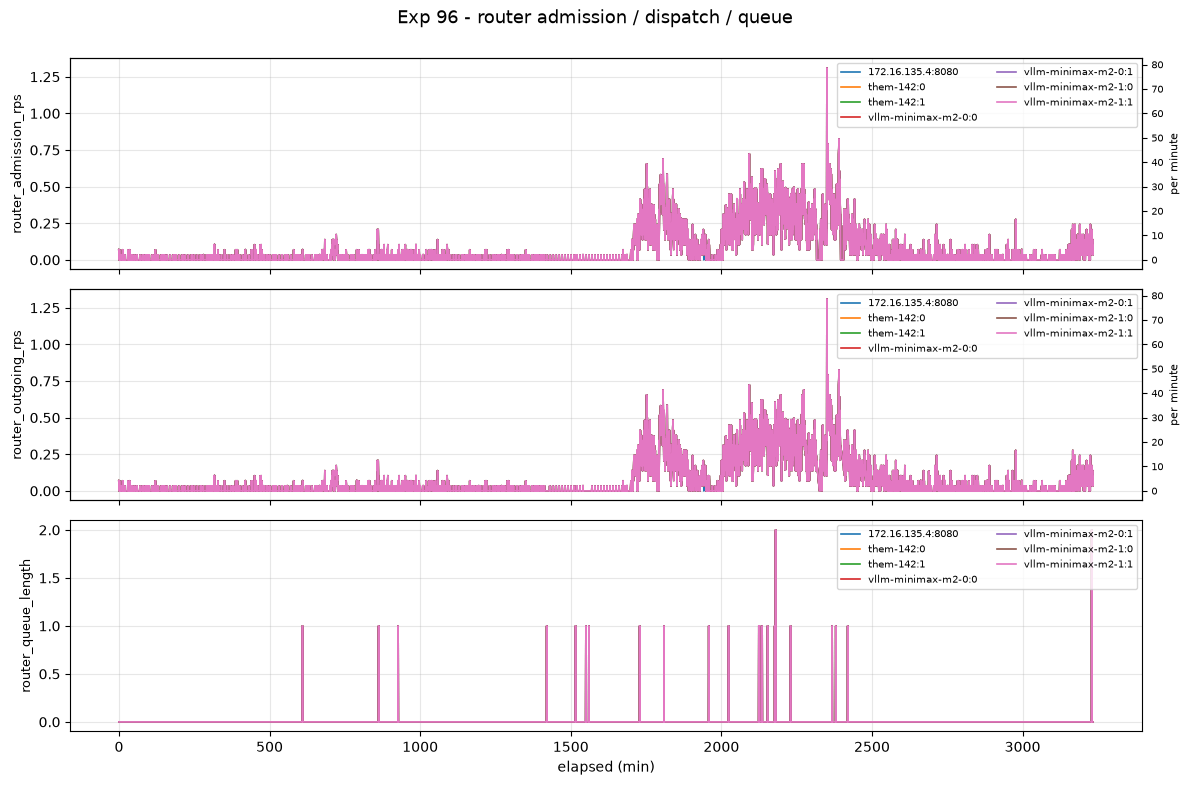

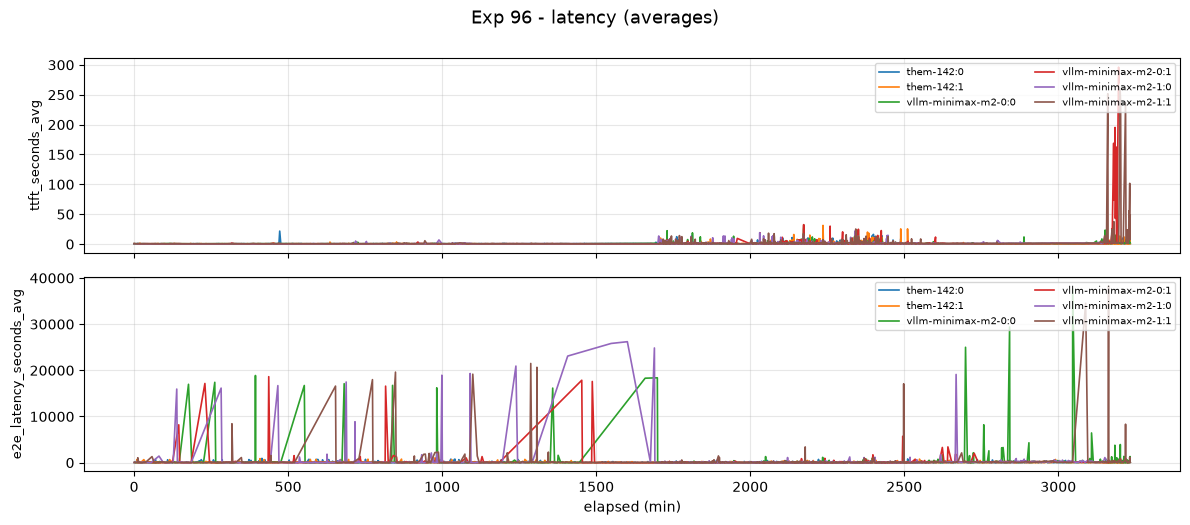

In [3]:
df96 = add_per_min(load_experiment_prom_samples(exp_id=96, experiments_root=EXPERIMENTS_ROOT))
print("exp 96 rows:", len(df96), "| pods:", sorted(df96["instance"].dropna().unique()))
display(load_summary(engine_rows(df96, US_ENDPOINTS)))
plot_load_state(engine_rows(df96, US_ENDPOINTS),
                "Exp 96 - internal collector - load state per pod (ours)")
# router-side panel (only the internal collector has these)
plot_series(df96, ["router_admission_rps", "router_outgoing_rps", "router_queue_length"],
            "Exp 96 - router admission / dispatch / queue")
plot_series(df96, ["ttft_seconds_avg", "e2e_latency_seconds_avg"], "Exp 96 - latency (averages)")

### Exp 96 - per-endpoint view (from `logs.json`, ours only)

The router's per-request truth (`logs.json`) is tagged with `endpoint_id` (our pods
`vllm-minimax-m2-0` / `-1`). This gives a finer, request-accurate per-endpoint breakdown than the
metrics scrape: request counts, token volume, latency percentiles, and KV-hit rate per endpoint,
plus load and cumulative work over time. (Exp 95 / them has no `logs.json`, so this is ours only.)

exp 96 logs.json requests: 14056 | endpoints: ['vllm-minimax-m2-0', 'vllm-minimax-m2-1']


,requests,prompt_tokens,completion_tokens,ttft_p50,ttft_p95,e2e_p50,e2e_p95,kv_hit_rate,req_share_%
endpoint_id,,,,,,,,,
vllm-minimax-m2-0,6087,322311405,2721568,1.654,5.282,17.947,205.622,0.242,43.3
vllm-minimax-m2-1,7969,417089776,3264381,1.810,4.875,19.685,182.954,0.184,56.7


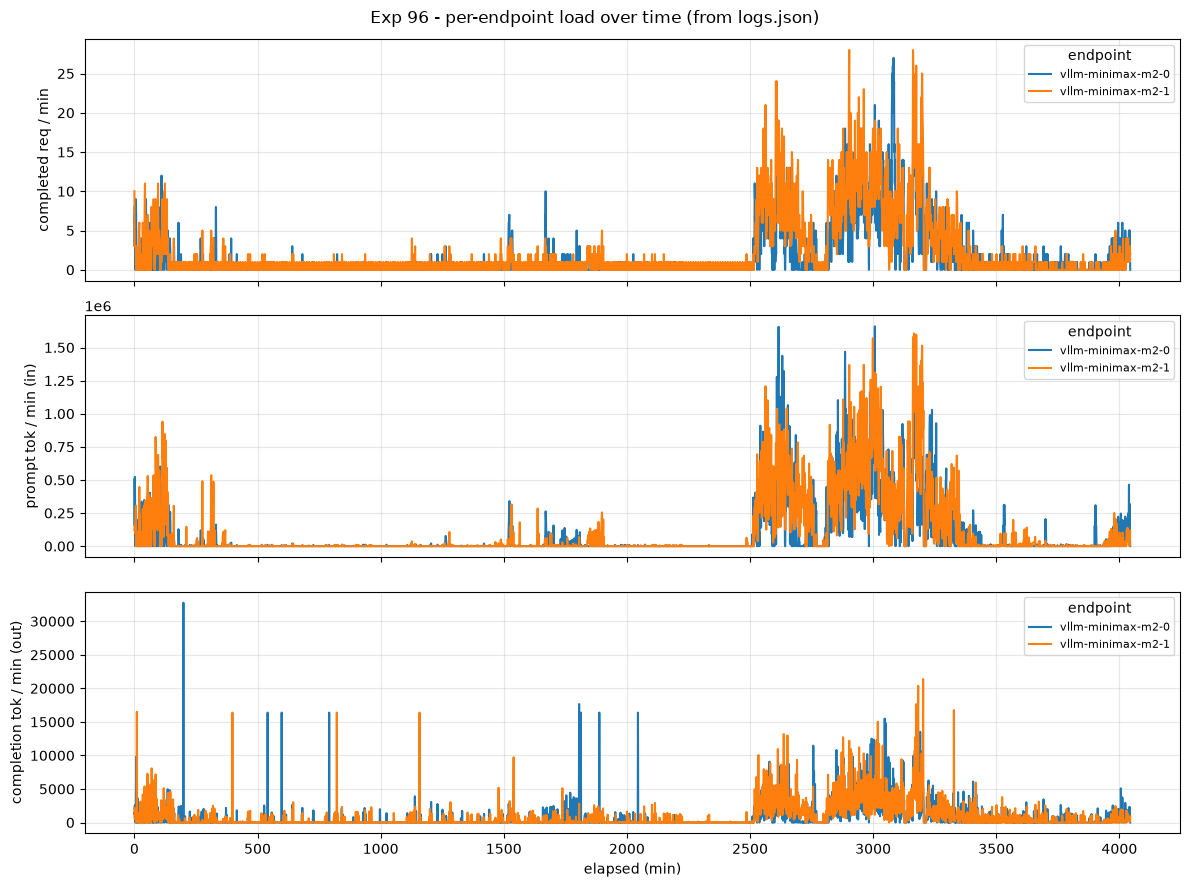

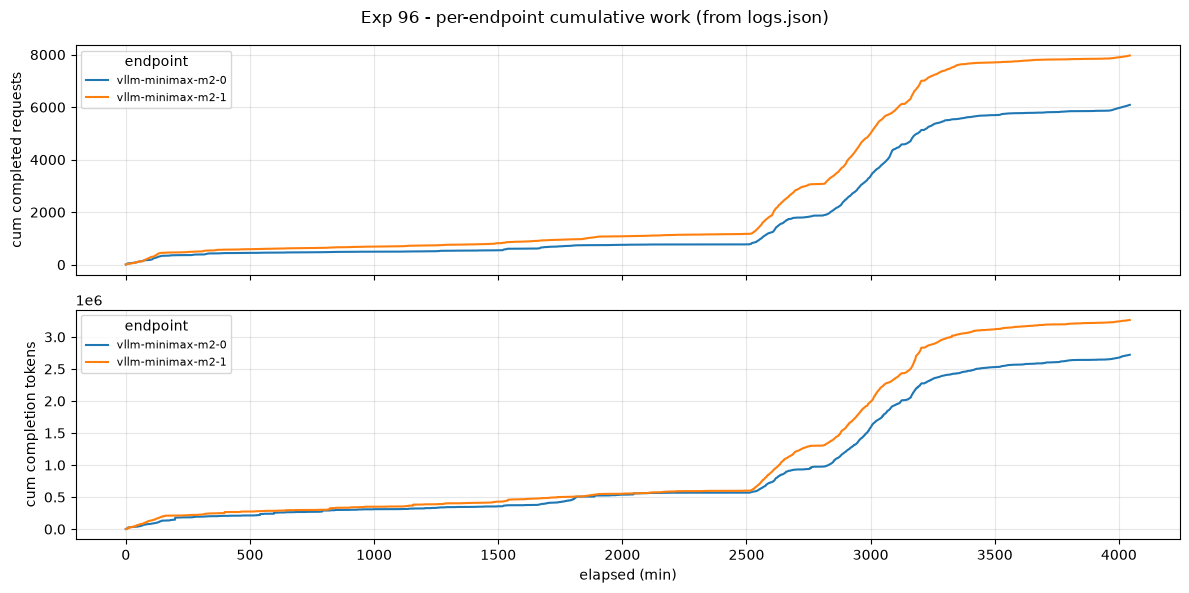

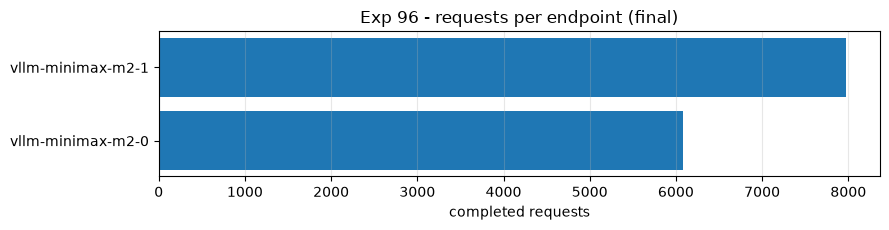

In [4]:
import json as _json
from pathlib import Path as _Path


def load_endpoint_logs(exp_id, experiments_root=EXPERIMENTS_ROOT):
    """Load per-request logs.json into a DataFrame (endpoint_id-tagged, ours only)."""
    p = _Path(experiments_root) / str(exp_id) / "logs.json"
    if not p.is_file():
        print("no logs.json for exp", exp_id)
        return pd.DataFrame()
    rows = []
    with open(p) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(_json.loads(line))
                except Exception:
                    pass
    df = pd.DataFrame(rows)
    for c in ("t0_wall", "t1_wall"):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], unit="s", utc=True)
    return df


def endpoint_summary(df):
    """Per-endpoint request/token/latency/KV summary."""
    if df.empty or "endpoint_id" not in df.columns:
        return pd.DataFrame()
    g = df.groupby("endpoint_id")
    out = pd.DataFrame({
        "requests": g.size(),
        "prompt_tokens": g["prompt_tokens"].sum(),
        "completion_tokens": g["completion_tokens"].sum(),
        "ttft_p50": g["ttft_s"].median(),
        "ttft_p95": g["ttft_s"].quantile(0.95),
        "e2e_p50": g["end_to_end_s"].median(),
        "e2e_p95": g["end_to_end_s"].quantile(0.95),
        "kv_hit_rate": g["kv_hit"].mean() if "kv_hit" in df.columns else np.nan,
    })
    out["req_share_%"] = (out["requests"] / out["requests"].sum() * 100).round(1)
    return out.round(3)


ep96 = load_endpoint_logs(96)
print("exp 96 logs.json requests:", len(ep96),
      "| endpoints:", sorted(ep96["endpoint_id"].dropna().unique()))
display(endpoint_summary(ep96))

# per-endpoint time series, bucketed by completion time (1-min buckets)
d = ep96.dropna(subset=["t1_wall"]).copy()
d["elapsed_min"] = ((d["t1_wall"] - d["t1_wall"].min()).dt.total_seconds() / 60.0).astype(int)
full = range(int(d["elapsed_min"].min()), int(d["elapsed_min"].max()) + 1)

rate = d.groupby(["elapsed_min", "endpoint_id"]).size().unstack(fill_value=0).reindex(full, fill_value=0)
tok_in = d.groupby(["elapsed_min", "endpoint_id"])["prompt_tokens"].sum().unstack(fill_value=0).reindex(full, fill_value=0)
tok_out = d.groupby(["elapsed_min", "endpoint_id"])["completion_tokens"].sum().unstack(fill_value=0).reindex(full, fill_value=0)

# load over time (per endpoint)
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
rate.plot(ax=axes[0]); axes[0].set_ylabel("completed req / min")
tok_in.plot(ax=axes[1]); axes[1].set_ylabel("prompt tok / min (in)")
tok_out.plot(ax=axes[2]); axes[2].set_ylabel("completion tok / min (out)")
for a in axes:
    a.grid(alpha=0.3); a.legend(fontsize=8, title="endpoint")
axes[-1].set_xlabel("elapsed (min)")
fig.suptitle("Exp 96 - per-endpoint load over time (from logs.json)")
fig.tight_layout(); plt.show()

# cumulative over time (per endpoint)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
rate.cumsum().plot(ax=axes[0]); axes[0].set_ylabel("cum completed requests")
tok_out.cumsum().plot(ax=axes[1]); axes[1].set_ylabel("cum completion tokens")
for a in axes:
    a.grid(alpha=0.3); a.legend(fontsize=8, title="endpoint")
axes[-1].set_xlabel("elapsed (min)")
fig.suptitle("Exp 96 - per-endpoint cumulative work (from logs.json)")
fig.tight_layout(); plt.show()

# balance (final requests per endpoint)
cnt = d["endpoint_id"].value_counts()
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.barh(cnt.index.astype(str), cnt.values); ax.invert_yaxis()
ax.set_xlabel("completed requests"); ax.grid(axis="x", alpha=0.3)
ax.set_title("Exp 96 - requests per endpoint (final)")
fig.tight_layout(); plt.show()

# Cumulative load over time (total work done per pod)

Instantaneous load (running/waiting/rps) shows the *rate*; this section shows the **running total**
per pod, which is what reveals load balance / fairness:

- **`cum_requests`** - cumulative completed requests, taken directly from the monotonic
  `request_success_total` counter (zero-based per pod).
- **`cum_prefill_tokens` / `cum_gen_tokens`** - cumulative incoming/outgoing tokens, obtained by
  time-integrating the per-second token rates (this capture has no cumulative token counters).

A flat gap between pod curves = imbalance; parallel curves = balanced load.

In [5]:
def add_cumulative(df):
    """Add per-pod cumulative work-done columns:
      - cum_requests: zero-based cumulative completed requests (from request_success_total)
      - cum_prefill_tokens / cum_gen_tokens: time-integral of the per-sec token rates
    Rows without those source fields (e.g. router/served-model rows) get NaN and are
    naturally skipped when plotting."""
    df = df.sort_values(["instance", "ts"]).copy()
    parts = []
    for _inst, g in df.groupby("instance", sort=False):
        g = g.copy()
        if "request_success_total" in g.columns and g["request_success_total"].notna().any():
            base = g["request_success_total"].dropna().iloc[0]
            g["cum_requests"] = g["request_success_total"] - base
        # resolution-safe seconds between scrapes (astype(int64) breaks under
        # pandas datetime64[us], silently scaling the integral by 1000).
        dt = g["ts"].diff().dt.total_seconds().fillna(0.0).clip(lower=0.0)
        for rate_col, cum_col in [("prefill_tokens_per_sec", "cum_prefill_tokens"),
                                  ("gen_tokens_per_sec", "cum_gen_tokens")]:
            if rate_col in g.columns:
                g[cum_col] = (g[rate_col].fillna(0.0) * dt).cumsum()
        parts.append(g)
    return pd.concat(parts, ignore_index=True)


_CUM_COLS = ["cum_requests", "cum_prefill_tokens", "cum_gen_tokens"]


def cumulative_totals(df):
    """Final cumulative total per pod (load-balance / fairness at a glance)."""
    cols = [c for c in _CUM_COLS if c in df.columns and df[c].notna().any()]
    if not cols or "instance" not in df.columns:
        return pd.DataFrame()
    out = df.sort_values("ts").groupby("instance")[cols].last().dropna(how="all")
    if "cum_requests" in out.columns and out["cum_requests"].sum() > 0:
        out["req_share_%"] = (out["cum_requests"] / out["cum_requests"].sum() * 100).round(1)
    return out.round(1)


def plot_cumulative(df, title):
    """Cumulative work-done curves, one line per pod."""
    cols = [c for c in _CUM_COLS if c in df.columns and df[c].notna().any()]
    if not cols:
        print("no cumulative columns for:", title)
        return
    x = "elapsed_min" if "elapsed_min" in df.columns else "ts"
    instances = sorted(df["instance"].dropna().unique())
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.8 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        for inst in instances:
            sub = df[df["instance"] == inst].dropna(subset=[col])
            if sub.empty:
                continue
            ax.plot(sub[x], sub[col], label=str(inst), linewidth=1.4)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=2, loc="upper left")
    axes[-1].set_xlabel("elapsed (min)" if x == "elapsed_min" else "time (UTC)")
    fig.suptitle(title, fontsize=13, y=1.001)
    fig.tight_layout()
    plt.show()


def plot_cumulative_balance(df, title):
    """Bar chart of final cumulative completed requests per pod (imbalance view)."""
    tot = cumulative_totals(df)
    if tot.empty or "cum_requests" not in tot.columns:
        print("no cum_requests for:", title)
        return
    tot = tot.sort_values("cum_requests", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 0.5 * len(tot) + 1.5))
    ax.barh([str(i) for i in tot.index], tot["cum_requests"])
    ax.invert_yaxis()
    ax.set_xlabel("cumulative completed requests")
    ax.grid(True, axis="x", alpha=0.3)
    ax.set_title(title, fontsize=12)
    fig.tight_layout()
    plt.show()

### Exp 95 - cumulative load per pod

,cum_requests,cum_prefill_tokens,cum_gen_tokens,req_share_%
instance,,,,
them-142:0,5819.0,251035520.2,7531940.3,52.0
them-142:1,5381.0,232443595.8,6346541.1,48.0


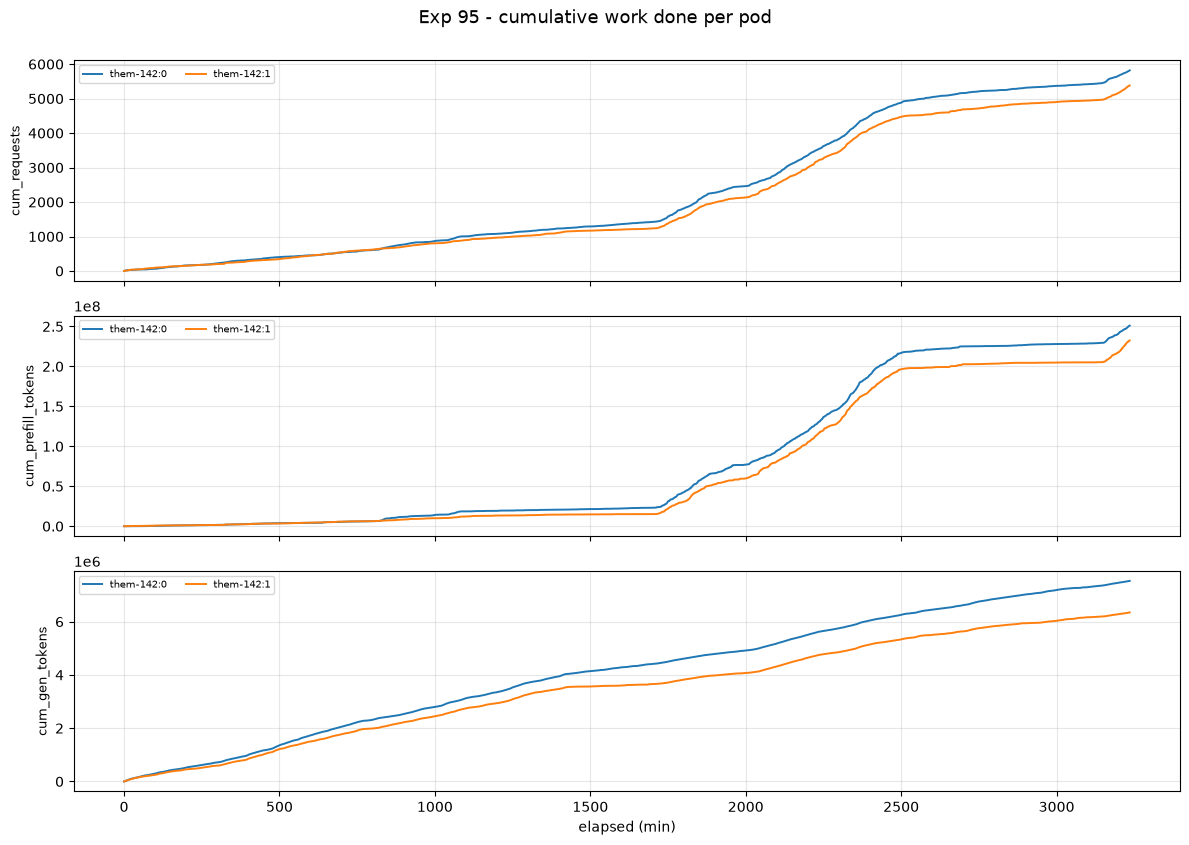

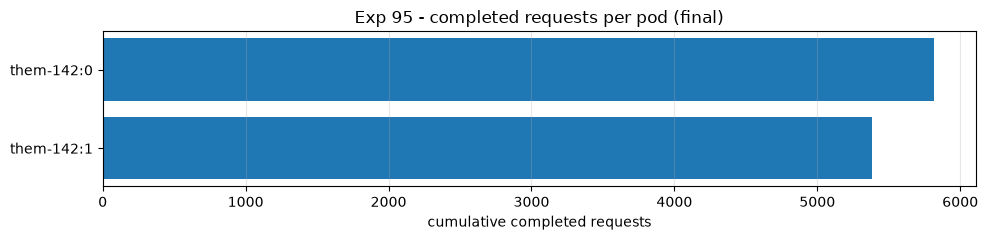

In [6]:
df95c = add_cumulative(engine_rows(df95))  # them-142 engines only (drops non-engine rows)
display(cumulative_totals(df95c))
plot_cumulative(df95c, "Exp 95 - cumulative work done per pod")
plot_cumulative_balance(df95c, "Exp 95 - completed requests per pod (final)")

### Exp 96 - cumulative load per pod

Non-engine rows (router / served-model) have no `request_success_total` or token rates, so they
drop out automatically and only the vLLM engines appear.

,cum_requests,cum_prefill_tokens,cum_gen_tokens,req_share_%
instance,,,,
vllm-minimax-m2-0:0,3273.0,163606322.5,4758529.1,23.5
vllm-minimax-m2-0:1,2812.0,143357929.5,3746989.0,20.2
vllm-minimax-m2-1:0,4423.0,226331060.3,5563268.4,31.8
vllm-minimax-m2-1:1,3409.0,164892272.4,4717752.0,24.5


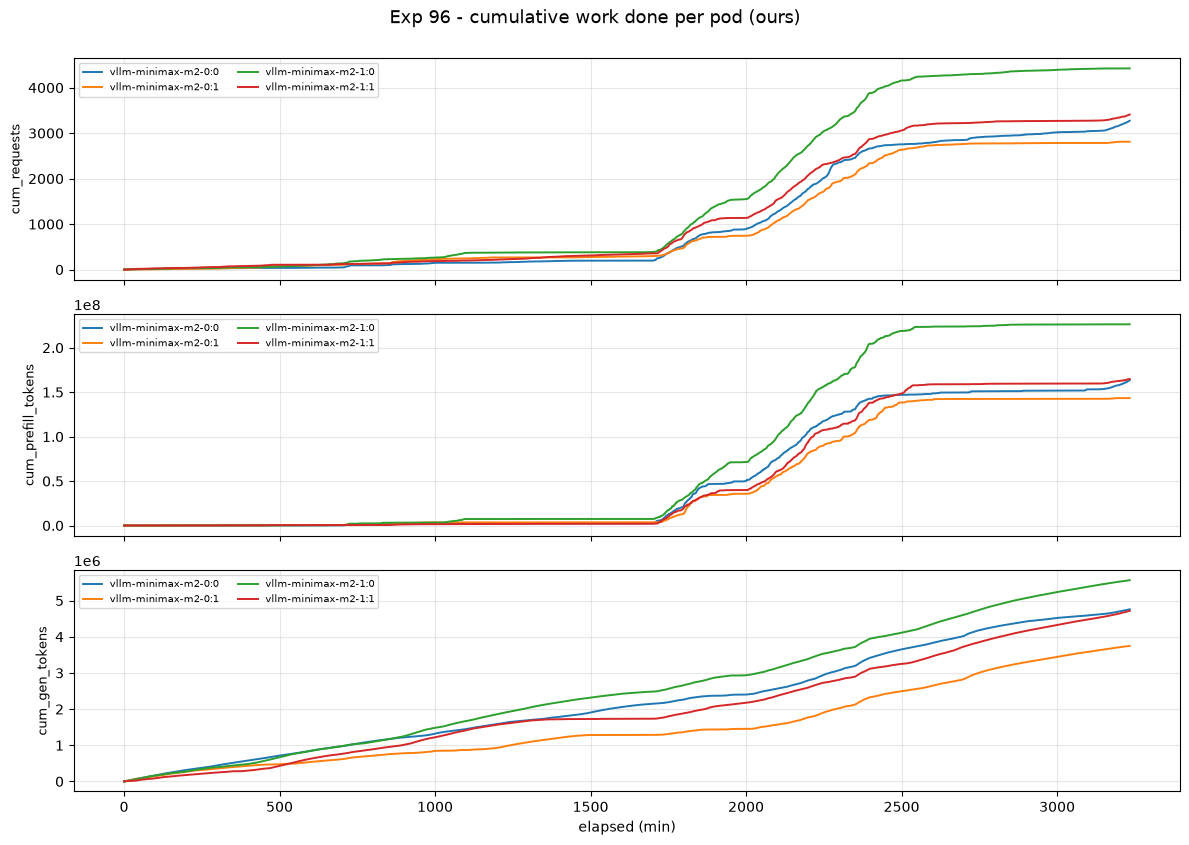

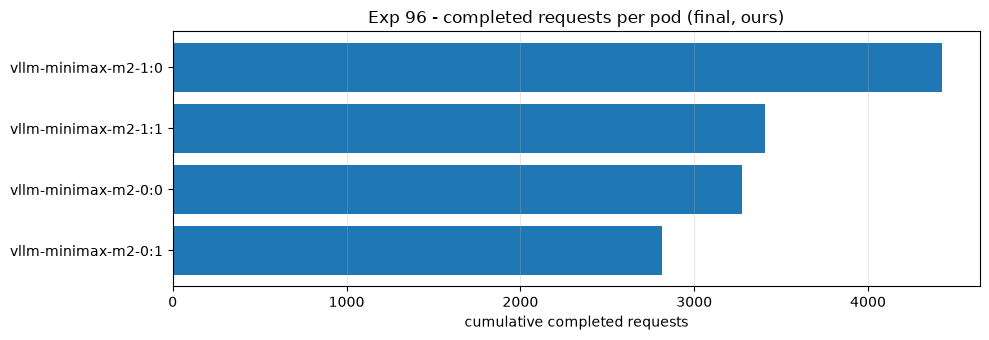

In [7]:
df96c = add_cumulative(engine_rows(df96, US_ENDPOINTS))  # our 4 engines only (no them-142/router/name rows)
display(cumulative_totals(df96c))
plot_cumulative(df96c, "Exp 96 - cumulative work done per pod (ours)")
plot_cumulative_balance(df96c, "Exp 96 - completed requests per pod (final, ours)")

# Them vs Us - total requests over time

Fleet-aggregated comparison of **them** vs **us**, aligned by elapsed time from each run's start.

- **them** = external baseline server `7.150.2.142` (2 engines), measured by exp 95.
- **us** = our two servers `7.150.1.218` + `7.150.6.33` (2 engines each = 4 engines), taken from exp 96.

Note: exp 96's collector also scraped the 142 server, but 142 is *them*, so it is **excluded** from
the "us" aggregation here. Cumulative curve uses the monotonic `request_success_total` counter summed
across the relevant pods per tick (completed requests as the proxy for total requests handled).
Totals are reported over the **common overlapping window** as well as each full run.

us endpoints: ['vllm-minimax-m2-0', 'vllm-minimax-m2-1'] | engines: ['vllm-minimax-m2-0', 'vllm-minimax-m2-0:0', 'vllm-minimax-m2-0:1', 'vllm-minimax-m2-1', 'vllm-minimax-m2-1:0', 'vllm-minimax-m2-1:1']


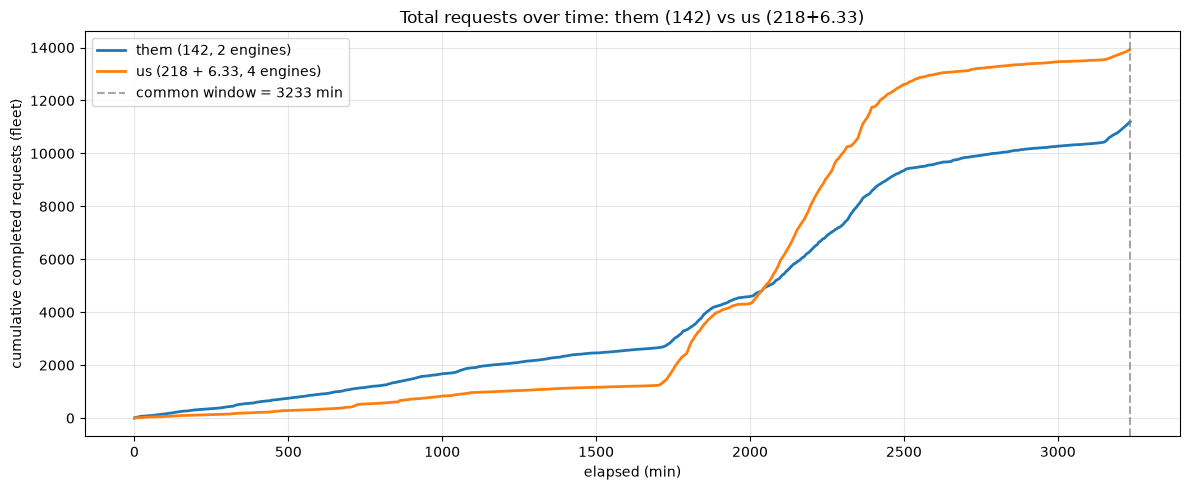

Common overlapping window: 3233.5 min
Over the common window, us handled 1.24x the requests of them (us per-engine: 3479, them per-engine: 5593).


,engines,duration_min,completed_@3233min,avg_rps_common,completed_full_run
run,,,,,
them (142),2,3235.2,11185,0.058,11200
us (218+6.33),4,3233.5,13917,0.072,13917


In [8]:
def fleet_series(df, col):
    """Sum a per-pod column across pods per tick -> fleet time series + elapsed_min."""
    if col not in df.columns:
        return pd.DataFrame(columns=["ts", "elapsed_min", col])
    d = df[df[col].notna()]
    if d.empty:
        return pd.DataFrame(columns=["ts", "elapsed_min", col])
    s = d.groupby("ts", as_index=False)[col].sum().sort_values("ts")
    t0 = s["ts"].min()
    s["elapsed_min"] = (s["ts"] - t0).dt.total_seconds() / 60.0
    return s


def fleet_cum_requests(df):
    """Fleet cumulative completed requests over time (zero-based)."""
    s = fleet_series(df, "request_success_total")
    if s.empty:
        return s
    s["cum_requests"] = s["request_success_total"] - s["request_success_total"].iloc[0]
    return s


def _cum_at(s, w):
    return float(np.interp(w, s["elapsed_min"], s["cum_requests"]))


# them = the 142 server (exp 95 measured only this).
them = fleet_cum_requests(df95)
# us = only our two endpoints within exp 96 (them-142 excluded; non-engine rows carry no
# request_success_total and drop out of the sum).
us_df = df96[df96["endpoint"].isin(US_ENDPOINTS)]
us = fleet_cum_requests(us_df)
print("us endpoints:", sorted(us_df["endpoint"].dropna().unique()),
      "| engines:", sorted(us_df["instance"].dropna().unique()))

# --- cumulative comparison ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(them["elapsed_min"], them["cum_requests"], lw=2, label="them (142, 2 engines)")
ax.plot(us["elapsed_min"], us["cum_requests"], lw=2, label="us (218 + 6.33, 4 engines)")
W = min(them["elapsed_min"].max(), us["elapsed_min"].max())
ax.axvline(W, ls="--", color="grey", alpha=0.7, label=f"common window = {W:.0f} min")
ax.set_xlabel("elapsed (min)")
ax.set_ylabel("cumulative completed requests (fleet)")
ax.grid(alpha=0.3)
ax.legend()
ax.set_title("Total requests over time: them (142) vs us (218+6.33)")
fig.tight_layout()
plt.show()

# --- totals summary ---
them_W, us_W = _cum_at(them, W), _cum_at(us, W)
them_full, us_full = them["cum_requests"].iloc[-1], us["cum_requests"].iloc[-1]
summary = pd.DataFrame({
    "run": ["them (142)", "us (218+6.33)"],
    "engines": [2, 4],
    "duration_min": [round(them["elapsed_min"].max(), 1), round(us["elapsed_min"].max(), 1)],
    f"completed_@{W:.0f}min": [round(them_W), round(us_W)],
    "avg_rps_common": [round(them_W / (W * 60), 3), round(us_W / (W * 60), 3)],
    "completed_full_run": [round(them_full), round(us_full)],
}).set_index("run")
print(f"Common overlapping window: {W:.1f} min")
if them_W > 0:
    print(f"Over the common window, us handled {us_W/them_W:.2f}x the requests of them "
          f"(us per-engine: {us_W/4:.0f}, them per-engine: {them_W/2:.0f}).")
display(summary)

# Them vs Us - latency & request size (short-request hypothesis)

Request counts are broadly similar, but them (142) show much lower e2e latency. We
test whether that's because they serve **shorter / cheaper requests**.

Method (same prometheus measurement for both, so the comparison is apples-to-apples):

- **e2e latency**: vLLM server-side average (`e2e_latency_seconds_avg`) is comparable
  for both. Percentiles differ in origin - them expose vLLM's own `e2e_p50/p95`, while
  for us only the router-side `router_e2e_p50/p95` exists (includes queue wait, so it
  is an upper bound, not directly comparable to them's server-side percentiles).
- **request size**: output tokens = integral of `gen_tokens_per_sec`; input/prompt
  tokens = integral of `prefill_tokens_per_sec`; divided by completed requests
  (`request_success_total` counter delta) for a duration-independent tokens/request.

**Findings**

- e2e latency: **CONFIRMED** - us server-side avg is ~6.9x them.
- **Prompt size is the driver**: them send ~25k input tok/req vs our ~40k (them ≈ 0.63x).
  Shorter prompts -> much less prefill work -> lower TTFT/e2e. Output volume is similar
  (~2.3k vs ~2.6k tok/req), so they are *not* simply cutting generations.
- **Overload amplifier (us only)**: `logs.json` shows we *deliver* only ~483 output
  tok/req but vLLM *generates* ~2.6k - a ~5x preemption/recompute blow-up, itself a
  symptom of the overload behind our high e2e. (them have no logs, but their light load
  implies little recompute.)

e2e_p50/p95: them = vLLM server-side; us = router-side (includes queue wait -> not directly comparable).
CONFIRMED: server-side avg e2e for us is 3.9x them.


,engines,e2e_avg_s (vLLM),ttft_avg_s (vLLM),e2e_p50_s,e2e_p95_s
run,,,,,
them (142),2,53.911,1.211,35.127,152.619
us (m2-0+m2-1),4,207.712,1.896,56.921,134.800


,completed_requests,gen_tokens_total,prefill_tokens_total,out_tokens_per_req,in_tokens_per_req
run,,,,,
them (142),11200.0,13878481.4,483479116.0,1239.2,43167.8
us (m2-0+m2-1),13917.0,18786538.5,698187584.7,1349.9,50168.0


Prompt (input) size:  them = 43,168 tok/req  vs  us = 50,168 tok/req  (them = 0.86x us -> them send SHORTER prompts).
Output (vLLM-gen):    them = 1,239 tok/req  vs  us = 1,350 tok/req  (them = 0.92x us -> similar output volume).


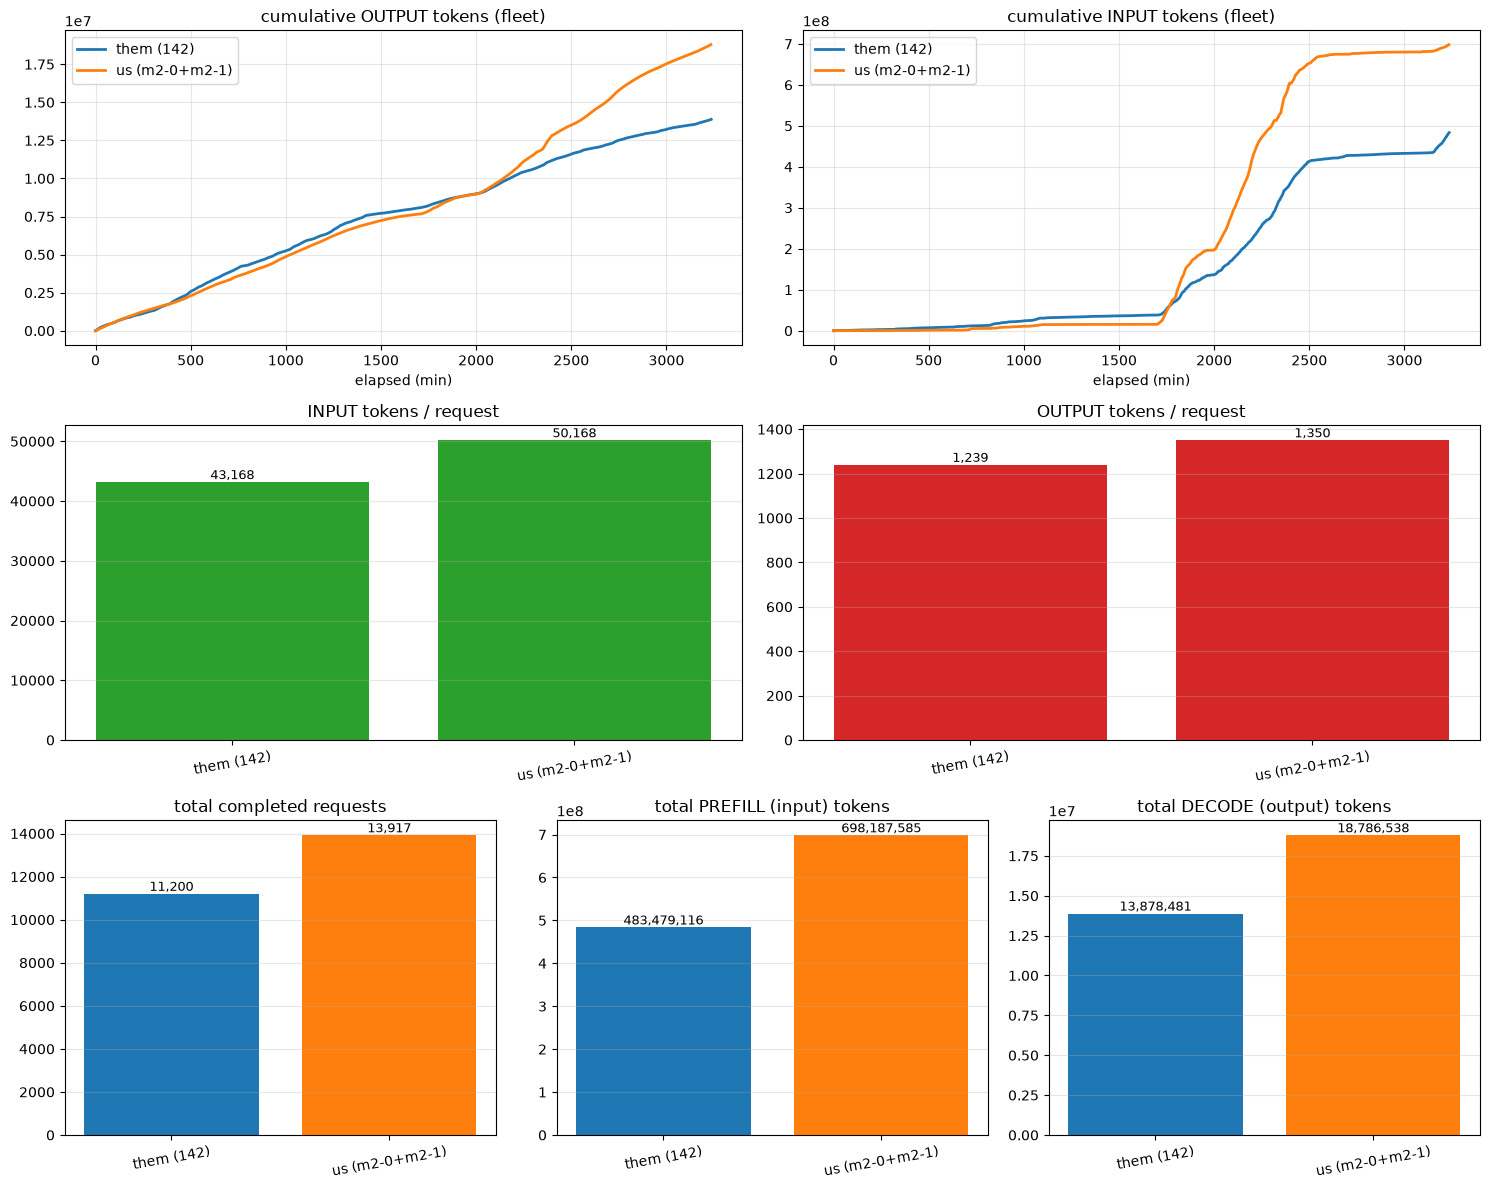

In [9]:
them_e = engine_rows(df95)                # 142 (external), 2 engines
us_e   = engine_rows(df96, US_ENDPOINTS)  # ours, 4 engines


def _rowmean(df, col):
    return float(df[col].dropna().mean()) if (col in df.columns and df[col].notna().any()) else np.nan


# --- 1) e2e latency (confirm the gap) ---
lat = pd.DataFrame({
    "run": ["them (142)", "us (m2-0+m2-1)"],
    "engines": [them_e["endpoint_engine"].nunique(), us_e["endpoint_engine"].nunique()],
    "e2e_avg_s (vLLM)":  [_rowmean(them_e, "e2e_latency_seconds_avg"), _rowmean(us_e, "e2e_latency_seconds_avg")],
    "ttft_avg_s (vLLM)": [_rowmean(them_e, "ttft_seconds_avg"),        _rowmean(us_e, "ttft_seconds_avg")],
    # them: vLLM server-side percentiles; us: only router-side available (incl. queue wait)
    "e2e_p50_s":         [_rowmean(them_e, "e2e_p50"), _rowmean(df96, "router_e2e_p50")],
    "e2e_p95_s":         [_rowmean(them_e, "e2e_p95"), _rowmean(df96, "router_e2e_p95")],
}).set_index("run").round(3)
print("e2e_p50/p95: them = vLLM server-side; us = router-side (includes queue wait -> not directly comparable).")
if not np.isnan(lat["e2e_avg_s (vLLM)"]).any():
    _r = lat["e2e_avg_s (vLLM)"]["us (m2-0+m2-1)"] / lat["e2e_avg_s (vLLM)"]["them (142)"]
    print(f"CONFIRMED: server-side avg e2e for us is {_r:.1f}x them.")
display(lat)


# --- 2) cumulative tokens & per-request size (same prometheus method for BOTH) ---
# request counts: absolute request_success_total delta (reliable, no rate/window drift).
# token volumes: integral of the per-sec rates (add_cumulative, now resolution-safe).
def _totals(dfc):
    t = cumulative_totals(dfc)
    g = lambda c: float(t[c].sum()) if c in t.columns else np.nan
    return g("cum_requests"), g("cum_gen_tokens"), g("cum_prefill_tokens")


them_c, us_c = add_cumulative(them_e), add_cumulative(us_e)
tr, tg, tp = _totals(them_c)
ur, ug, up = _totals(us_c)
tok = pd.DataFrame({
    "run": ["them (142)", "us (m2-0+m2-1)"],
    "completed_requests":   [tr, ur],
    "gen_tokens_total":     [tg, ug],
    "prefill_tokens_total": [tp, up],
    "out_tokens_per_req":   [tg / tr, ug / ur],   # output / response length
    "in_tokens_per_req":    [tp / tr, up / ur],   # input / prompt length
}).set_index("run").round(1)
display(tok)
print(f"Prompt (input) size:  them = {tp/tr:,.0f} tok/req  vs  us = {up/ur:,.0f} tok/req  "
      f"(them = {(tp/tr)/(up/ur):.2f}x us -> them send SHORTER prompts).")
print(f"Output (vLLM-gen):    them = {tg/tr:,.0f} tok/req  vs  us = {ug/ur:,.0f} tok/req  "
      f"(them = {(tg/tr)/(ug/ur):.2f}x us -> similar output volume).")


# --- 3) plots ---
def _fleet_cum(dfc, col):
    d = dfc[dfc[col].notna()] if col in dfc.columns else dfc.iloc[0:0]
    if d.empty:
        return pd.DataFrame(columns=["elapsed_min", col])
    s = d.groupby("ts", as_index=False)[col].sum().sort_values("ts")
    s["elapsed_min"] = (s["ts"] - s["ts"].min()).dt.total_seconds() / 60.0
    return s


fig, axd = plt.subplot_mosaic(
    [["cum_out", "cum_out", "cum_out", "cum_in", "cum_in", "cum_in"],
     ["in_req", "in_req", "in_req", "out_req", "out_req", "out_req"],
     ["t_req", "t_req", "t_prefill", "t_prefill", "t_decode", "t_decode"]],
    figsize=(15, 12))
# row 1: cumulative token volumes over time
for col, key, ttl in [("cum_gen_tokens", "cum_out", "cumulative OUTPUT tokens (fleet)"),
                      ("cum_prefill_tokens", "cum_in", "cumulative INPUT tokens (fleet)")]:
    ax = axd[key]
    for c, lab, color in [(them_c, "them (142)", "#1f77b4"), (us_c, "us (m2-0+m2-1)", "#ff7f0e")]:
        s = _fleet_cum(c, col)
        ax.plot(s["elapsed_min"], s[col], lw=2, label=lab, color=color)
    ax.set_xlabel("elapsed (min)"); ax.set_title(ttl); ax.grid(alpha=0.3); ax.legend()
# row 2: input and output tokens/request as separate bars (linear scale)
for col, key, ttl, color in [("in_tokens_per_req",  "in_req",  "INPUT tokens / request",  "#2ca02c"),
                            ("out_tokens_per_req", "out_req", "OUTPUT tokens / request", "#d62728")]:
    ax = axd[key]
    ax.bar(tok.index, tok[col], color=color)
    ax.set_title(ttl); ax.grid(alpha=0.3, axis="y")
    ax.tick_params(axis="x", rotation=10)
    for i, v in enumerate(tok[col]):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
# row 3: totals - completed requests, prefill (input) tokens, decode (output) tokens
for col, key, ttl in [("completed_requests",   "t_req",     "total completed requests"),
                      ("prefill_tokens_total", "t_prefill", "total PREFILL (input) tokens"),
                      ("gen_tokens_total",      "t_decode",  "total DECODE (output) tokens")]:
    ax = axd[key]
    ax.bar(tok.index, tok[col], color=["#1f77b4", "#ff7f0e"])
    ax.set_title(ttl); ax.grid(alpha=0.3, axis="y")
    ax.tick_params(axis="x", rotation=10)
    for i, v in enumerate(tok[col]):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout(); plt.show()

# Validate: logs.json (exact) vs prometheus metrics (us / exp 96)

For **our** run we have `logs.json` with the exact per-request `prompt_tokens` (prefill)
and `completion_tokens` (decode), so we can check how close the prometheus rate-integral
gets to the true totals.

- **requests** & **prefill/input tokens** should match closely (small integration error).
- **decode/output tokens** will differ: `vllm:generation_tokens_total` counts tokens the
  engine *generated* (including preemption/recompute), while `logs.json` counts tokens
  actually *delivered* to the client - so metrics > logs is expected and is a preemption
  signal, not an error.

,logs (exact),metrics (prom),metrics/logs,diff_%
quantity,,,,
completed requests,14056.0,13917.0,0.990,-1.0
prefill (input) tokens,739401181.0,698187585.0,0.944,-5.6
decode (output) tokens,5985949.0,18786538.0,3.138,213.8


requests: logs=14,056  metrics=13,917  (-1.0%)
prefill : logs=739,401,181  metrics=698,187,585  (-5.6%)
decode  : logs=5,985,949  metrics=18,786,538  (+213.8%)  <- metrics = generated (incl. recompute), logs = delivered


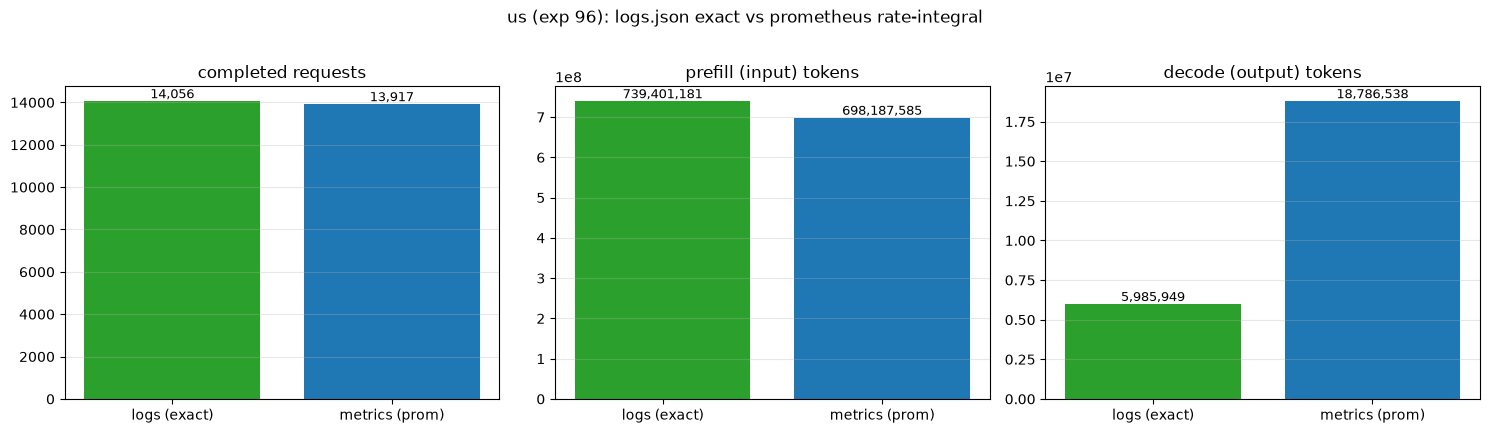

In [10]:
# exact per-request ground truth from logs.json (our run only)
_recs = [json.loads(l) for l in open(os.path.join(EXPERIMENTS_ROOT, "96", "logs.json")) if l.strip()]
log_req     = float(len(_recs))
log_prefill = float(np.nansum([(r.get("prompt_tokens") or 0) for r in _recs]))
log_decode  = float(np.nansum([(r.get("completion_tokens") or 0) for r in _recs]))

# metrics side: prometheus rate-integral for our endpoints (same method as comparison cell)
_usc = add_cumulative(engine_rows(df96, US_ENDPOINTS))
_t = cumulative_totals(_usc)
met_req     = float(_t["cum_requests"].sum())
met_prefill = float(_t["cum_prefill_tokens"].sum())
met_decode  = float(_t["cum_gen_tokens"].sum())

cmp = pd.DataFrame({
    "quantity":       ["completed requests", "prefill (input) tokens", "decode (output) tokens"],
    "logs (exact)":   [log_req, log_prefill, log_decode],
    "metrics (prom)": [met_req, met_prefill, met_decode],
}).set_index("quantity")
cmp["metrics/logs"] = cmp["metrics (prom)"] / cmp["logs (exact)"]
cmp["diff_%"] = (cmp["metrics/logs"] - 1.0) * 100.0
display(cmp.round({"logs (exact)": 0, "metrics (prom)": 0, "metrics/logs": 3, "diff_%": 1}))

print(f"requests: logs={log_req:,.0f}  metrics={met_req:,.0f}  ({(met_req/log_req-1)*100:+.1f}%)")
print(f"prefill : logs={log_prefill:,.0f}  metrics={met_prefill:,.0f}  ({(met_prefill/log_prefill-1)*100:+.1f}%)")
print(f"decode  : logs={log_decode:,.0f}  metrics={met_decode:,.0f}  ({(met_decode/log_decode-1)*100:+.1f}%)"
      f"  <- metrics = generated (incl. recompute), logs = delivered")

# grouped bars, one panel per quantity (different scales)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, q in zip(axes, cmp.index):
    vals = [cmp.loc[q, "logs (exact)"], cmp.loc[q, "metrics (prom)"]]
    bars = ax.bar(["logs (exact)", "metrics (prom)"], vals, color=["#2ca02c", "#1f77b4"])
    ax.set_title(q); ax.grid(alpha=0.3, axis="y")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
fig.suptitle("us (exp 96): logs.json exact vs prometheus rate-integral", y=1.02)
fig.tight_layout(); plt.show()

# Our concurrency vs incoming rate — `num_running_requests` (ours) vs `derived_rps` (us & them)

Overlays our fleet **concurrency** (`requests_running`, exp 96, our 4 engines) against the
**incoming request rate** (`derived_rps`) of both sides, on a shared absolute-time axis
(exp 95 and 96 ran concurrently, so their UTC timestamps line up):

- **top panel** — `num running requests`: us (green) vs them (red), per-engine (light) + fleet total (bold)
- **bottom panel** — incoming load `derived_rps` (5-min rolling avg): us (`218`+`6.33`, summed) vs them (`142`, summed)

Reading it: when running climbs while incoming rps stays flat/low, requests are piling up
(slow service / preemption) rather than arrivals rising — e.g. the late ramp where our
running hits ~60 at low rps.

/tmp/ipykernel_854579/303240502.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


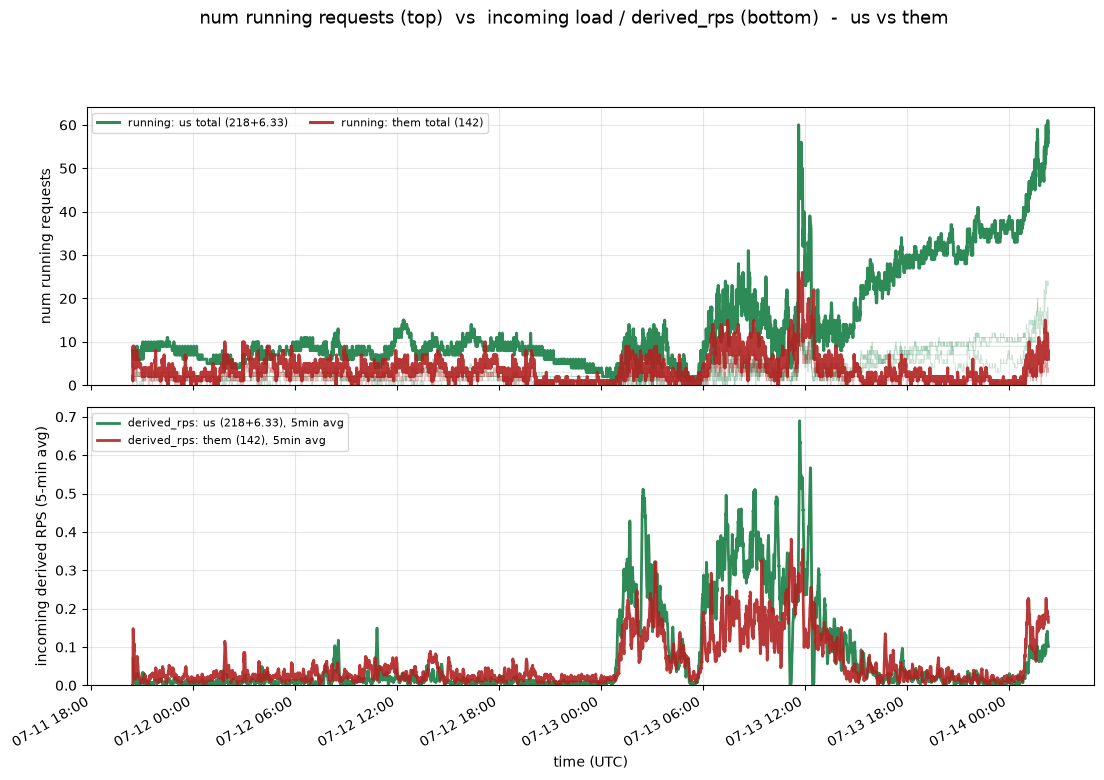

us   running (sum): mean=13.9  max=61
them running (sum): mean=3.8  max=26
us   derived_rps (sum): mean=0.072  max=0.831
them derived_rps (sum): mean=0.058  max=0.625


In [11]:
# ============================================================
# Ours: num running requests (concurrency)  vs  incoming derived_rps (us vs them)
#   exp 95/96 ran concurrently -> align on absolute UTC ts.
# ============================================================
import matplotlib.dates as mdates

RPS_SMOOTH = "5min"   # rolling window for the incoming-rate lines (raw 30s samples are spiky)

our      = engine_rows(df96, US_ENDPOINTS)                  # our 4 engines only
them     = engine_rows(df95)                                # them (142), 2 engines
our_run  = fleet_series(our,  "requests_running")           # ours: sum running / tick
them_run = fleet_series(them, "requests_running")           # them: sum running / tick
us_rps   = fleet_series(our,  "derived_rps")               # our incoming rate (sum)
them_rps = fleet_series(them, "derived_rps")               # them incoming rate (sum)

def _smooth(s, col, win):
    x = s.dropna(subset=[col]).sort_values("ts").set_index("ts")[col]
    return x.rolling(win).mean()

fig, (axT, axB) = plt.subplots(2, 1, figsize=(13, 8.5), sharex=True,
                               gridspec_kw={"hspace": 0.08})

# TOP: concurrency (num running requests) — us vs them, per-engine (light) + total (bold)
for inst, sub in our.groupby("instance"):
    s = sub.dropna(subset=["requests_running"]).sort_values("ts")
    if not s.empty:
        axT.plot(s["ts"], s["requests_running"], color="seagreen", lw=0.6, alpha=0.25)
for inst, sub in them.groupby("instance"):
    s = sub.dropna(subset=["requests_running"]).sort_values("ts")
    if not s.empty:
        axT.plot(s["ts"], s["requests_running"], color="firebrick", lw=0.6, alpha=0.25)
axT.plot(our_run["ts"],  our_run["requests_running"],  color="seagreen", lw=2.2,
         label="running: us total (218+6.33)")
axT.plot(them_run["ts"], them_run["requests_running"], color="firebrick", lw=2.2, alpha=0.9,
         label="running: them total (142)")
axT.set_ylabel("num running requests")
axT.set_ylim(bottom=0)
axT.grid(True, alpha=0.3)
axT.legend(fontsize=8, ncol=2, loc="upper left")

# BOTTOM: incoming request rate (load), us vs them (rolling mean)
us_s   = _smooth(us_rps,   "derived_rps", RPS_SMOOTH)
them_s = _smooth(them_rps, "derived_rps", RPS_SMOOTH)
axB.plot(us_s.index,   us_s.values,   color="seagreen", lw=2.0,
         label=f"derived_rps: us (218+6.33), {RPS_SMOOTH} avg")
axB.plot(them_s.index, them_s.values, color="firebrick", lw=2.0, alpha=0.9,
         label=f"derived_rps: them (142), {RPS_SMOOTH} avg")
axB.set_ylabel("incoming derived RPS (5-min avg)")
axB.set_ylim(bottom=0)
axB.grid(True, alpha=0.3)
axB.legend(fontsize=8, loc="upper left")

axB.set_xlabel("time (UTC)")
axB.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle("num running requests (top)  vs  incoming load / derived_rps (bottom)  -  us vs them",
             fontsize=13, y=0.995)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

# quick numeric summary (means/peaks over the captured window)
print(f"us   running (sum): mean={our_run['requests_running'].mean():.1f}  max={our_run['requests_running'].max():.0f}")
print(f"them running (sum): mean={them_run['requests_running'].mean():.1f}  max={them_run['requests_running'].max():.0f}")
print(f"us   derived_rps (sum): mean={us_rps['derived_rps'].mean():.3f}  max={us_rps['derived_rps'].max():.3f}")
print(f"them derived_rps (sum): mean={them_rps['derived_rps'].mean():.3f}  max={them_rps['derived_rps'].max():.3f}")

## Token load over time — prefill (input) and output (decode), us vs them

Two separate figures, same idea as the incoming-rps panel but at the token level
(summed across each side's engines, 5-min rolling avg, absolute UTC axis):

- **prefill tokens/s** — input/prompt token throughput (`prefill_tokens_per_sec`)
- **output tokens/s** — generated/decode token throughput (`gen_tokens_per_sec`)

These are throughput (tokens **per second**); multiply by 60 for per-minute.

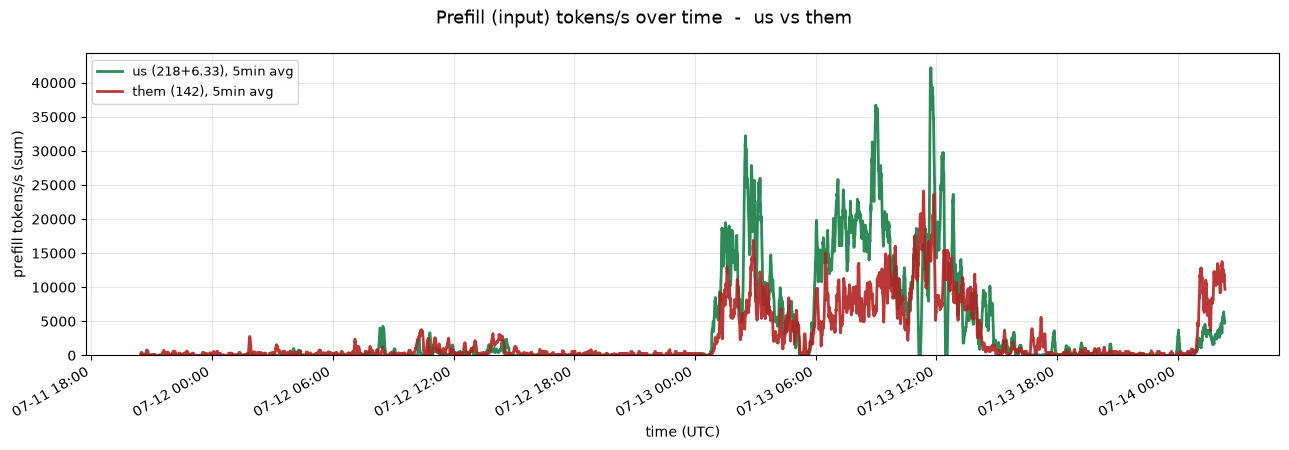

us   prefill_tokens_per_sec (sum): mean=3598  max=54533  tokens/s
them prefill_tokens_per_sec (sum): mean=2490  max=32659  tokens/s


In [12]:
# ============================================================
# Token throughput over time — us vs them (reuses `our`/`them`/`_smooth`/`fleet_series`)
# ============================================================
def plot_token_load(col, title, ylabel, smooth="5min"):
    us_f, them_f = fleet_series(our, col), fleet_series(them, col)
    us_s, them_s = _smooth(us_f, col, smooth), _smooth(them_f, col, smooth)
    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(us_s.index,   us_s.values,   color="seagreen", lw=2.0,
            label=f"us (218+6.33), {smooth} avg")
    ax.plot(them_s.index, them_s.values, color="firebrick", lw=2.0, alpha=0.9,
            label=f"them (142), {smooth} avg")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("time (UTC)")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.suptitle(title, fontsize=13, y=0.99)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()
    print(f"us   {col} (sum): mean={us_f[col].mean():.0f}  max={us_f[col].max():.0f}  tokens/s")
    print(f"them {col} (sum): mean={them_f[col].mean():.0f}  max={them_f[col].max():.0f}  tokens/s")

plot_token_load("prefill_tokens_per_sec",
                "Prefill (input) tokens/s over time  -  us vs them",
                "prefill tokens/s (sum)")

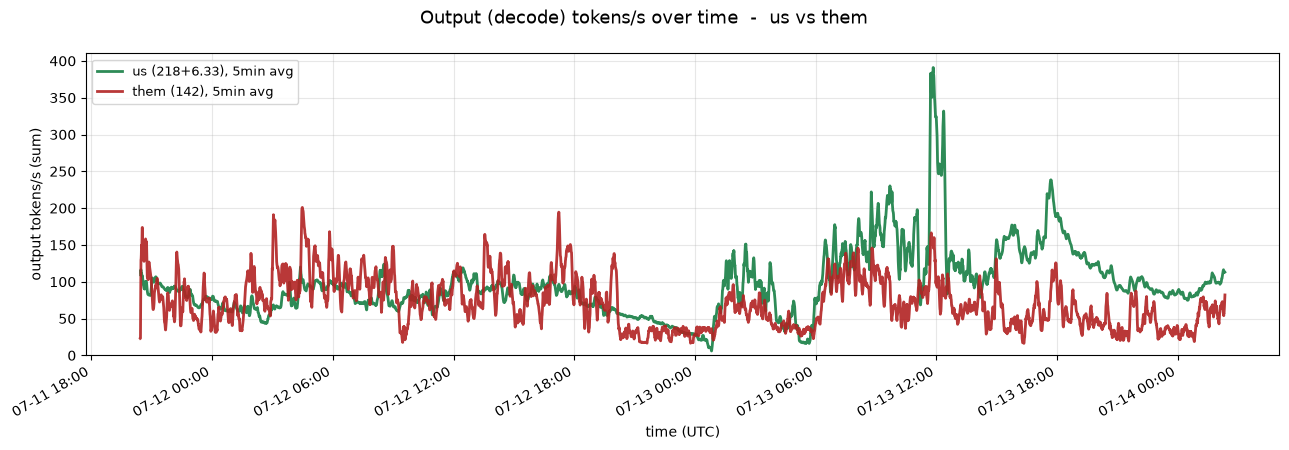

us   gen_tokens_per_sec (sum): mean=97  max=431  tokens/s
them gen_tokens_per_sec (sum): mean=71  max=244  tokens/s


In [13]:
plot_token_load("gen_tokens_per_sec",
                "Output (decode) tokens/s over time  -  us vs them",
                "output tokens/s (sum)")

## End-to-end latency over time — Prometheus vs logs, shown separately

Two figures on purpose, one per data source:

1. **Prometheus** (`e2e_latency_seconds_avg`, mean across each side's engines, 5-min avg) —
   the metric both sides expose. Watch out: **us's Prometheus avg is wildly overload-biased**
   (mean ~340 s, max ~13,000 s) because the windowed histogram average blows up during
   preemption/backlog. them's avg stays ~50 s. This figure is exactly *why* the raw
   Prometheus average must not be trusted for us.
2. **logs.json** (exact per-request `end_to_end_s`, 5-min median + p95) — ground truth,
   **us only** (the external node `142` has no request logs). us's true median is ~19 s.

So the Prometheus panel shows the artifact; the logs panel shows reality. Comparing them
side-by-side is the point.

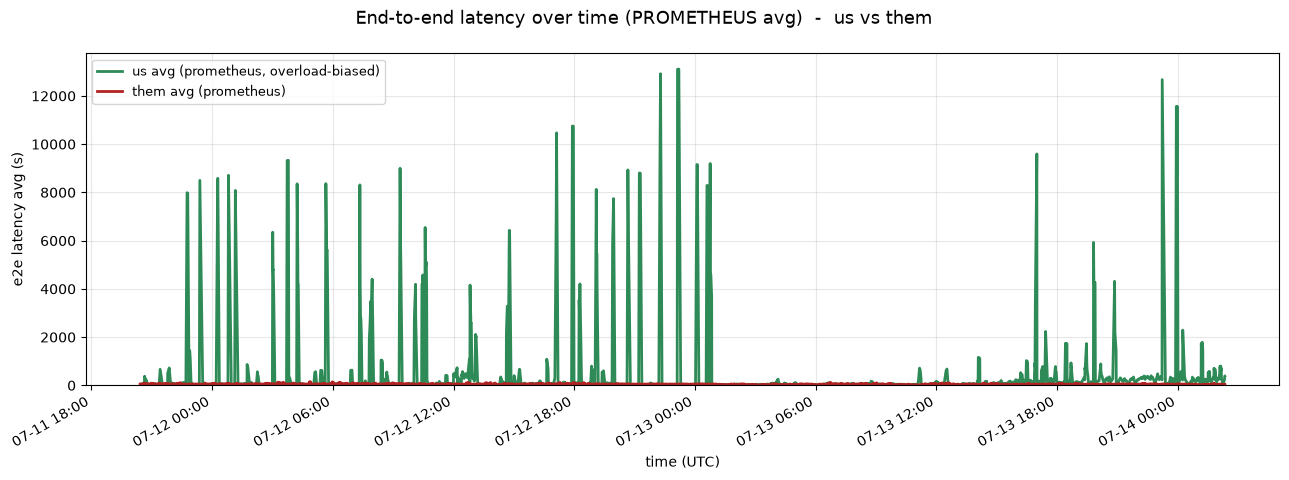

PROM us   avg: mean=340.2s  max=13109.4s  (overload-biased)
PROM them avg: mean=53.9s  max=155.2s


In [14]:
# ============================================================
# (1) PROMETHEUS e2e — us vs them, e2e_latency_seconds_avg (mean over engines, 5-min avg)
#     NB: us's avg is overload-biased (spikes to ~13,000 s) -> that's the artifact.
# ============================================================
us_prom   = (engine_rows(df96, US_ENDPOINTS).dropna(subset=["e2e_latency_seconds_avg"])
             .groupby("ts")["e2e_latency_seconds_avg"].mean().rolling("5min").mean())
them_prom = (engine_rows(df95).dropna(subset=["e2e_latency_seconds_avg"])
             .groupby("ts")["e2e_latency_seconds_avg"].mean().rolling("5min").mean())

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(us_prom.index,   us_prom.values,   color="seagreen", lw=2.0,
        label="us avg (prometheus, overload-biased)")
ax.plot(them_prom.index, them_prom.values, color="firebrick", lw=2.0,
        label="them avg (prometheus)")
ax.set_ylabel("e2e latency avg (s)")
ax.set_xlabel("time (UTC)")
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle("End-to-end latency over time (PROMETHEUS avg)  -  us vs them", fontsize=13, y=0.99)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(f"PROM us   avg: mean={us_prom.mean():.1f}s  max={us_prom.max():.1f}s  (overload-biased)")
print(f"PROM them avg: mean={them_prom.mean():.1f}s  max={them_prom.max():.1f}s")

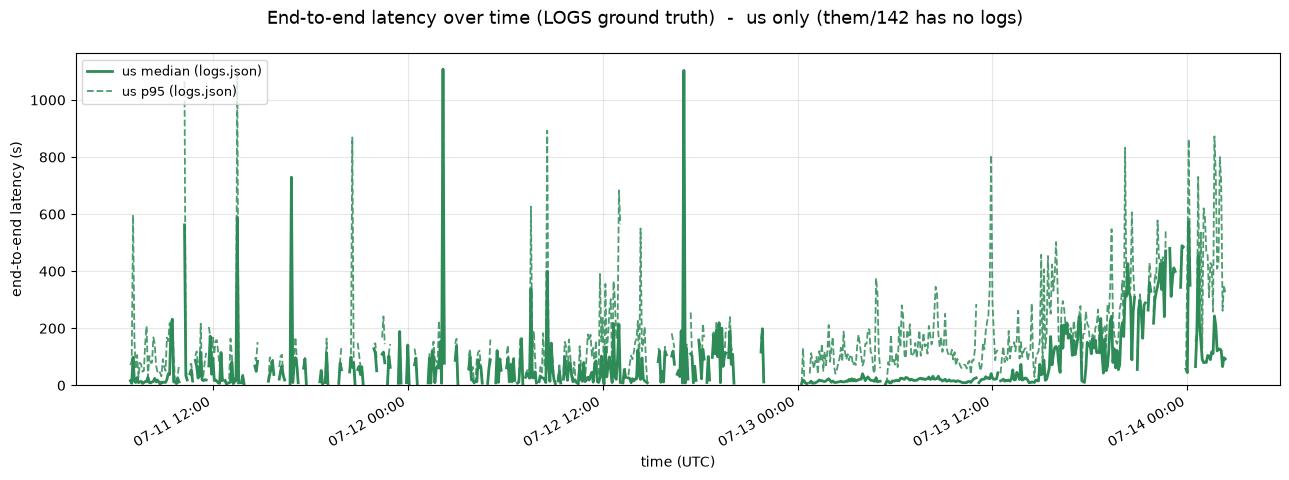

LOGS us e2e: median=18.9s  p95=194.5s  (n=14,056)
them: no logs.json (external node) -> see the Prometheus figure above for them


In [15]:
# ============================================================
# (2) LOGS e2e — us ground truth from logs.json (5-min median + p95).
#     them (external node 142) has no request logs, so it cannot appear here.
# ============================================================
_ep = load_endpoint_logs(96)
_d  = _ep.dropna(subset=["t1_wall", "end_to_end_s"]).set_index("t1_wall").sort_index()
us_med = _d["end_to_end_s"].resample("5min").median()
us_p95 = _d["end_to_end_s"].resample("5min").quantile(0.95)

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(us_med.index, us_med.values, color="seagreen", lw=2.0,
        label="us median (logs.json)")
ax.plot(us_p95.index, us_p95.values, color="seagreen", lw=1.3, ls="--", alpha=0.85,
        label="us p95 (logs.json)")
ax.set_ylabel("end-to-end latency (s)")
ax.set_xlabel("time (UTC)")
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle("End-to-end latency over time (LOGS ground truth)  -  us only "
             "(them/142 has no logs)", fontsize=13, y=0.99)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(f"LOGS us e2e: median={_d['end_to_end_s'].median():.1f}s  "
      f"p95={_d['end_to_end_s'].quantile(0.95):.1f}s  (n={len(_d):,})")
print("them: no logs.json (external node) -> see the Prometheus figure above for them")

## Prefix cache hit rate over time — us vs them

GPU prefix cache hit rate computed robustly from the per-second counters as
`sum(prefix_cache_hits_per_sec) / sum(prefix_cache_queries_per_sec)` (the raw
`prefix_cache_hit_rate` column is sparse and occasionally >1, so it's not used). A 15-min
rolling window is applied, and ticks with almost no queries (`< 50` avg qps in the window)
are blanked because the ratio is meaningless when idle.

**Our two pods are shown separately** (hits/queries summed across each pod's 2 engines):
`us 6.33 (m2-0)` and `us 218 (m2-1)`, vs `them (142)`. During active periods everyone sits
~70–80%; our pods show the deep late collapses toward 07-13 evening / 07-14 that line up with
the cache drop + TTFT spike seen in the dashboard.

us 6.33 (m2-0)   prefix hit rate: mean=77.5%


us 218 (m2-1)    prefix hit rate: mean=75.0%


them (142)       prefix hit rate: mean=77.8%


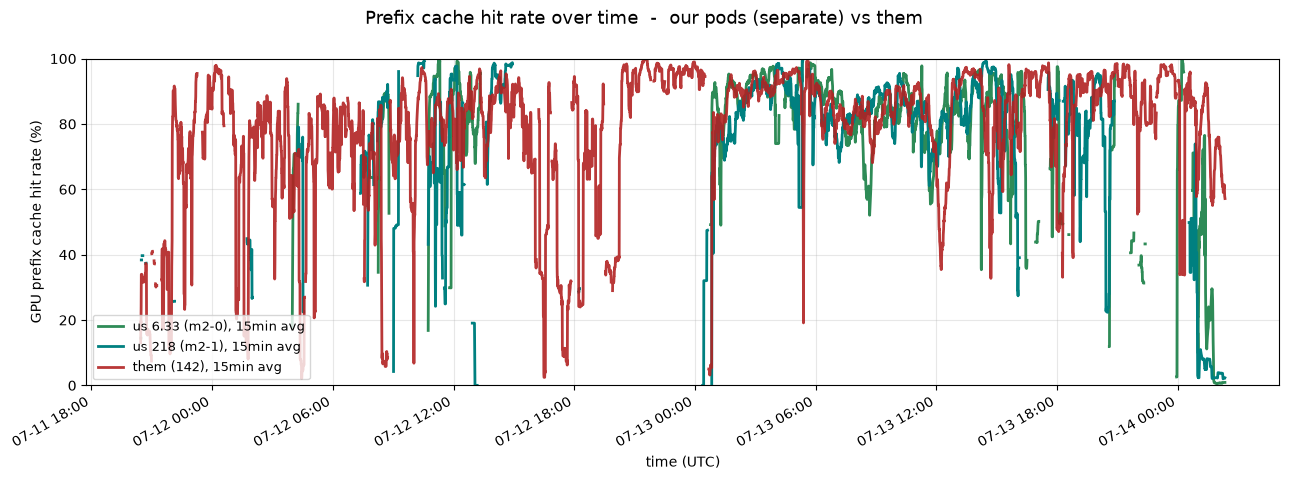

In [16]:
# ============================================================
# Prefix cache hit rate over time — us vs them
#   hit rate = sum(hits/s) / sum(queries/s) across engines, 15-min window, idle blanked.
# ============================================================
def prefix_hit_rate(df, win="15min", min_qps=50.0):
    d = df.dropna(subset=["prefix_cache_hits_per_sec", "prefix_cache_queries_per_sec"])
    g = (d.groupby("ts")[["prefix_cache_hits_per_sec", "prefix_cache_queries_per_sec"]]
         .sum().sort_index())
    h = g["prefix_cache_hits_per_sec"].rolling(win).sum()
    q = g["prefix_cache_queries_per_sec"].rolling(win).sum()
    qbar = g["prefix_cache_queries_per_sec"].rolling(win).mean()   # avg query load in window
    hr = h / q * 100.0
    hr[qbar < min_qps] = np.nan     # blank hit rate when barely any queries (ratio meaningless)
    return hr

# keep our two pods separate (don't collapse); them stays as one
US_LABEL  = {"vllm-minimax-m2-0": "us 6.33 (m2-0)", "vllm-minimax-m2-1": "us 218 (m2-1)"}
US_COLORS = {"vllm-minimax-m2-0": "seagreen",       "vllm-minimax-m2-1": "teal"}

fig, ax = plt.subplots(figsize=(13, 4.8))
for ep in US_ENDPOINTS:
    s = prefix_hit_rate(engine_rows(df96, [ep]))
    ax.plot(s.index, s.values, color=US_COLORS.get(ep), lw=2.0,
            label=f"{US_LABEL.get(ep, ep)}, 15min avg")
    print(f"{US_LABEL.get(ep, ep):16s} prefix hit rate: mean={s.mean():.1f}%")
them_hr = prefix_hit_rate(engine_rows(df95))
ax.plot(them_hr.index, them_hr.values, color="firebrick", lw=2.0, alpha=0.9,
        label="them (142), 15min avg")
print(f"{'them (142)':16s} prefix hit rate: mean={them_hr.mean():.1f}%")

ax.set_ylabel("GPU prefix cache hit rate (%)")
ax.set_xlabel("time (UTC)")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="lower left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle("Prefix cache hit rate over time  -  our pods (separate) vs them",
             fontsize=13, y=0.99)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Dashboard prefix cache hit rate over time — us vs them (from `experiments_hq`)

Cross-check of the previous (scraper) hit-rate figure against the **external dashboard**
snapshots (`experiments_hq/1/*api_data_24hour.json`). Computed from `prefix_cache_raw`
(cumulative `hits/queries`) summed across each side's endpoints, then `hits/queries*100`.

Endpoint note: on the dashboard, `direct218`/`direct33` stop reporting after 07-02, so during
the 95/96 window our two pods appear as **`llmla1-direct65`** and **`llmla2-direct65`**, shown
**separately** (not collapsed); them is **`direct142`**. Dashboard timestamps are Asia/Shanghai
and are shifted **−8 h to UTC** to line up with the cells above.

**This is a cumulative (all-time-since-reset) ratio**, so it's much smoother than the previous
*windowed* scraper hit rate — don't expect identical numbers. Our pods sit ~85–90% (vs them ~80%)
but collapse hard at the very end (07-14), the same cache drop seen in the dashboard/doomsday view.

dashboard them (142): mean=80.1%   (n=347)
dashboard us llmla1: mean=86.5%   (n=347)
dashboard us llmla2: mean=86.3%   (n=347)


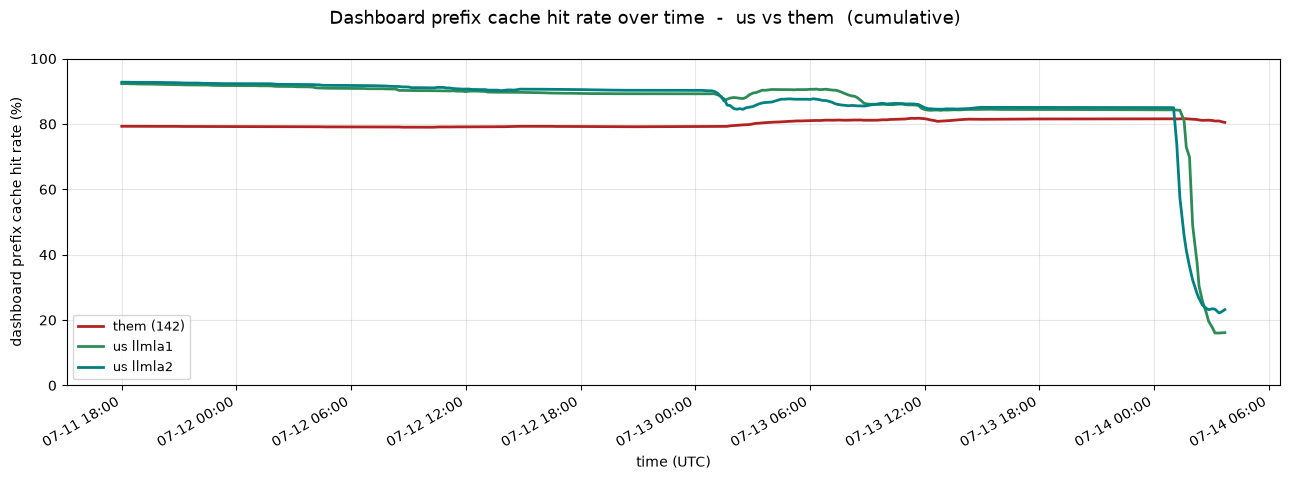

In [17]:
# ============================================================
# Dashboard (experiments_hq) prefix cache hit rate — us vs them
#   cumulative hits/queries from prefix_cache_raw; ts Shanghai -> UTC (-8h)
# ============================================================
import glob as _glob
import datetime as _dt
import matplotlib.dates as mdates

HQ_SNAP_GLOB  = "/home/saeid/experiments_hq/1/*api_data_*.json"
HQ_TZ_OFFSET_H = 8   # dashboard ts are Asia/Shanghai -> subtract to get UTC
# keep our two pods separate (don't collapse); them stays as one
HQ_GROUPS = {
    "them (142)": ["MiniMax-M2.7-direct142"],
    "us llmla1":  ["MiniMax-M2.7-llmla1-direct65"],
    "us llmla2":  ["MiniMax-M2.7-llmla2-direct65"],
}
HQ_COLORS = {"them (142)": "firebrick", "us llmla1": "seagreen", "us llmla2": "teal"}
HQ_HR = {}   # filled below so the stacked overview can reuse it without re-parsing

def _hq_parse_ts(s):
    for f in ("%Y-%m-%dT%H:%M", "%Y-%m-%dT%H:%M:%S"):
        try: return _dt.datetime.strptime(s, f)
        except (ValueError, TypeError): pass
    return None

_files = sorted(_glob.glob(HQ_SNAP_GLOB))
if not _files:
    print("no HQ snapshots at", HQ_SNAP_GLOB, "- skipping dashboard cache plot")
else:
    _mods = sorted({m for v in HQ_GROUPS.values() for m in v})
    _hits = {m: {} for m in _mods}
    _qs   = {m: {} for m in _mods}
    for fp in _files:                          # single pass (~50s over ~6k snapshots)
        d = json.load(open(fp, encoding="utf-8"))
        ts = [_hq_parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in _mods:
            v = idm.get(m)
            if not v: continue
            r = v.get("prefix_cache_raw") or []
            for i in range(min(len(ts), len(r))):
                if ts[i] is None or not r[i]: continue
                try:
                    a, b = r[i].split("/"); a = float(a); b = float(b)
                except (ValueError, AttributeError):
                    continue
                if b > 0:
                    _hits[m][ts[i]] = a
                    _qs[m][ts[i]] = b

    def _hq_combined(models):
        idx = sorted(set().union(*[set(_hits[m]) for m in models]))
        rows = []
        for t in idx:
            H = sum(_hits[m][t] for m in models if t in _hits[m])
            Q = sum(_qs[m][t]   for m in models if t in _qs[m])
            if Q > 0:
                rows.append((t - _dt.timedelta(hours=HQ_TZ_OFFSET_H), H / Q * 100.0))
        s = pd.Series([v for _, v in rows],
                      index=pd.DatetimeIndex([t for t, _ in rows])).sort_index()
        return s[s.index >= pd.Timestamp("2026-07-11 18:00")]   # match the 95/96 window

    fig, ax = plt.subplots(figsize=(13, 4.8))
    for lab in ("them (142)", "us llmla1", "us llmla2"):
        s = _hq_combined(HQ_GROUPS[lab])
        HQ_HR[lab] = s
        ax.plot(s.index, s.values, color=HQ_COLORS[lab], lw=2.0, label=lab)
        print(f"dashboard {lab}: mean={s.mean():.1f}%   (n={len(s)})")
    ax.set_ylabel("dashboard prefix cache hit rate (%)")
    ax.set_xlabel("time (UTC)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="lower left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.suptitle("Dashboard prefix cache hit rate over time  -  us vs them  (cumulative)",
                 fontsize=13, y=0.99)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## TTFT (prefill) & TPOT (decode) latency over time — us vs them

**Both sides from vLLM/prometheus, same method** (no logs), so they're directly comparable:

- **TTFT** (prefill latency): `ttft_seconds_avg` (mean across engines, 5-min) for both us and them.
- **TPOT** (decode latency, seconds/token): neither exposes a direct vLLM tpot for us, so it's
  **derived the same way for both** — `(e2e_avg − ttft_avg) × request_rate / gen_token_rate`
  (= avg decode time per output token), smoothed, near-idle ticks blanked.

Caveat: because us's TPOT is built from its `e2e_latency_seconds_avg`, it inherits the same
**overload-avg bias** that inflates the Prometheus e2e panel (spikes to several s/token during the
07-14 backlog). At the median the two sides are close (~0.024 vs 0.027 s/token); the logs e2e
panel above remains the ground truth for us.

/tmp/ipykernel_854579/3130098905.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


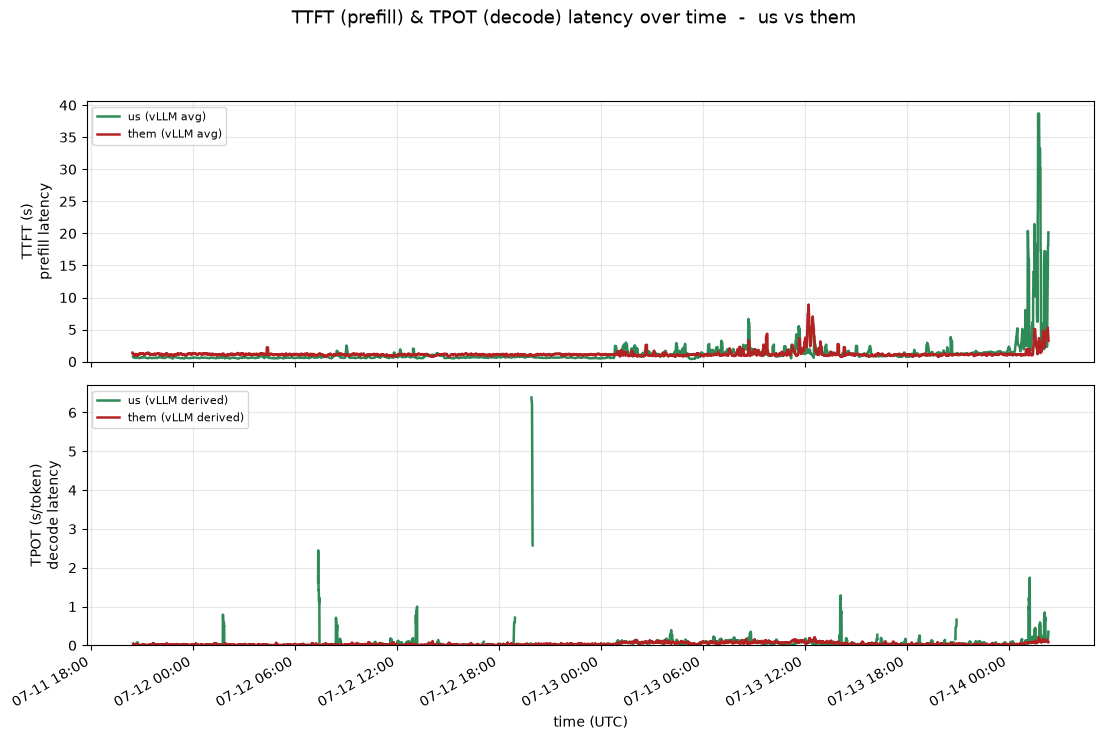

us   TTFT(vLLM avg) median=1.153s   TPOT(vLLM derived) median=0.0236s/token
them TTFT(vLLM avg) median=1.102s   TPOT(vLLM derived) median=0.0274s/token


In [18]:
# ============================================================
# TTFT (prefill) & TPOT (decode) latency over time — us vs them
# ============================================================
import matplotlib.dates as mdates

them = engine_rows(df95)
our  = engine_rows(df96, US_ENDPOINTS)

# Both sides from vLLM/prometheus, same method (no logs).
#   TTFT  = ttft_seconds_avg (vLLM).
#   TPOT  = (e2e_avg - ttft_avg) / avg_output_tokens   [us has no direct vLLM tpot/decode_time],
# so us's TPOT inherits the same overload bias as its e2e avg (hence the spikes); the logs
# e2e panel remains the ground truth for us.
def _ttft_vllm(df):
    return (df.dropna(subset=["ttft_seconds_avg"])
              .groupby("ts")["ttft_seconds_avg"].mean().rolling("5min").mean())

def _tpot_vllm(df):
    g = df.groupby("ts")
    decode = (g["e2e_latency_seconds_avg"].mean() - g["ttft_seconds_avg"].mean()).clip(lower=0)
    req = g["request_success_per_sec"].sum()
    gen = g["gen_tokens_per_sec"].sum()
    dec_r = decode.rolling("5min").mean()
    req_r = req.rolling("5min").sum()
    gen_r = gen.rolling("5min").sum()
    tp = (dec_r * req_r / gen_r).replace([np.inf, -np.inf], np.nan)
    tp[req_r < req_r.quantile(0.5) * 0.2] = np.nan     # blank near-idle (ratio meaningless)
    return tp

us_ttft, them_ttft = _ttft_vllm(our),  _ttft_vllm(them)
us_tpot, them_tpot = _tpot_vllm(our),  _tpot_vllm(them)

fig, (ax_t, ax_p) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                 gridspec_kw={"hspace": 0.09})
ax_t.plot(us_ttft.index,   us_ttft.values,   color="seagreen",  lw=1.8, label="us (vLLM avg)")
ax_t.plot(them_ttft.index, them_ttft.values, color="firebrick", lw=1.8, label="them (vLLM avg)")
ax_t.set_ylabel("TTFT (s)\nprefill latency"); ax_t.set_ylim(bottom=0)

ax_p.plot(us_tpot.index,   us_tpot.values,   color="seagreen",  lw=1.8, label="us (vLLM derived)")
ax_p.plot(them_tpot.index, them_tpot.values, color="firebrick", lw=1.8, label="them (vLLM derived)")
ax_p.set_ylabel("TPOT (s/token)\ndecode latency"); ax_p.set_ylim(bottom=0)

for ax in (ax_t, ax_p):
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")
ax_p.set_xlabel("time (UTC)")
ax_p.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle("TTFT (prefill) & TPOT (decode) latency over time  -  us vs them",
             fontsize=13, y=0.995)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(f"us   TTFT(vLLM avg) median={us_ttft.median():.3f}s   TPOT(vLLM derived) median={us_tpot.median():.4f}s/token")
print(f"them TTFT(vLLM avg) median={them_ttft.median():.3f}s   TPOT(vLLM derived) median={them_tpot.median():.4f}s/token")

## Dashboard latency over time — TTFT / TPOT / e2e (from `experiments_hq`)

Latency straight from the dashboard snapshots (`identifier_metrics`), us (`llmla1`+`llmla2`,
separate) vs them (`direct142`):

- **TTFT / TPOT**: dashboard-native fields (`ttft`, `tpot`), converted ms → s.
- **e2e** (derived): `ttft + tpot × avg_output_len`, where
  `avg_output_len = Δoutput_tokens / request_increment` per snapshot window (~700 tok/req typical).

Timestamps are Asia/Shanghai → shifted −8 h to UTC to line up with the cells above; each series is
a 15-min rolling median to tame the per-snapshot spikes.

them (142)   ttft med=0.542s  tpot med=0.0359s/tok  e2e med=70.40s
us llmla1    ttft med=0.645s  tpot med=0.0783s/tok  e2e med=706.93s
us llmla2    ttft med=0.707s  tpot med=0.0875s/tok  e2e med=524.70s


/tmp/ipykernel_854579/3655851634.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


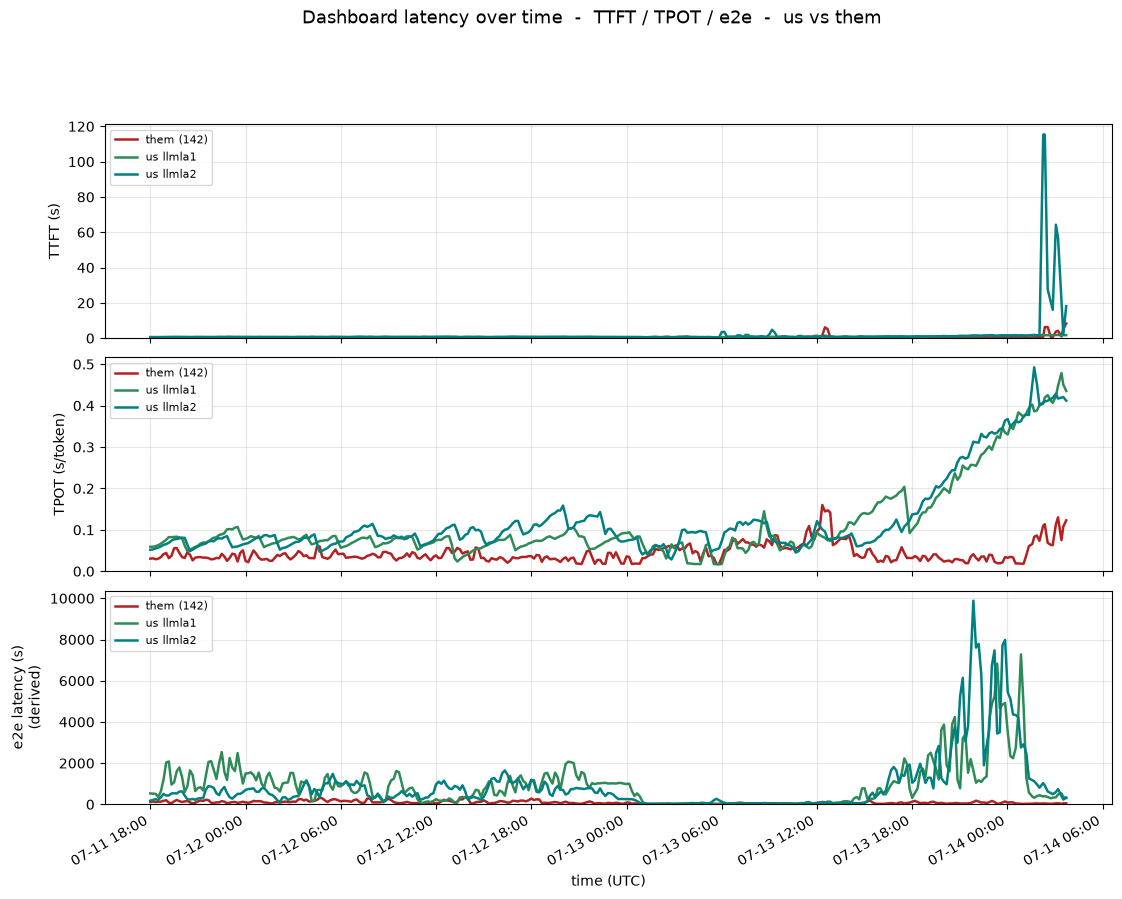

In [19]:
# ============================================================
# Dashboard (experiments_hq) TTFT / TPOT / e2e latency — us vs them
#   ttft, tpot are dashboard-native (ms -> s).
#   e2e derived = ttft + tpot * avg_output_len,
#     avg_output_len = Δoutput_tokens / request_increment (per snapshot window).
#   ts Asia/Shanghai -> UTC (-HQ_TZ_OFFSET_H h); 15-min rolling median for display.
#   (reuses HQ_SNAP_GLOB / HQ_GROUPS / HQ_COLORS / _hq_parse_ts / HQ_TZ_OFFSET_H from above)
# ============================================================
import glob as _glob
import datetime as _dt
import matplotlib.dates as mdates

_lf_files = sorted(_glob.glob(HQ_SNAP_GLOB))
_lf_mods  = sorted({m for v in HQ_GROUPS.values() for m in v})
_lf = {m: {} for m in _lf_mods}    # ts -> (ttft_s, tpot_s, e2e_s)

for fp in _lf_files:
    d = json.load(open(fp, encoding="utf-8"))
    ts = [_hq_parse_ts(x) for x in (d.get("timestamps") or [])]
    idm = d.get("identifier_metrics", {})
    for m in _lf_mods:
        v = idm.get(m)
        if not v:
            continue
        ttft = v.get("ttft") or []
        tpot = v.get("tpot") or []
        otk  = v.get("output_tokens") or []
        rinc = v.get("request_increment") or []
        for i in range(min(len(ts), len(ttft), len(tpot))):
            if ts[i] is None or ttft[i] is None or tpot[i] is None:
                continue
            ttft_s, tpot_s = ttft[i] / 1000.0, tpot[i] / 1000.0
            outlen = np.nan
            if 0 < i < len(otk) and i < len(rinc) and rinc[i] and rinc[i] > 0 \
               and otk[i] is not None and otk[i-1] is not None and otk[i] - otk[i-1] > 0:
                outlen = (otk[i] - otk[i-1]) / rinc[i]
            e2e_s = ttft_s + tpot_s * outlen if outlen == outlen else np.nan
            # files overlap heavily; last-wins would blank e2e at a file's first tick
            # (i==0 / cross-file Δtokens), so keep any non-NaN e2e we've seen for this ts.
            cur = _lf[m].get(ts[i])
            if cur is None:
                _lf[m][ts[i]] = [ttft_s, tpot_s, e2e_s]
            else:
                cur[0], cur[1] = ttft_s, tpot_s
                if e2e_s == e2e_s:      # not NaN
                    cur[2] = e2e_s

def _lf_df(model):
    rows = [(t - _dt.timedelta(hours=HQ_TZ_OFFSET_H), a, b, c)
            for t, (a, b, c) in _lf[model].items()]
    df = (pd.DataFrame(rows, columns=["ts", "ttft_s", "tpot_s", "e2e_s"])
          .set_index("ts").sort_index())
    df = df[df.index >= pd.Timestamp("2026-07-11 18:00")]
    return df.rolling("15min").median()

HQ_LAT = {lab: _lf_df(HQ_GROUPS[lab][0]) for lab in HQ_GROUPS}   # stash for reuse

fig, (axT, axP, axE) = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                                    gridspec_kw={"hspace": 0.09})
for lab in ("them (142)", "us llmla1", "us llmla2"):
    df, col = HQ_LAT[lab], HQ_COLORS[lab]
    axT.plot(df.index, df["ttft_s"], color=col, lw=1.8, label=lab)
    axP.plot(df.index, df["tpot_s"], color=col, lw=1.8, label=lab)
    axE.plot(df.index, df["e2e_s"],  color=col, lw=1.8, label=lab)
    print(f"{lab:12s} ttft med={df['ttft_s'].median():.3f}s  "
          f"tpot med={df['tpot_s'].median():.4f}s/tok  e2e med={df['e2e_s'].median():.2f}s")

axT.set_ylabel("TTFT (s)");                    axT.set_ylim(bottom=0)
axP.set_ylabel("TPOT (s/token)");              axP.set_ylim(bottom=0)
axE.set_ylabel("e2e latency (s)\n(derived)");  axE.set_ylim(bottom=0)
for ax in (axT, axP, axE):
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")
axE.set_xlabel("time (UTC)")
axE.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle("Dashboard latency over time  -  TTFT / TPOT / e2e  -  us vs them",
             fontsize=13, y=0.995)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

# Combined overview — everything stacked on one shared UTC axis

All the panels above in one figure (us green / us 2nd pod teal / them red), top to bottom:
`num running requests` → `derived load (rps)` → `prefill (input) tokens/s` →
`decode (output) tokens/s` → `TTFT` → `TPOT` → `e2e` → `prefix cache hit rate`.

Throughput/running/rps come from the windowed scraper (5-min smoothed). **The four latency &
cache panels are all dashboard-sourced** (`experiments_hq`): TTFT/TPOT are dashboard-native
(ms→s), e2e is `ttft + tpot × avg_output_len`, and cache is cumulative — all 15-min medians with
our two pods (`llmla1`, `llmla2`) shown separately vs them (`142`).

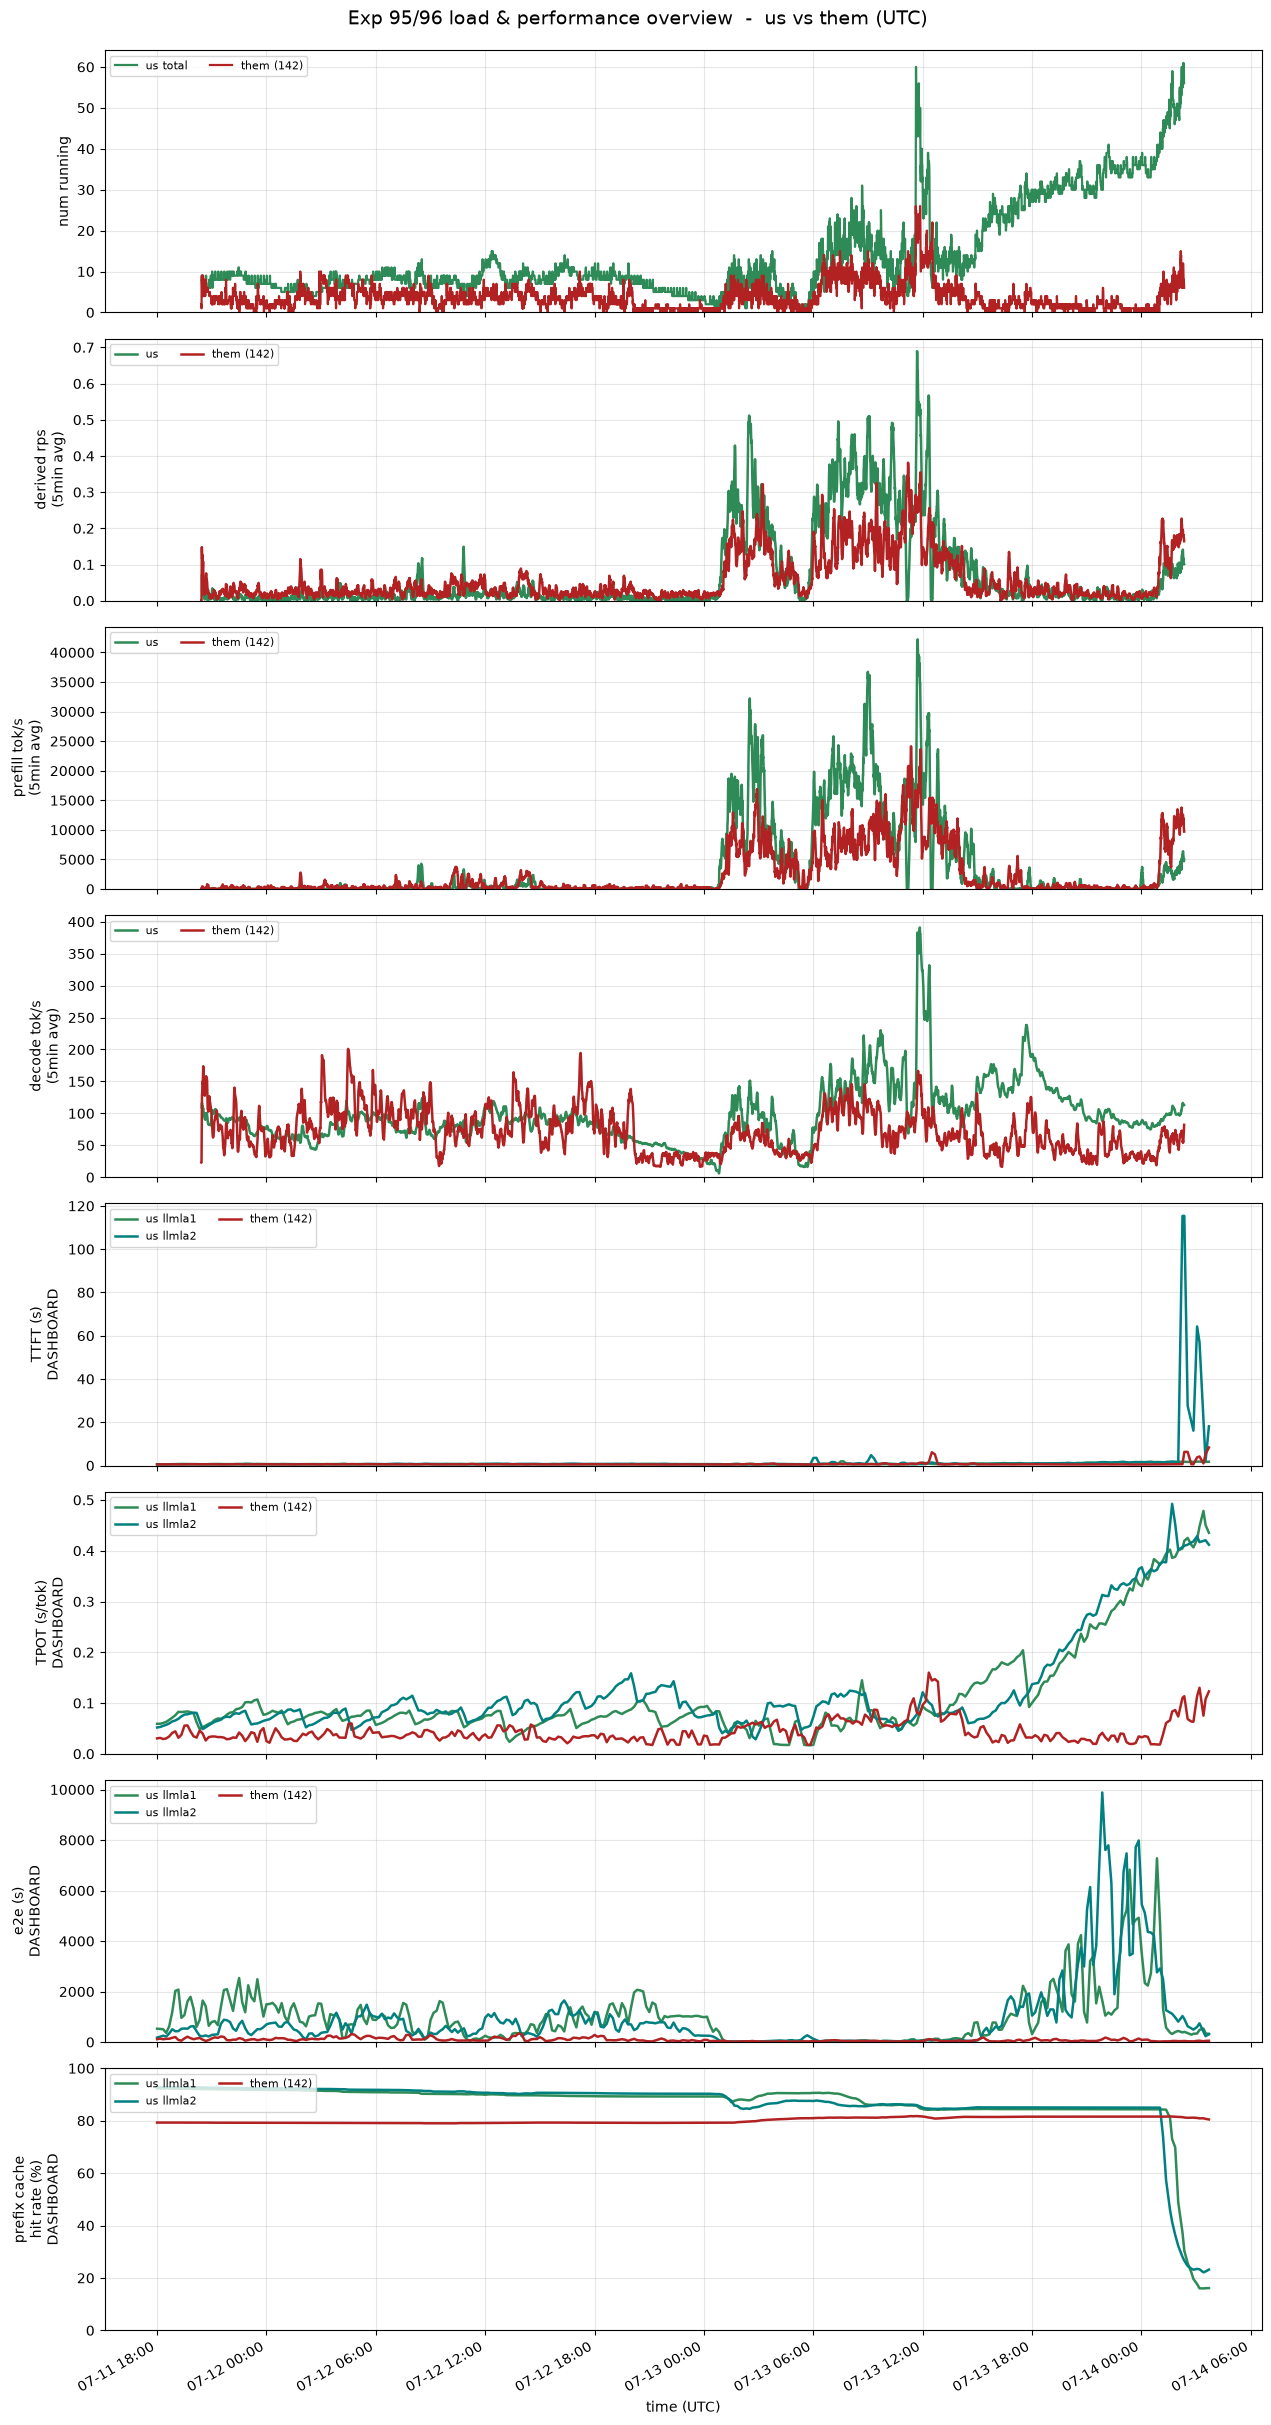

In [20]:
# ============================================================
# Combined stacked overview (shared UTC x) — us vs them
#   reuses engine_rows / fleet_series / _smooth / prefix_hit_rate / load_endpoint_logs
# ============================================================
import matplotlib.dates as mdates

GREEN, TEAL, RED = "seagreen", "teal", "firebrick"
our  = engine_rows(df96, US_ENDPOINTS)
them = engine_rows(df95)

def _sm(df, col):   # fleet sum -> 5-min smoothed series
    return _smooth(fleet_series(df, col), col, "5min")

# --- series ---
our_run, them_run = fleet_series(our, "requests_running"), fleet_series(them, "requests_running")
us_rps,  th_rps   = _sm(our, "derived_rps"),            _sm(them, "derived_rps")
us_pf,   th_pf    = _sm(our, "prefill_tokens_per_sec"), _sm(them, "prefill_tokens_per_sec")
us_gen,  th_gen   = _sm(our, "gen_tokens_per_sec"),     _sm(them, "gen_tokens_per_sec")
hq_lat  = globals().get("HQ_LAT", {})   # dashboard ttft/tpot/e2e (from cell above)
hq_hr   = globals().get("HQ_HR", {})    # dashboard cache hit rate (from cell above)
# us green / us(2nd pod) teal / them red — shared by the dashboard latency + cache panels
HQ_STYLE = {"us llmla1": GREEN, "us llmla2": TEAL, "them (142)": RED}

fig, axes = plt.subplots(8, 1, figsize=(13, 24), sharex=True,
                         gridspec_kw={"hspace": 0.10})

# 1 running
axes[0].plot(our_run["ts"],  our_run["requests_running"],  color=GREEN, lw=1.6, label="us total")
axes[0].plot(them_run["ts"], them_run["requests_running"], color=RED,   lw=1.6, label="them (142)")
axes[0].set_ylabel("num running")
# 2 derived load
axes[1].plot(us_rps.index, us_rps.values, color=GREEN, lw=1.8, label="us")
axes[1].plot(th_rps.index, th_rps.values, color=RED,   lw=1.8, label="them (142)")
axes[1].set_ylabel("derived rps\n(5min avg)")
# 3 prefill
axes[2].plot(us_pf.index, us_pf.values, color=GREEN, lw=1.8, label="us")
axes[2].plot(th_pf.index, th_pf.values, color=RED,   lw=1.8, label="them (142)")
axes[2].set_ylabel("prefill tok/s\n(5min avg)")
# 4 decode
axes[3].plot(us_gen.index, us_gen.values, color=GREEN, lw=1.8, label="us")
axes[3].plot(th_gen.index, th_gen.values, color=RED,   lw=1.8, label="them (142)")
axes[3].set_ylabel("decode tok/s\n(5min avg)")
# 5-7 dashboard TTFT / TPOT / e2e (experiments_hq); our two pods separate
for lab, col in HQ_STYLE.items():
    df = hq_lat.get(lab)
    if df is None or df.empty:
        continue
    axes[4].plot(df.index, df["ttft_s"], color=col, lw=1.8, label=lab)
    axes[5].plot(df.index, df["tpot_s"], color=col, lw=1.8, label=lab)
    axes[6].plot(df.index, df["e2e_s"],  color=col, lw=1.8, label=lab)
axes[4].set_ylabel("TTFT (s)\nDASHBOARD")
axes[5].set_ylabel("TPOT (s/tok)\nDASHBOARD")
axes[6].set_ylabel("e2e (s)\nDASHBOARD")
# 8 dashboard prefix cache hit rate (experiments_hq, cumulative)
for lab, col in HQ_STYLE.items():
    s = hq_hr.get(lab)
    if s is not None and len(s):
        axes[7].plot(s.index, s.values, color=col, lw=1.8, label=lab)
axes[7].set_ylabel("prefix cache\nhit rate (%)\nDASHBOARD")
axes[7].set_ylim(0, 100)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2, loc="upper left")
    if ax is not axes[7]:
        ax.set_ylim(bottom=0)
axes[-1].set_xlabel("time (UTC)")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle("Exp 95/96 load & performance overview  -  us vs them (UTC)",
             fontsize=14, y=0.997)
fig.autofmt_xdate()
fig.subplots_adjust(top=0.98, bottom=0.03, left=0.09, right=0.98, hspace=0.10)
plt.show()

## Our Prometheus latency — TTFT / TPOT / e2e (us vs them)

The same three latencies but straight from the vLLM/prometheus scraper (`df95`/`df96`), for
side-by-side comparison against the dashboard-sourced panels in the stacked figure above:

- **TTFT** = `ttft_seconds_avg`; **TPOT** = `(e2e_avg − ttft_avg)/output_tokens` (derived);
  **e2e** = `e2e_latency_seconds_avg`. All 5-min smoothed, our two pods summed as "us".

Note us's TPOT/e2e here are the **overload-biased averages** (they spike to thousands of seconds
during the 07-14 backlog) — precisely the artifact the dashboard/logs views avoid.

/tmp/ipykernel_854579/2836150942.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


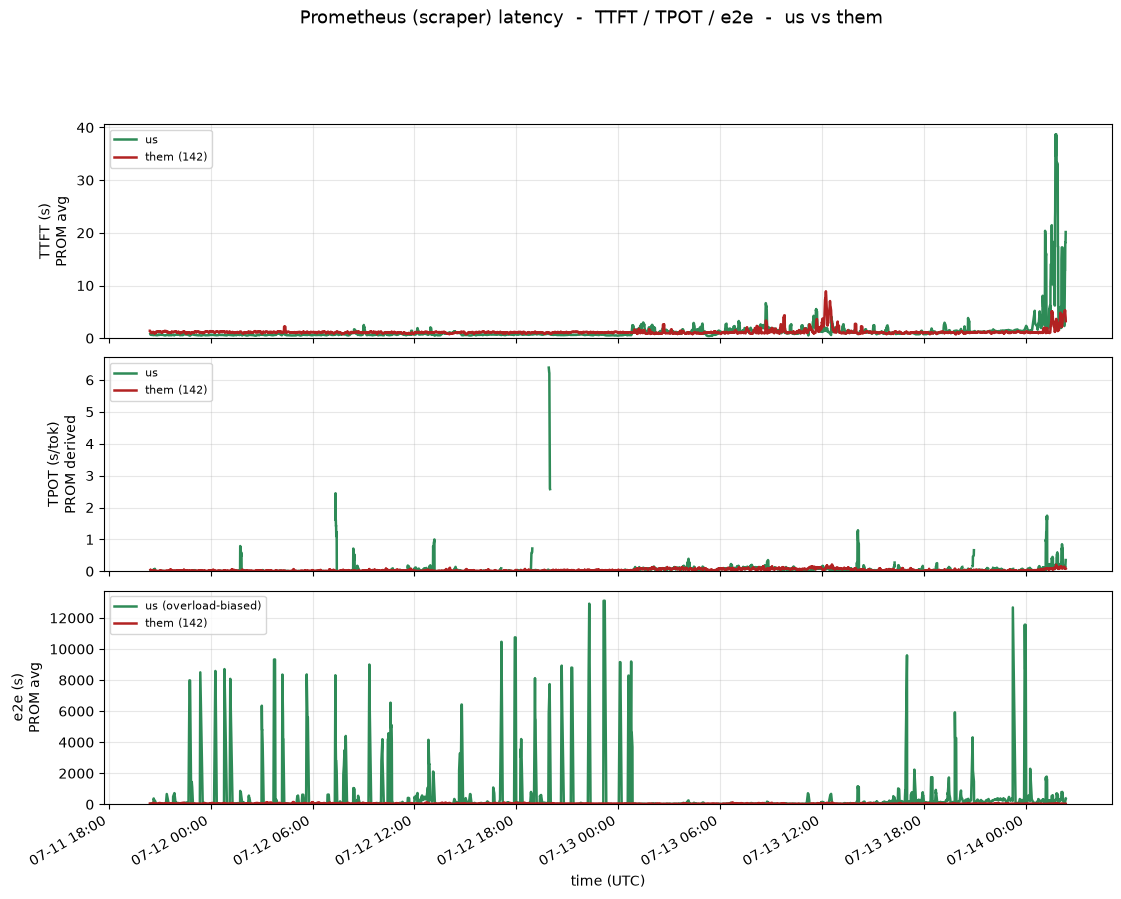

us   prom: ttft med=1.153s  tpot med=0.0236s/tok  e2e med=49.0s (biased)
them prom: ttft med=1.102s  tpot med=0.0274s/tok  e2e med=52.4s


In [21]:
# ============================================================
# Prometheus (scraper) latency — TTFT / TPOT / e2e — us vs them
#   reuses _ttft_vllm / _tpot_vllm / engine_rows / US_ENDPOINTS from above
# ============================================================
import matplotlib.dates as mdates

our  = engine_rows(df96, US_ENDPOINTS)
them = engine_rows(df95)

def _prom_e2e(df):
    return (df.dropna(subset=["e2e_latency_seconds_avg"])
              .groupby("ts")["e2e_latency_seconds_avg"].mean().rolling("5min").mean())

us_ttft, th_ttft = _ttft_vllm(our), _ttft_vllm(them)
us_tpot, th_tpot = _tpot_vllm(our), _tpot_vllm(them)
us_e2e,  th_e2e  = _prom_e2e(our),  _prom_e2e(them)

fig, (axT, axP, axE) = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                                    gridspec_kw={"hspace": 0.09})
axT.plot(us_ttft.index, us_ttft.values, color="seagreen",  lw=1.8, label="us")
axT.plot(th_ttft.index, th_ttft.values, color="firebrick", lw=1.8, label="them (142)")
axT.set_ylabel("TTFT (s)\nPROM avg")
axP.plot(us_tpot.index, us_tpot.values, color="seagreen",  lw=1.8, label="us")
axP.plot(th_tpot.index, th_tpot.values, color="firebrick", lw=1.8, label="them (142)")
axP.set_ylabel("TPOT (s/tok)\nPROM derived")
axE.plot(us_e2e.index, us_e2e.values, color="seagreen",  lw=1.8, label="us (overload-biased)")
axE.plot(th_e2e.index, th_e2e.values, color="firebrick", lw=1.8, label="them (142)")
axE.set_ylabel("e2e (s)\nPROM avg")
for ax in (axT, axP, axE):
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")
    ax.set_ylim(bottom=0)
axE.set_xlabel("time (UTC)")
axE.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle("Prometheus (scraper) latency  -  TTFT / TPOT / e2e  -  us vs them",
             fontsize=13, y=0.995)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(f"us   prom: ttft med={us_ttft.median():.3f}s  tpot med={us_tpot.median():.4f}s/tok  "
      f"e2e med={us_e2e.median():.1f}s (biased)")
print(f"them prom: ttft med={th_ttft.median():.3f}s  tpot med={th_tpot.median():.4f}s/tok  "
      f"e2e med={th_e2e.median():.1f}s")

---
# Part 2 — Root cause: KV-cache saturation → LMCache pin deadlock
_(originally `server-degradation-102-103.ipynb`; runs 102 & 103, cross-checked vs local bz and pre-update yz run 96)_

# Server degradation diagnosis — yz runs 102 & 103 (2026-07-14/15)

**Question:** after the observability update (full-request logging, Redis KV watcher,
dual `logs.json`/`logs_full.json`), a new problem appeared on the server. Is it a
**general** problem or was it **caused by the update**?

## TL;DR — NOT caused by the observability update

- **142 (reference, "them")** stayed **healthy the entire ~10 h** (running 5–21 reqs,
  3,791 requests served). → the problem is **specific to our yz stack**, not shared infra.
- **Our yz engines degraded progressively**: decode throughput fell **~106 → ~18 tok/s**
  over 9 h while running slots stayed pinned at the batch cap (~16) and the waiting queue grew.
- Endgame: **LMCache host-staging pin timeouts** (`Forcing unpin to 0`, 300 s pins) →
  vLLM step stalls → **sidecar `Read timed out` / `health check FAILED` → pulls paused** →
  router **central queue backs up to ~1,800** → requests hit the **10000 s** timeout.
- The update's components are **observer/logging only** and never touch the inference path:
  - `router_log_request_body`: router stays clean (no memory/exception/crash; only backlog timeouts).
  - Redis KV watcher: bounded (scan ~0.6 s, ~37k blocks); degradation began at 17h when Redis was clean.
- **Root cause = engine/LMCache-layer (P2P host-staging) decode-throughput degradation** on our
  deployment. The `RESULT_TIMEOUT_S=10000` config *amplifies* the symptom (requests linger 2.7 h
  instead of failing fast) but does not cause it.

Data: `src/client/experiments/_server_yz/{102,103}` (102 = external scrape of 142; 103 = `prod_latency_collector` on our router).

In [22]:
import os, re, json, gzip
from collections import defaultdict
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# yz runs (95, 96, 102, 103) live under the unified experiments_yz symlink;
# bz comparison runs (102/103/104) stay under experiments/.
YZ_BASE = os.path.join(os.path.dirname(os.getcwd()), "src", "client", "experiments_yz")
if not os.path.isdir(YZ_BASE):
    YZ_BASE = os.path.join("/home/saeid/llm-la", "src", "client", "experiments_yz")
BASE = YZ_BASE
BZ_BASE = os.path.join(os.path.dirname(YZ_BASE), "experiments")
E103 = os.path.join(YZ_BASE, "103")
E102 = os.path.join(YZ_BASE, "102")
print("yz dir:", YZ_BASE, "| exists:", os.path.isdir(E103), "| bz dir:", BZ_BASE)

OURS = {"vllm-minimax-m2-0", "vllm-minimax-m2-1"}
def is_them(i): return i.startswith("7.150.2.142") and (i.endswith(":0") or i.endswith(":1"))
def to_dt(x):
    if isinstance(x, (int, float)):
        return datetime.fromtimestamp(x, tz=timezone.utc)
    return datetime.fromisoformat(x).astimezone(timezone.utc)
plt.rcParams["figure.dpi"] = 110

yz dir: /home/saeid/llm-la/src/client/experiments_yz | exists: True | bz dir: /home/saeid/llm-la/src/client/experiments


## 1. Us vs Them — running requests & cumulative requests served

Our yz Prometheus scrapes both our engines and the 142 reference, so 103's `metrics.jsonl`
lets us compare on the identical window. **Them stays healthy; our engine metrics read ~0
(engines effectively not making progress / not scraped as healthy).**

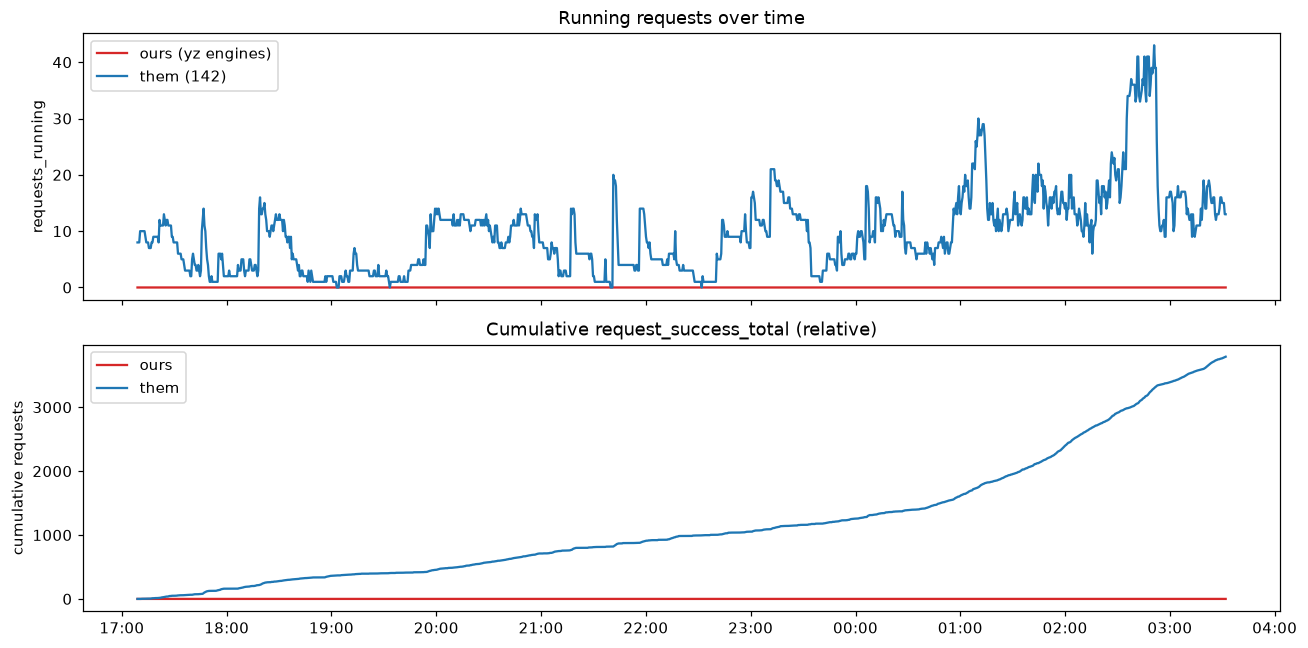

ticks: 1233


In [23]:
rows = []
with open(os.path.join(E103, "metrics.jsonl")) as f:
    for line in f:
        line = line.strip()
        if not line: continue
        try: d = json.loads(line)
        except Exception: continue
        ts = to_dt(d["ts"])
        our_run = them_run = our_tot = them_tot = 0.0
        for s in d.get("samples", []):
            i = s.get("instance", "")
            run = s.get("requests_running") or 0
            tot = s.get("request_success_total") or 0
            if i in OURS: our_run += run; our_tot += tot
            elif is_them(i): them_run += run; them_tot += tot
        rows.append((ts, our_run, them_run, our_tot, them_tot))
m = pd.DataFrame(rows, columns=["ts","our_run","them_run","our_tot","them_tot"]).set_index("ts")

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(m.index, m.our_run, label="ours (yz engines)", color="tab:red")
ax[0].plot(m.index, m.them_run, label="them (142)", color="tab:blue")
ax[0].set_ylabel("requests_running"); ax[0].legend(); ax[0].set_title("Running requests over time")
ax[1].plot(m.index, m.our_tot - m.our_tot[m.our_tot>0].min() if (m.our_tot>0).any() else m.our_tot, label="ours", color="tab:red")
ax[1].plot(m.index, m.them_tot - m.them_tot[m.them_tot>0].min() if (m.them_tot>0).any() else m.them_tot, label="them", color="tab:blue")
ax[1].set_ylabel("cumulative requests"); ax[1].legend(); ax[1].set_title("Cumulative request_success_total (relative)")
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout(); plt.show()
print("ticks:", len(m))

## 2. Engine decode throughput decay (the core symptom)

Parsed from our two engines' `vllm.log` (`Avg generation throughput … Running … Waiting`).
**Generation throughput falls ~6× (≈106 → ≈18 tok/s) while running stays pinned at the batch
cap and the waiting queue grows** — a progressive per-token slowdown, not a clean crash.

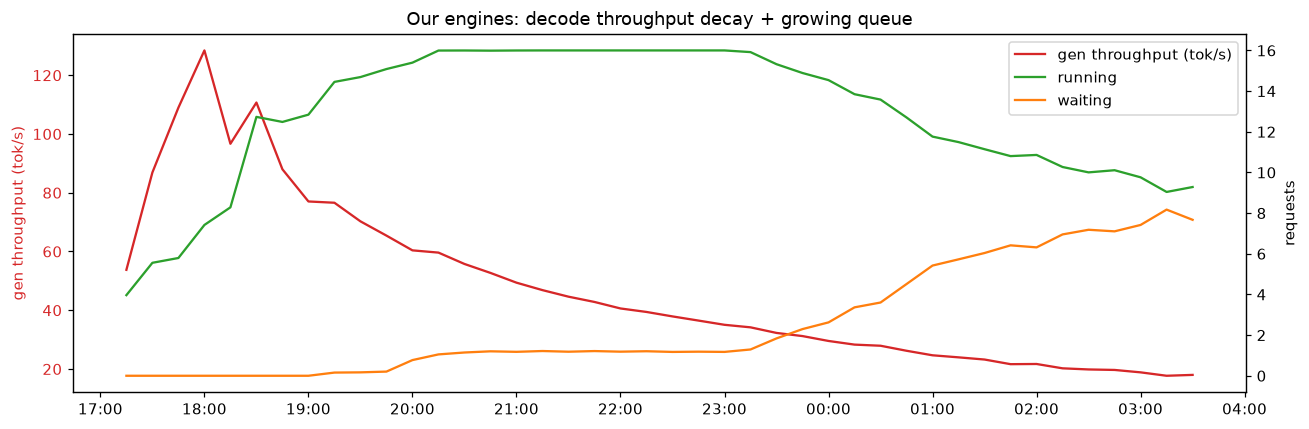

                           gen_tps  running  waiting
ts                                                  
2026-07-14 17:00:00+00:00    94.75     5.55     0.00
2026-07-14 18:00:00+00:00   105.97    10.22     0.00
2026-07-14 19:00:00+00:00    72.34    14.26     0.13
2026-07-14 20:00:00+00:00    57.13    15.84     1.04
2026-07-14 21:00:00+00:00    45.92    16.00     1.20
2026-07-14 22:00:00+00:00    38.60    16.00     1.19
2026-07-14 23:00:00+00:00    33.18    15.53     1.65
2026-07-15 00:00:00+00:00    28.00    13.67     3.52
2026-07-15 01:00:00+00:00    23.38    11.30     5.90
2026-07-15 02:00:00+00:00    20.37    10.31     6.89
2026-07-15 03:00:00+00:00    18.19     9.36     7.75


In [24]:
pat = re.compile(r"(\d\d)-(\d\d) (\d\d:\d\d:\d\d).*generation throughput: ([\d.]+) tokens/s, Running: (\d+) reqs, Waiting: (\d+)")
recs = []
for eng in ["vllm-minimax-m2-0", "vllm-minimax-m2-1"]:
    fn = os.path.join(E103, "vllm-logs", eng, "vllm.log")
    if not os.path.exists(fn): continue
    for line in open(fn, errors="ignore"):
        mo = pat.search(line)
        if not mo: continue
        t = datetime.strptime(f"2026-{mo.group(1)}-{mo.group(2)} {mo.group(3)}", "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
        recs.append((t, eng, float(mo.group(4)), int(mo.group(5)), int(mo.group(6))))
g = pd.DataFrame(recs, columns=["ts","engine","gen_tps","running","waiting"])
gh = g.set_index("ts").resample("15min").agg({"gen_tps":"mean","running":"mean","waiting":"mean"})

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(gh.index, gh.gen_tps, color="tab:red", label="gen throughput (tok/s)")
ax.set_ylabel("gen throughput (tok/s)", color="tab:red"); ax.tick_params(axis='y', labelcolor="tab:red")
ax2 = ax.twinx()
ax2.plot(gh.index, gh.running, color="tab:green", label="running")
ax2.plot(gh.index, gh.waiting, color="tab:orange", label="waiting")
ax2.set_ylabel("requests")
ax.set_title("Our engines: decode throughput decay + growing queue")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
l1,lb1 = ax.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc="upper right")
plt.tight_layout(); plt.show()
print(g.set_index("ts").resample("1h").agg({"gen_tps":"mean","running":"mean","waiting":"mean"}).round(2))

## 3. Request completions collapse (ground truth from `logs.json`)

Closed-loop clients complete fewer requests as latency climbs. Completions/hour:
432 → 299 → 188 → 44 → 5 → 1 → 0.

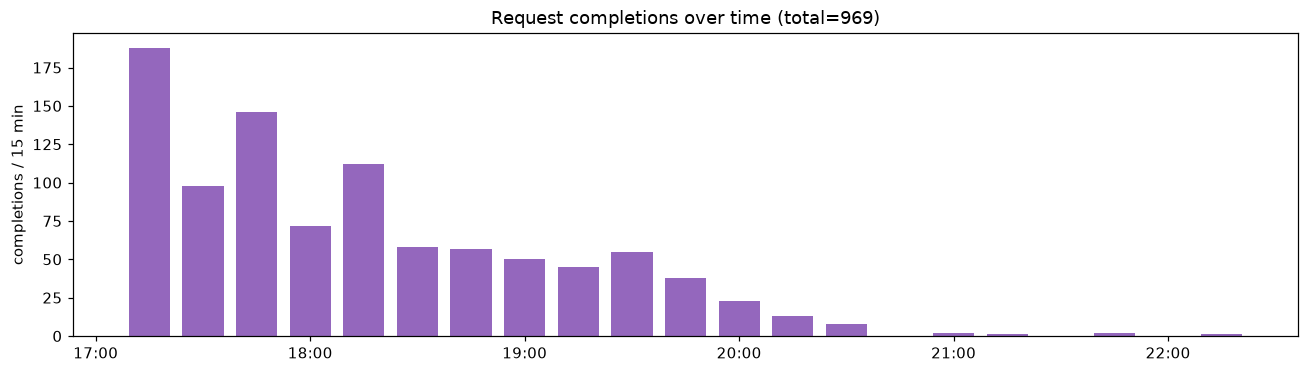

per-hour: {Timestamp('2026-07-14 17:00:00+0000', tz='UTC'): 432, Timestamp('2026-07-14 18:00:00+0000', tz='UTC'): 299, Timestamp('2026-07-14 19:00:00+0000', tz='UTC'): 188, Timestamp('2026-07-14 20:00:00+0000', tz='UTC'): 44, Timestamp('2026-07-14 21:00:00+0000', tz='UTC'): 5, Timestamp('2026-07-14 22:00:00+0000', tz='UTC'): 1}


In [25]:
ts = []
for line in open(os.path.join(E103, "logs.json")):
    line = line.strip()
    if not line: continue
    try: r = json.loads(line)
    except Exception: continue
    t = r.get("t1_wall") or r.get("t0_wall")
    if t: ts.append(to_dt(float(t)))
s = pd.Series(1, index=pd.DatetimeIndex(ts)).sort_index()
comp = s.resample("15min").sum()
fig, ax = plt.subplots(figsize=(12,3.5))
ax.bar(comp.index, comp.values, width=0.008, color="tab:purple")
ax.set_ylabel("completions / 15 min"); ax.set_title(f"Request completions over time (total={len(ts)})")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout(); plt.show()
print("per-hour:", s.resample("1h").sum().to_dict())

## 4. LMCache pin-timeout & sidecar-health onset (the deadlock tail)

These are the **endgame** symptoms, appearing *after* completions had already collapsed —
confirming the engine was already stuck. `Pin timeout … Forcing unpin to 0` = a KV memory
object held (host-staging transfer) never released within 300 s.

pin timeouts: 896 first: 2026-07-14 23:59:34+00:00 last: 2026-07-15 03:22:04+00:00


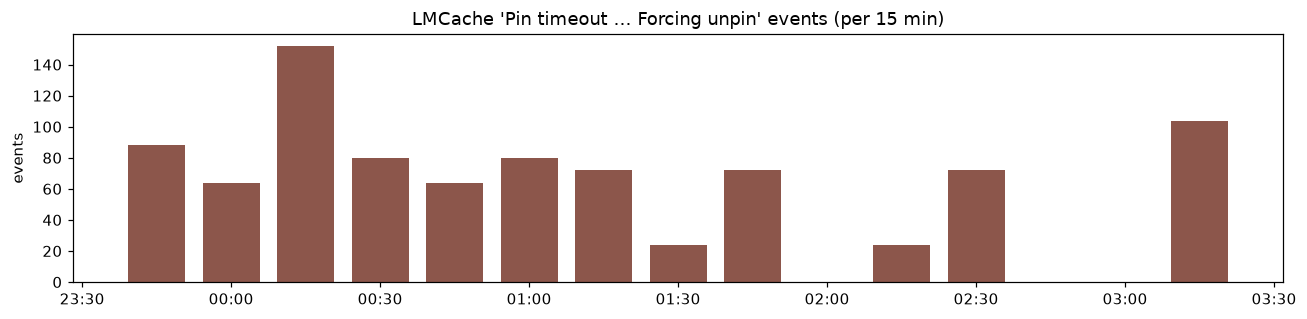

vllm-minimax-m2-0 | read-timeouts: 19 | health FAILED: 1
vllm-minimax-m2-1 | read-timeouts: 13 | health FAILED: 6


In [26]:
def scan(paths, needle):
    out = []
    tp = re.compile(r"(\d{4}-\d\d-\d\d[ T]\d\d:\d\d:\d\d)|(\d\d-\d\d \d\d:\d\d:\d\d)")
    for p in paths:
        if not os.path.exists(p): continue
        for line in open(p, errors="ignore"):
            if needle not in line: continue
            mo = tp.search(line)
            if not mo: 
                out.append(None); continue
            raw = mo.group(0)
            try:
                if raw[:4].isdigit():
                    t = datetime.fromisoformat(raw.replace(" ","T")).replace(tzinfo=timezone.utc)
                else:
                    t = datetime.strptime("2026-"+raw, "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
                out.append(t)
            except Exception:
                out.append(None)
    return [x for x in out if x]

vlogs = [os.path.join(E103,"vllm-logs",e,"vllm.log") for e in ["vllm-minimax-m2-0","vllm-minimax-m2-1"]]
slogs = [os.path.join(E103,"vllm-logs",e,"kv-sidecar.log") for e in ["vllm-minimax-m2-0","vllm-minimax-m2-1"]]
pins = scan(vlogs, "Pin timeout detected")
print("pin timeouts:", len(pins), "first:", min(pins) if pins else None, "last:", max(pins) if pins else None)

if pins:
    ps = pd.Series(1, index=pd.DatetimeIndex(pins)).sort_index().resample("15min").sum()
    fig, ax = plt.subplots(figsize=(12,3))
    ax.bar(ps.index, ps.values, width=0.008, color="tab:brown")
    ax.set_title("LMCache 'Pin timeout … Forcing unpin' events (per 15 min)")
    ax.set_ylabel("events")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.tight_layout(); plt.show()

# sidecar health/timeouts (no reliable per-line ts) -> just counts
for p in slogs:
    if not os.path.exists(p): continue
    txt = open(p, errors="ignore").read()
    print(os.path.basename(os.path.dirname(p)),
          "| read-timeouts:", txt.count("Read timed out"),
          "| health FAILED:", txt.count("health check FAILED"))

## 5. Router: central-queue backlog & 10000 s timeouts

The router is otherwise **clean** (no OOM/exception/crash), which rules out
`router_log_request_body` as a cause. It shows only **backlog timeouts** — a *consequence*
of the slow engines: the central queue grows to ~1,800 and requests hit `RESULT_TIMEOUT_S=10000`.

router API timeouts: 41
       after_s  queue_len
count     41.0       41.0
mean   10000.1      972.4
std        0.1      415.0
min    10000.0      500.0
25%    10000.0      615.0
50%    10000.0      852.0
75%    10000.0     1193.0
max    10000.4     1839.0


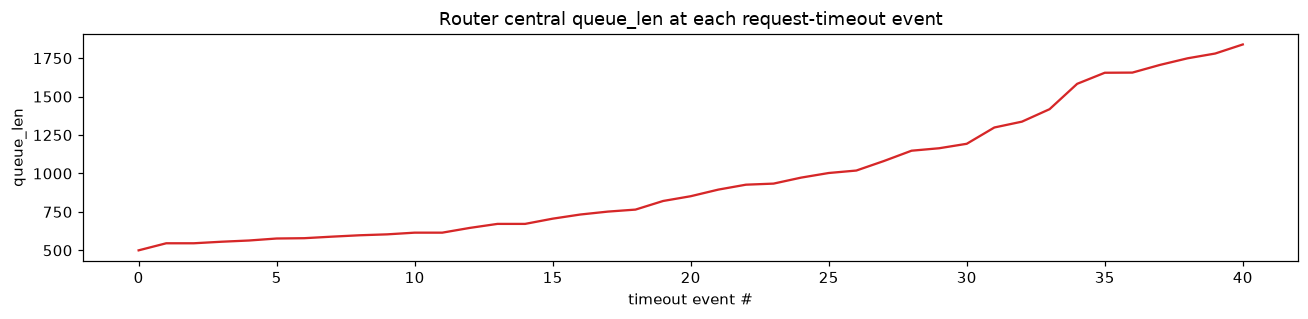

router 'Traceback': 0
router 'MemoryError': 0
router 'OOM': 0
router 'Segmentation': 0
router 'killed': 0


In [27]:
rlog = None
import glob
for p in glob.glob(os.path.join(E103, "vllm-logs", "router-service-*", "router.log")):
    rlog = p
qpat = re.compile(r"timeout rid=\S+ after ([\d.]+)s \(queue_len=(\d+)\)")
qs = []
if rlog:
    for line in open(rlog, errors="ignore"):
        mo = qpat.search(line)
        if mo: qs.append((float(mo.group(1)), int(mo.group(2))))
print("router API timeouts:", len(qs))
if qs:
    qdf = pd.DataFrame(qs, columns=["after_s","queue_len"])
    print(qdf.describe().round(1))
    fig, ax = plt.subplots(figsize=(12,3))
    ax.plot(range(len(qdf)), qdf.queue_len, color="tab:red")
    ax.set_title("Router central queue_len at each request-timeout event")
    ax.set_ylabel("queue_len"); ax.set_xlabel("timeout event #")
    plt.tight_layout(); plt.show()
# confirm router is clean of crash signatures
if rlog:
    txt = open(rlog, errors="ignore").read()
    for sig in ["Traceback","MemoryError","OOM","Segmentation","killed"]:
        print(f"router '{sig}':", txt.count(sig))

## 6. Redis KV watcher — bounded (rules out the observability update)

My added watcher is the biggest new file (152 MB) but that size is just **94 periodic
full-baseline dumps** of a ~37k-block map. Scans are ~0.6 s and `kv_blocks` plateaus —
no runaway. Degradation began at 17h when scans were ~0.15 s, so the watcher is not the cause.

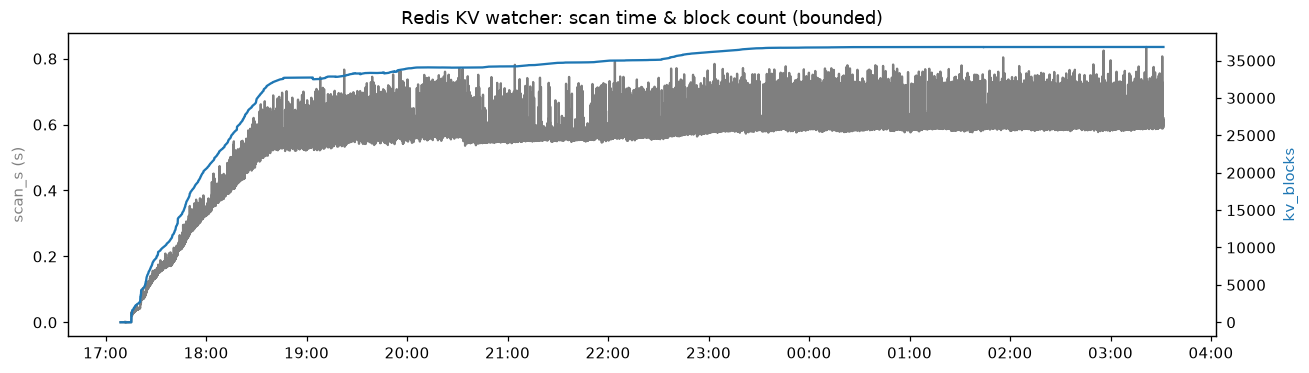

scan_s: mean=0.541 max=0.836 | kv_blocks max=36824


In [28]:
rows = []
with open(os.path.join(E103, "redis_kv_watch.jsonl")) as f:
    for line in f:
        line = line.strip()
        if not line: continue
        try: d = json.loads(line)
        except Exception: continue
        rows.append((to_dt(d["ts"]), d.get("scan_s",0) or 0, d.get("kv_blocks",0) or 0))
r = pd.DataFrame(rows, columns=["ts","scan_s","kv_blocks"]).set_index("ts")
fig, ax = plt.subplots(figsize=(12,3.5))
ax.plot(r.index, r.scan_s, color="tab:gray", label="scan_s")
ax.set_ylabel("scan_s (s)", color="tab:gray")
ax2 = ax.twinx(); ax2.plot(r.index, r.kv_blocks, color="tab:blue", label="kv_blocks")
ax2.set_ylabel("kv_blocks", color="tab:blue")
ax.set_title("Redis KV watcher: scan time & block count (bounded)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout(); plt.show()
print("scan_s: mean=%.3f max=%.3f | kv_blocks max=%d" % (r.scan_s.mean(), r.scan_s.max(), r.kv_blocks.max()))

## Conclusion

The failure is a **progressive engine/LMCache-layer degradation on our yz deployment**
(host-staging P2P), culminating in pin-timeout stalls, sidecar health failures, and a
massive router backlog. It is **not** caused by the observability update — the router body
logging, dual logs, and Redis watcher are observer/logging-only and stay bounded and clean,
and the **142 reference ran healthy the whole time** on the same infra.

**Recommended next steps**
1. Reproduce on yz with the same load but **LMCache P2P host-staging disabled** (or shorter
   pin timeout) to confirm the pin-timeout deadlock is the driver.
2. Watch `lmcache:*` metrics (local/remote cache usage, `time_to_retrieve`, pin counts) for
   the slow ramp; correlate the gen-tps decay with LMCache CPU/host-staging growth.
3. Lower `RESULT_TIMEOUT_S` from 10000 s so a stalled engine fails fast instead of building a
   ~1,800-deep backlog (symptom mitigation, not a fix).
4. Compare engine build/image (`imagePullPolicy: Always` pulls mutable `:latest`) against 142's
   to rule out a regressed engine/LMCache image.

---
# 7. Cross-check: yz server vs local **bz** runs — is the setup different?

To decide whether the failure is intrinsic to our stack or specific to the yz *setup/regime*,
compare the degraded yz server run against the **local bz runs** (`experiments/102,103,104`,
cluster `192.168.0.79`, claude-mode load). Same chart family (`boom-minmax-lmcache-p2p-hoststaging-affinity`),
same NPU engine, but a different operating point.

**Bottom line:** the engine config is essentially identical; the difference is the **operating
regime + workload**: yz ran a **10 h saturated soak** (`max_num_seqs=16`, running pinned at the
cap, queue growing) with **very large prompts**, which accumulated LMCache host-staging pressure
until pins deadlocked. The bz runs were **short (3–4 h), never saturated (waiting=0), used
smaller prompts, and got fresh pods each run** — so they never entered the failure regime.
`0` pin timeouts on bz vs `896+` on yz.

In [29]:
# BZ_BASE (experiments/) is defined in the Part 2 setup cell above.
BZ_RUNS = ["102", "103", "104"]         # local bz (claude) runs with load

def extract_cfg(vlog):
    # Pull key engine/LMCache config echoed at startup
    keys = {
        "max_num_seqs": re.compile(r"'max_num_seqs': (\d+)"),
        "max_num_batched_tokens": re.compile(r"max_num_batched_tokens=(\d+)"),
        "tensor_parallel_size": re.compile(r"tensor_parallel_size=(\d+)"),
        "data_parallel_size": re.compile(r"data_parallel_size=(\d+)"),
        "gpu_kv_cache_tokens": re.compile(r"GPU KV cache size: ([\d,]+) tokens"),
        "max_concurrency": re.compile(r"Maximum concurrency for [\d,]+ tokens per request: ([\d.]+)"),
        "lmc_chunk_size": re.compile(r"chunk_size=(\d+)"),
        "p2p_backend": re.compile(r"(AscendP2PBackend)"),
    }
    out = {}
    if not os.path.exists(vlog): return out
    txt = open(vlog, errors="ignore").read()
    for k, rgx in keys.items():
        m = rgx.search(txt)
        if m: out[k] = m.group(1)
    return out

yz_cfg = extract_cfg(os.path.join(E103, "vllm-logs", "vllm-minimax-m2-0", "vllm.log"))
bz_cfg = extract_cfg(os.path.join(BZ_BASE, "103", "vllm-logs", "vllm-minimax-m2-0", "vllm.log"))
cfg = pd.DataFrame({"yz (server 103)": yz_cfg, "bz (local 103)": bz_cfg})
cfg["same?"] = cfg.iloc[:,0] == cfg.iloc[:,1]
print("Engine / LMCache config echoed at startup:")
print(cfg.to_string())

Engine / LMCache config echoed at startup:
                         yz (server 103)    bz (local 103)  same?
max_num_seqs                          16                32  False
max_num_batched_tokens             32768             32768   True
tensor_parallel_size                   8                 8   True
data_parallel_size                     2                 2   True
gpu_kv_cache_tokens            1,180,416         1,180,416   True
max_concurrency                     6.00              6.00   True
lmc_chunk_size                       512               512   True
p2p_backend             AscendP2PBackend  AscendP2PBackend   True


### 7a. Engine throughput trend — bz stays healthy (waiting=0), yz decays

Overlay per-hour decode throughput and the **waiting queue** for both. The waiting queue is the
tell: **bz never queues (=0)** → never saturated → no host-staging build-up; **yz's queue grows**
as throughput collapses.

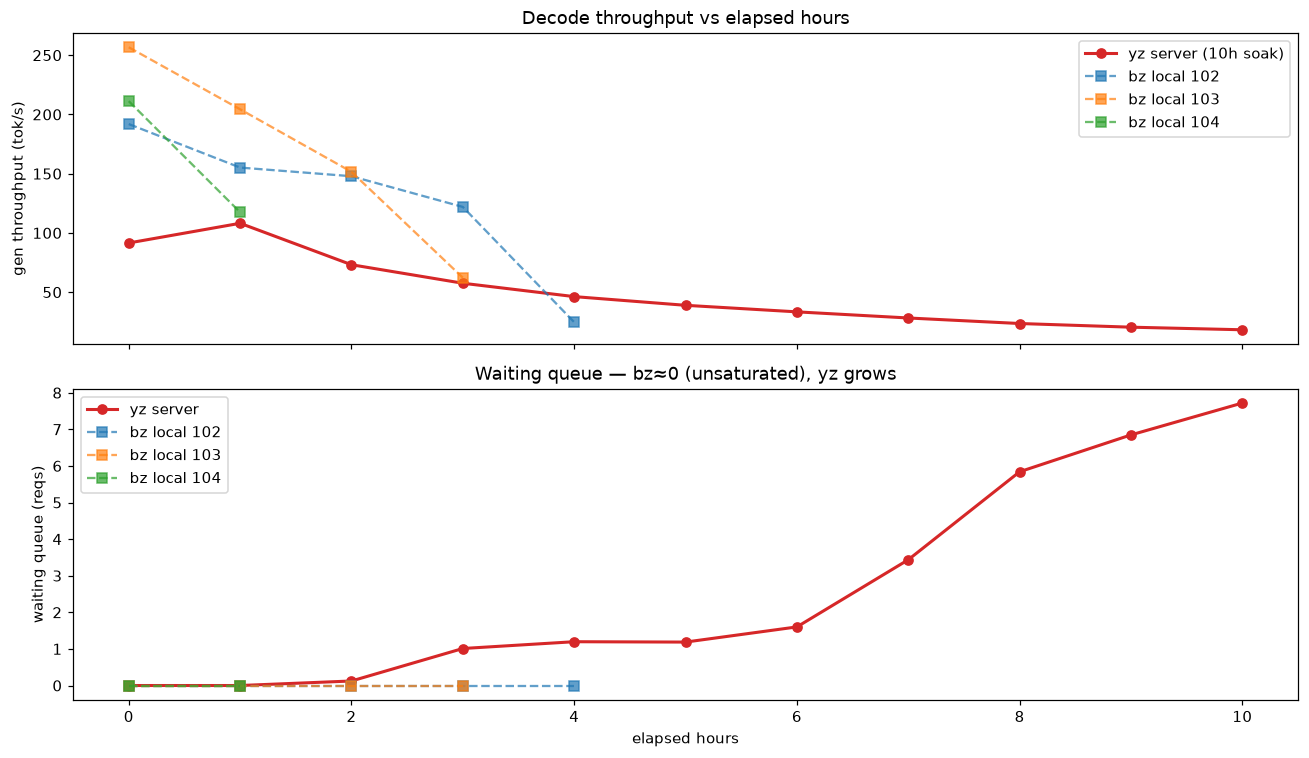

In [30]:
def eng_trend(vdir):
    recs = []
    for eng in ["vllm-minimax-m2-0", "vllm-minimax-m2-1"]:
        fn = os.path.join(vdir, "vllm-logs", eng, "vllm.log")
        if not os.path.exists(fn): continue
        for line in open(fn, errors="ignore"):
            mo = pat.search(line)
            if not mo: continue
            t = datetime.strptime(f"2026-{mo.group(1)}-{mo.group(2)} {mo.group(3)}", "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
            recs.append((t, float(mo.group(4)), int(mo.group(5)), int(mo.group(6))))
    df = pd.DataFrame(recs, columns=["ts","gen_tps","running","waiting"]).set_index("ts").sort_index()
    return df

# elapsed-hours x-axis so different wall-clock windows overlay
def elapsed(df):
    if df.empty: return df
    df = df.copy(); df["h"] = (df.index - df.index[0]).total_seconds()/3600.0
    return df

yz = elapsed(eng_trend(E103))
bzs = {r: elapsed(eng_trend(os.path.join(BZ_BASE, r))) for r in BZ_RUNS}

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
def rs(df, col):
    g = df.copy(); g["hb"] = (g["h"]).round(0)
    return g.groupby("hb")[col].mean()
ax[0].plot(rs(yz,"gen_tps").index, rs(yz,"gen_tps").values, "o-", color="tab:red", lw=2, label="yz server (10h soak)")
for r, df in bzs.items():
    if df.empty: continue
    s = rs(df,"gen_tps"); ax[0].plot(s.index, s.values, "s--", alpha=0.7, label=f"bz local {r}")
ax[0].set_ylabel("gen throughput (tok/s)"); ax[0].set_title("Decode throughput vs elapsed hours"); ax[0].legend()
ax[1].plot(rs(yz,"waiting").index, rs(yz,"waiting").values, "o-", color="tab:red", lw=2, label="yz server")
for r, df in bzs.items():
    if df.empty: continue
    s = rs(df,"waiting"); ax[1].plot(s.index, s.values, "s--", alpha=0.7, label=f"bz local {r}")
ax[1].set_ylabel("waiting queue (reqs)"); ax[1].set_xlabel("elapsed hours"); ax[1].set_title("Waiting queue — bz≈0 (unsaturated), yz grows")
ax[1].legend()
plt.tight_layout(); plt.show()

### 7b. Pin timeouts & workload (prompt/output sizes)

Pin-timeout deadlock happens **only on yz**. And the yz workload uses **far larger prompts**
(lmsys long conversations) than the bz claude workload — more KV blocks to stage/transfer via
LMCache P2P host-staging, sustained at saturation.

          run  pin_timeouts  reqs      out_med_p95_max       in_med_p95_max
yz server 103          2792   969   (666, 2098, 16384) (4092, 68088, 87955)
 bz local 102             0  1420 (1440, 27922, 32000) (1149, 22894, 64832)
 bz local 103             0  1421 (1486, 28678, 32000) (1241, 10262, 65972)
 bz local 104             0  1378     (0, 4694, 32000)   (709, 2732, 33355)


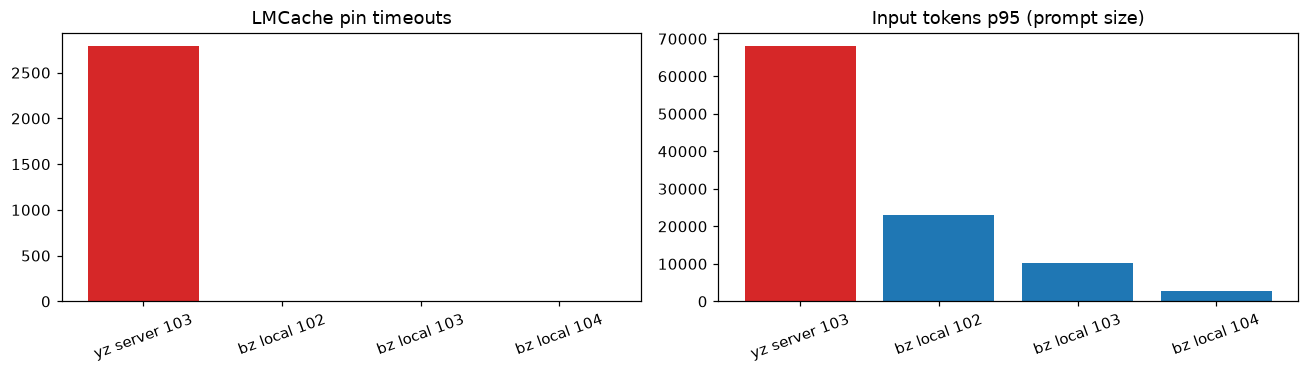

In [31]:
import glob as _glob
def count_pins(vdir):
    n = 0
    for fn in _glob.glob(os.path.join(vdir, "vllm-logs", "vllm-minimax-m2-*", "vllm.log")):
        n += sum(1 for l in open(fn, errors="ignore") if "Pin timeout detected" in l)
    return n

def tok_stats(logs):
    outs, ins = [], []
    if not os.path.exists(logs): return None
    for l in open(logs, errors="ignore"):
        l = l.strip()
        if not l: continue
        try: r = json.loads(l)
        except Exception: continue
        o = r.get("completion_tokens"); i = r.get("prompt_tokens")
        if o is not None: outs.append(o)
        if i is not None: ins.append(i)
    f = lambda x: (int(np.median(x)), int(np.percentile(x,95)), int(max(x))) if x else (0,0,0)
    return {"reqs": len(outs), "out_med_p95_max": f(outs), "in_med_p95_max": f(ins)}

summary = []
summary.append(("yz server 103", count_pins(E103), tok_stats(os.path.join(E103,"logs.json"))))
for r in BZ_RUNS:
    summary.append((f"bz local {r}", count_pins(os.path.join(BZ_BASE,r)), tok_stats(os.path.join(BZ_BASE,r,"logs.json"))))
sdf = pd.DataFrame([{"run":n, "pin_timeouts":p, **(t or {})} for n,p,t in summary])
print(sdf.to_string(index=False))

# bar: pin timeouts + input-token p95
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
names = [s[0] for s in summary]; pins = [s[1] for s in summary]
ax[0].bar(names, pins, color=["tab:red"]+["tab:blue"]*len(BZ_RUNS)); ax[0].set_title("LMCache pin timeouts"); ax[0].tick_params(axis='x', rotation=20)
inp95 = [ (s[2] or {}).get("in_med_p95_max",(0,0,0))[1] for s in summary ]
ax[1].bar(names, inp95, color=["tab:red"]+["tab:blue"]*len(BZ_RUNS)); ax[1].set_title("Input tokens p95 (prompt size)"); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

### 7c. Verdict on "is the setup different?"

- **Engine/LMCache config: essentially identical** (same TP=8, DP=2, `max_num_batched_tokens=32768`,
  GPU KV cache 1.18M tokens, per-request concurrency cap 6, LMCache `chunk_size=512`, AscendP2PBackend).
  The **only engine knob that differs is `max_num_seqs` (yz 16 vs bz 32)** — and yz saturated
  exactly at its 16 cap.
- **What actually differs is the regime + workload, not the code/build:**
  - yz: **10 h saturated soak**, running pinned at the cap, **waiting queue grows**, **huge prompts**
    (p95 ≈ 68k input tokens) → sustained LMCache host-staging/P2P pressure → pin deadlock.
  - bz: **short (3–4 h), unsaturated (waiting=0)**, smaller prompts, **fresh pods per run** (LMCache
    CPU tier reset each time) → pressure never accumulates → **0 pin timeouts**.
- Nothing here points at the observability update (body logging / dual logs / Redis watcher).
  The bz runs used the same engine image family and did **not** degrade because they never entered
  the saturated, long-soak, large-prompt regime.

**How to actually reproduce/confirm:** run bz (or yz) as a **long saturated soak with the lmsys
large-prompt workload** and `max_num_seqs=16`, single continuous deployment (no pod restarts). If
the gen-tps decay + pin timeouts reappear, the driver is confirmed as LMCache P2P host-staging
under sustained saturation — independent of the logging changes.

---
# 8. Reading the actual vLLM logs (not just config)

Going line-by-line through the engine logs pins the mechanism precisely.

**8.1 The `P2P event loop STALLED` warning is a red herring.** Both yz and bz log **exactly 64**
of them, all in a **~13 s burst at startup** (model load / graph capture), with identical
magnitudes (median ~757 ms, max ~825 ms). It never recurs at runtime on either side, so it is
**not** the cause of the yz collapse.

**8.2 The real divergence is GPU KV-cache saturation.** On yz the `GPU KV cache usage` climbs
monotonically to **100%**; on bz it sits at **~6–11%** the whole time. The **LMCache pin timeouts
begin exactly when yz KV hits ~97–100%** — i.e. once the GPU cache is full, the engine leans hard
on LMCache host-staging offload/eviction, and under sustained saturation the P2P transfer pins
deadlock (held >300 s → force-unpin). yz also shows **preemptions (4)** and **out-of-order engine
steps (5)**; bz shows **none**.

The driver is the **workload**: yz's large lmsys prompts (p95 ≈ 68k input tokens) × 16 concurrent
overrun the 1.18M-token GPU KV cache; bz's small claude prompts (mean ≈ 3.2k) never do.

In [32]:
# --- P2P event loop STALL: startup-only, identical on both ---
def stalls(vdir):
    mags, tstamps = [], []
    for fn in _glob.glob(os.path.join(vdir, "vllm-logs", "vllm-minimax-m2-*", "vllm.log")):
        for line in open(fn, errors="ignore"):
            if "event loop STALLED" not in line: continue
            s = re.sub(r"\x1b\[[0-9;]*m", "", line)
            mo = re.search(r"STALLED ~(\d+) ms", s)
            to = re.search(r"(\d\d)-(\d\d) (\d\d:\d\d:\d\d)", s)
            if mo: mags.append(int(mo.group(1)))
            if to: tstamps.append(f"{to.group(1)}-{to.group(2)} {to.group(3)}")
    span = (min(tstamps), max(tstamps)) if tstamps else (None, None)
    return len(mags), (int(np.median(mags)) if mags else 0), (max(mags) if mags else 0), span

print("P2P event-loop STALL warnings (all engines):")
print("  yz server 103 :", stalls(E103))
for r in BZ_RUNS:
    print(f"  bz local {r}  :", stalls(os.path.join(BZ_BASE, r)))
print("  -> (count, median_ms, max_ms, (first_ts,last_ts)); note the tiny time span = startup burst")

P2P event-loop STALL warnings (all engines):
  yz server 103 : (64, 755, 822, ('07-14 17:27:10', '07-14 17:27:23'))
  bz local 102  : (64, 762, 843, ('07-14 03:43:13', '07-14 03:43:25'))


  bz local 103  : (64, 756, 826, ('07-14 07:34:00', '07-14 07:34:13'))
  bz local 104  : (64, 750, 806, ('07-14 10:55:32', '07-14 10:55:45'))
  -> (count, median_ms, max_ms, (first_ts,last_ts)); note the tiny time span = startup burst


### 8.3 GPU KV-cache usage over time — the smoking gun

yz fills to 100% and stays there; bz stays ~10%. Pin-timeout onset (red dashed line) lands right
where yz saturates.

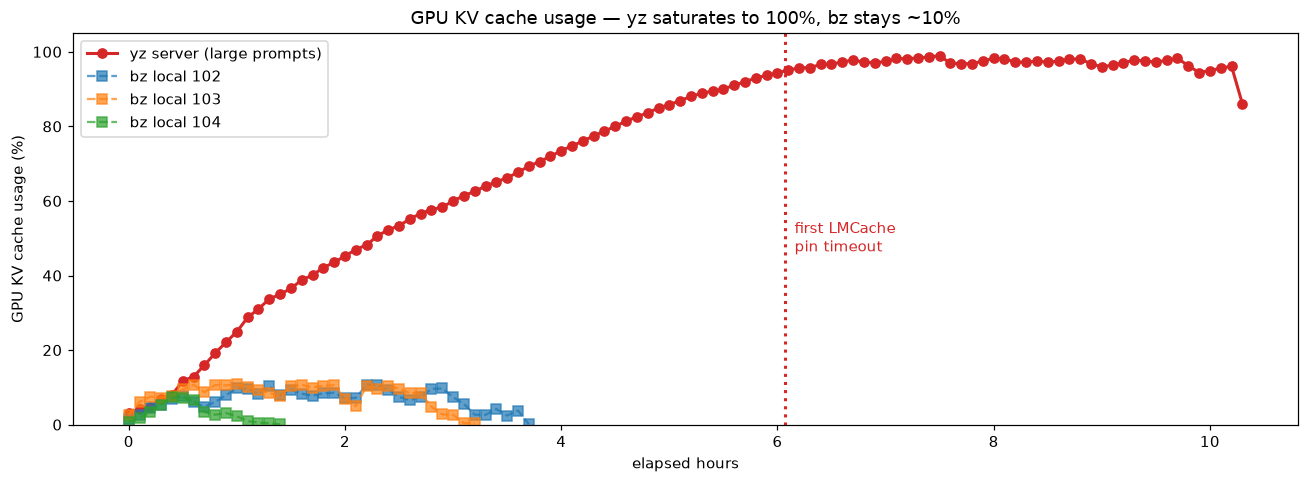

In [33]:
def kv_trend(vdir):
    recs = []
    for eng in ["vllm-minimax-m2-0", "vllm-minimax-m2-1"]:
        fn = os.path.join(vdir, "vllm-logs", eng, "vllm.log")
        if not os.path.exists(fn): continue
        for line in open(fn, errors="ignore"):
            if "GPU KV cache usage" not in line: continue
            s = re.sub(r"\x1b\[[0-9;]*m", "", line)
            mo = re.search(r"(\d\d)-(\d\d) (\d\d:\d\d:\d\d).*GPU KV cache usage: ([\d.]+)%", s)
            if not mo: continue
            t = datetime.strptime(f"2026-{mo.group(1)}-{mo.group(2)} {mo.group(3)}", "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
            recs.append((t, float(mo.group(4))))
    df = pd.DataFrame(recs, columns=["ts","kv"]).set_index("ts").sort_index()
    if not df.empty:
        df["h"] = (df.index - df.index[0]).total_seconds()/3600.0
    return df

yzkv = kv_trend(E103)
bzkv = {r: kv_trend(os.path.join(BZ_BASE, r)) for r in BZ_RUNS}

# first pin-timeout in elapsed hours for yz
first_pin_h = None
if not yzkv.empty:
    for fn in _glob.glob(os.path.join(E103, "vllm-logs", "vllm-minimax-m2-*", "vllm.log")):
        for line in open(fn, errors="ignore"):
            if "Pin timeout detected" in line:
                mo = re.search(r"(\d{4}-\d\d-\d\d) (\d\d:\d\d:\d\d)", re.sub(r"\x1b\[[0-9;]*m","",line))
                if mo:
                    t = datetime.strptime(f"{mo.group(1)} {mo.group(2)}", "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
                    first_pin_h = (t - yzkv.index[0]).total_seconds()/3600.0
                    break
        if first_pin_h is not None: break

fig, ax = plt.subplots(figsize=(12, 4.5))
g = yzkv.copy(); g["hb"] = g["h"].round(1); s = g.groupby("hb")["kv"].mean()
ax.plot(s.index, s.values, "o-", color="tab:red", lw=2, label="yz server (large prompts)")
for r, df in bzkv.items():
    if df.empty: continue
    g = df.copy(); g["hb"] = g["h"].round(1); s = g.groupby("hb")["kv"].mean()
    ax.plot(s.index, s.values, "s--", alpha=0.7, label=f"bz local {r}")
if first_pin_h is not None:
    ax.axvline(first_pin_h, color="tab:red", ls=":", lw=2)
    ax.text(first_pin_h, 50, "  first LMCache\n  pin timeout", color="tab:red", va="center")
ax.set_xlabel("elapsed hours"); ax.set_ylabel("GPU KV cache usage (%)")
ax.set_title("GPU KV cache usage — yz saturates to 100%, bz stays ~10%")
ax.legend(); ax.set_ylim(0, 105)
plt.tight_layout(); plt.show()

### 8.4 Runtime-only signals that appear on yz and never on bz

Startup config warnings (`save_only_first_rank`, `builtin` hash, KVConnector experimental) are
identical on both. Only the **KV-pressure signals** differ.

In [34]:
def count(vdir, needle, regex=False):
    n = 0
    for fn in _glob.glob(os.path.join(vdir, "vllm-logs", "vllm-minimax-m2-*", "vllm.log")):
        for line in open(fn, errors="ignore"):
            s = re.sub(r"\x1b\[[0-9;]*m", "", line)
            if (re.search(needle, s) if regex else (needle in s)):
                n += 1
    return n

sigs = {
    "Pin timeout detected": "Pin timeout detected",
    "Force unpinned":       "Force unpinned",
    "preemption (Preempt)": r"[Pp]reempt",
    "out-of-order step":    "out-of-order step",
    "P2P event loop STALL": "event loop STALLED",
}
rows = []
for label, needle in sigs.items():
    row = {"signal": label, "yz-103": count(E103, needle, regex=needle.startswith("["))}
    for r in BZ_RUNS:
        row[f"bz-{r}"] = count(os.path.join(BZ_BASE, r), needle, regex=needle.startswith("["))
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

              signal  yz-103  bz-102  bz-103  bz-104
Pin timeout detected    2792       0       0       0
      Force unpinned     240       0       0       0
preemption (Preempt)       4       0       0       0
   out-of-order step       5       0       0       0
P2P event loop STALL      64      64      64      64


### 8.5 What the logs prove

- The engine **build/config is the same** and the **P2P stall warning is a shared startup artifact** —
  neither explains the yz collapse.
- The yz collapse is a **workload-driven GPU-KV-cache saturation**: large prompts fill the 1.18M-token
  cache to 100%, which forces heavy LMCache host-staging, and under a sustained saturated soak the P2P
  transfer pins deadlock (300 s force-unpins) with preemptions/out-of-order steps — the exact signals
  that are **absent on bz** because bz never fills the cache.
- **None of this involves the observability update.** To reproduce: drive bz/yz with the large-prompt
  lmsys workload as a long saturated soak (single deployment, no restarts) and watch KV usage march to
  100% — the pin timeouts will follow.

---
# 9. The clincher: a **pre-update** yz run (exp 96) shows the *same* failure

Exps **95** and **96** are earlier yz captures (2026-07-11):

- **Exp 95** — external scrape of the `7.150.2.142` reference (a second "them" baseline).
- **Exp 96** — `prod_latency_collector` on our yz router (`10.50.156.65`), with `vllm-logs/`.
  Its engine pods were **deployed on Jul-11 and ran continuously as a ~54 h soak** ending
  Jul-14 02:00 — i.e. on the deployment that existed **before** the observability update
  (full-request logging / dual logs / Redis watcher were only rolled out in the later
  Jul-14/15 sweeps that produced run 103).

**Result:** exp 96 reaches **GPU KV cache 99.8%** and logs **880 LMCache pin timeouts** — the
*identical* KV-saturation → host-staging pin-deadlock signature — **before the update was ever
deployed.** This removes any remaining doubt: the failure is a **pre-existing property of the yz
stack under long, KV-saturating soaks**, not a regression introduced by the logging changes.

In [35]:
E96 = os.path.join(YZ_BASE, "96")
E95 = os.path.join(YZ_BASE, "95")

# combined signal table across all yz + bz runs (reuses count() and _glob from section 8)
runs = [("yz-103 (POST-update)", E103), ("yz-96 (PRE-update)", E96)] + \
       [(f"bz-{r}", os.path.join(BZ_BASE, r)) for r in BZ_RUNS]
sigs = {
    "Pin timeout detected": ("Pin timeout detected", False),
    "Force unpinned":       ("Force unpinned", False),
    "preemption":           (r"[Pp]reempt", True),
    "out-of-order step":    ("out-of-order step", False),
}
def kv_max(vdir):
    mx = 0.0
    for fn in _glob.glob(os.path.join(vdir, "vllm-logs", "vllm-minimax-m2-*", "vllm.log")):
        for line in open(fn, errors="ignore"):
            if "GPU KV cache usage" not in line: continue
            mo = re.search(r"usage: ([\d.]+)%", re.sub(r"\x1b\[[0-9;]*m","",line))
            if mo: mx = max(mx, float(mo.group(1)))
    return round(mx, 1)

# 142 is the yz "them" baseline. It is external (no pod logs), so its KV comes from the
# Prometheus scrape (metrics.jsonl, kv_cache_usage_perc is a 0-1 fraction -> x100).
def kv_series_metrics(exp_dir):
    recs = []
    mp = os.path.join(exp_dir, "metrics.jsonl")
    if not os.path.exists(mp): return None
    for line in open(mp):
        line = line.strip()
        if not line: continue
        try: d = json.loads(line)
        except Exception: continue
        vals = [float(s["kv_cache_usage_perc"]) * 100.0
                for s in d.get("samples", [])
                if s.get("instance","").startswith("7.150.2.142")
                and (s.get("instance","").endswith(":0") or s.get("instance","").endswith(":1"))
                and s.get("kv_cache_usage_perc") is not None]
        if vals: recs.append((to_dt(d["ts"]), max(vals)))
    df = pd.DataFrame(recs, columns=["ts","kv"]).set_index("ts").sort_index()
    if not df.empty: df["h"] = (df.index - df.index[0]).total_seconds()/3600.0
    return df

def kv_max_metrics(exp_dir):
    df = kv_series_metrics(exp_dir)
    return round(df["kv"].max(), 1) if (df is not None and not df.empty) else 0.0

rows = []
for label, vdir in runs:
    row = {"run": label, "KV_max_%": kv_max(vdir)}
    for sname, (needle, rgx) in sigs.items():
        row[sname] = count(vdir, needle, regex=rgx)
    rows.append(row)
# add the 142 "them" baseline (external scrape; KV from metrics, log-signals unavailable)
rows.append({"run": "them-142 (E102, external)", "KV_max_%": kv_max_metrics(E102),
             **{s: "n/a (no pod logs)" for s in sigs}})
print(pd.DataFrame(rows).to_string(index=False))
print("\nnote: 142 KV briefly touches ~99% but drains immediately (median ~6%); it never")
print("gets stuck at saturation, so it shows none of the yz pin-deadlock symptoms.")

                      run  KV_max_% Pin timeout detected    Force unpinned        preemption out-of-order step
     yz-103 (POST-update)     100.0                 2792               240                 4                 5
       yz-96 (PRE-update)      99.8                  880                24                 0                 3
                   bz-102      26.5                    0                 0                 0                 0
                   bz-103      20.1                    0                 0                 0                 0
                   bz-104      13.6                    0                 0                 0                 0
them-142 (E102, external)      99.3    n/a (no pod logs) n/a (no pod logs) n/a (no pod logs) n/a (no pod logs)

note: 142 KV briefly touches ~99% but drains immediately (median ~6%); it never
gets stuck at saturation, so it shows none of the yz pin-deadlock symptoms.


### 9a. KV usage: pre-update yz (96) saturates just like post-update yz (103)

Both yz runs march the GPU KV cache to ~100% and then start timing out pins; the bz runs never do.
The **142 "them" baseline** (green, from the external Prometheus scrape) is included too: its KV
only spikes briefly and drains immediately (median ~6%), so it never sits at saturation and shows
none of the pin-deadlock symptoms — the healthy counter-example on the yz side.

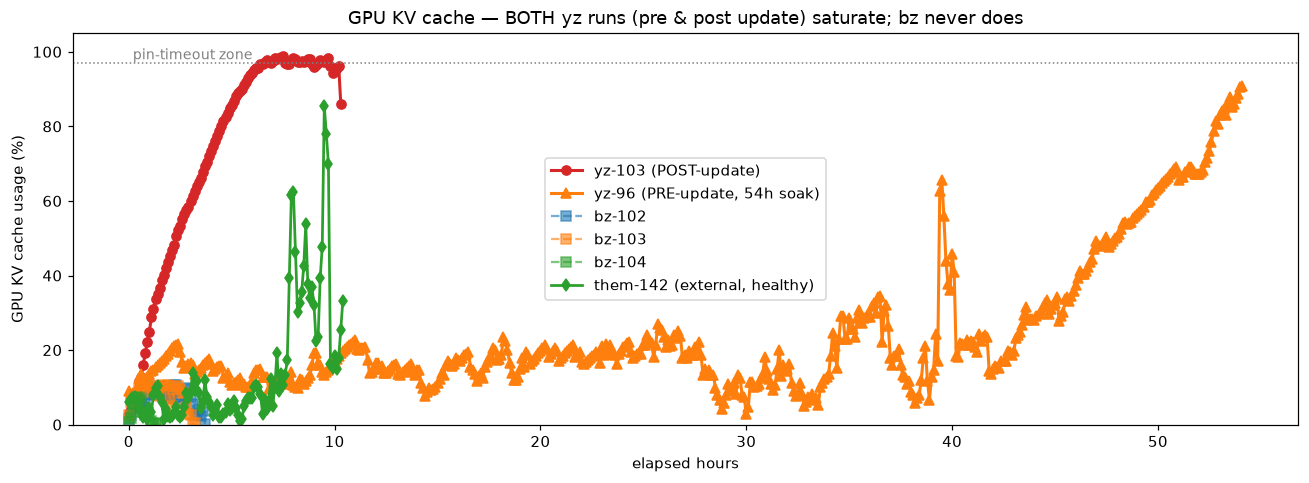

In [36]:
def kv_series(vdir):
    df = kv_trend(vdir)   # from section 8
    if df.empty: return None
    g = df.copy(); g["hb"] = g["h"].round(1)
    return g.groupby("hb")["kv"].mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
s = kv_series(E103); ax.plot(s.index, s.values, "o-", color="tab:red", lw=2, label="yz-103 (POST-update)")
s = kv_series(E96);  ax.plot(s.index, s.values, "^-", color="tab:orange", lw=2, label="yz-96 (PRE-update, 54h soak)")
for r in BZ_RUNS:
    s = kv_series(os.path.join(BZ_BASE, r))
    if s is not None: ax.plot(s.index, s.values, "s--", alpha=0.6, label=f"bz-{r}")
# them-142 (yz baseline): KV from the external Prometheus scrape (metrics.jsonl)
d142 = kv_series_metrics(E102)
if d142 is not None and not d142.empty:
    g = d142.copy(); g["hb"] = g["h"].round(1); s = g.groupby("hb")["kv"].mean()
    ax.plot(s.index, s.values, "d-", color="tab:green", lw=1.8, label="them-142 (external, healthy)")
ax.axhline(97, color="gray", ls=":", lw=1); ax.text(0.2, 98, "pin-timeout zone", color="gray", fontsize=9)
ax.set_xlabel("elapsed hours"); ax.set_ylabel("GPU KV cache usage (%)")
ax.set_title("GPU KV cache — BOTH yz runs (pre & post update) saturate; bz never does")
ax.legend(); ax.set_ylim(0, 105)
plt.tight_layout(); plt.show()

### 9b. Second reference baseline (exp 95 = 142) — healthy, like exp 102

Confirms the 142 reference stays healthy across independent captures; only our yz stack degrades.

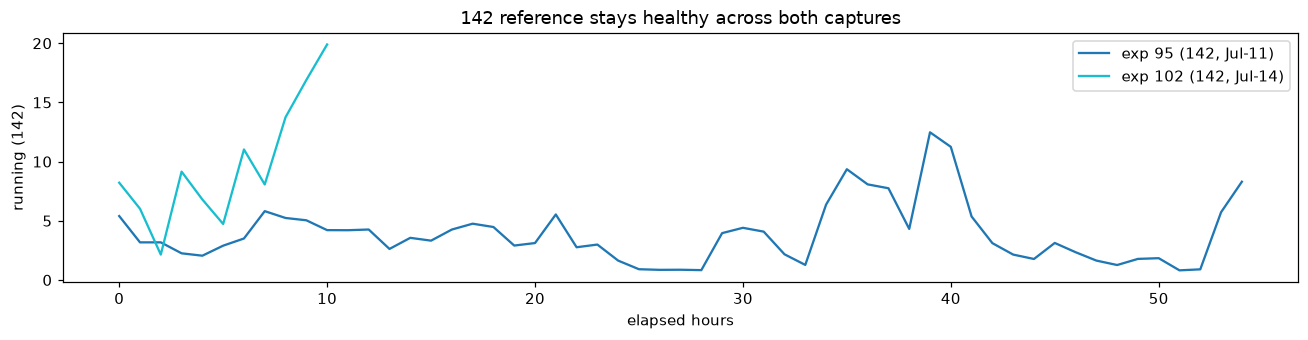

In [37]:
def them_running(metrics_path):
    rows = []
    with open(metrics_path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try: d = json.loads(line)
            except Exception: continue
            t = to_dt(d["ts"]); run = 0.0
            for sm in d.get("samples", []):
                i = sm.get("instance", "")
                if i.startswith("7.150.2.142") and (i.endswith(":0") or i.endswith(":1")):
                    run += sm.get("requests_running") or 0
            rows.append((t, run))
    df = pd.DataFrame(rows, columns=["ts","them_run"]).set_index("ts")
    if not df.empty: df["h"] = (df.index - df.index[0]).total_seconds()/3600.0
    return df

t95 = them_running(os.path.join(E95, "metrics.jsonl"))
t102 = them_running(os.path.join(E102, "metrics.jsonl"))
fig, ax = plt.subplots(figsize=(12, 3.2))
for df, lab, c in [(t95,"exp 95 (142, Jul-11)","tab:blue"), (t102,"exp 102 (142, Jul-14)","tab:cyan")]:
    if df.empty: continue
    s = df.set_index("h")["them_run"].groupby(df["h"].round(0).values).mean()
    ax.plot(s.index, s.values, "-", color=c, label=lab)
ax.set_xlabel("elapsed hours"); ax.set_ylabel("running (142)")
ax.set_title("142 reference stays healthy across both captures"); ax.legend()
plt.tight_layout(); plt.show()

### 9c. Final verdict (with 95/96 included)

| run | stack | when | KV max | pin timeouts | outcome |
|---|---|---|---|---|---|
| exp 96 | **yz (ours)** | Jul-11 → 14, **pre-update** | ~99.8% | **880** | degrades (KV-saturation soak) |
| run 103 | **yz (ours)** | Jul-14/15, post-update | ~100% | **2,792** | degrades (KV-saturation soak) |
| exp 102 / 95 | 142 (them) | Jul-14 / Jul-11 | n/a | 0 | healthy throughout |
| bz 102/103/104 | bz (ours, claude) | Jul-14 | ~6–11% | 0 | healthy (never saturates) |

- The **same failure appears on yz before the observability update ever shipped** (exp 96),
  so the update is exonerated as the cause.
- The trigger is consistent everywhere: **GPU KV cache driven to ~100%** (large-prompt / long
  saturated soak) → heavy LMCache host-staging → **P2P pin deadlock**. Whenever KV stays low
  (bz, and the 142 reference), there are **zero** pin timeouts.
- Fix direction stays the same: keep GPU KV off saturation (smaller `max_num_seqs` won't help;
  cap prompt/context or raise effective KV headroom), harden/lower the LMCache pin timeout, and
  test P2P host-staging under a controlled KV-saturating soak.

---
## 10. Prefix-cache hit-rate drop vs GPU KV saturation — 102 (them) & 103 (ours)

The core "prefix drop": as the GPU KV cache fills, there is no room to retain prefix blocks, so
the **prefix-cache hit rate collapses**. Below, for **both** captures, GPU KV usage (red, left axis)
is overlaid with the prefix-cache hit rate (blue, right axis) on a shared elapsed-hours axis.

- **102 = them (142):** KV only spikes transiently and drains, so the prefix hit rate holds up.
- **103 = ours (yz):** KV climbs to ~100% and stays there → prefix hit rate drops.

Sources: 142 KV and both prefix hit rates come from `metrics.jsonl` (`kv_cache_usage_perc`,
`prefix_cache_hit_rate`, 0–1 fractions ×100). Our (103) KV comes from `vllm.log` (our engines don't
export `kv_cache_usage_perc` on the yz scrape). Our engines are keyed by IP
(`7.150.6.33`, `7.150.1.218`); 142 by `7.150.2.142`.

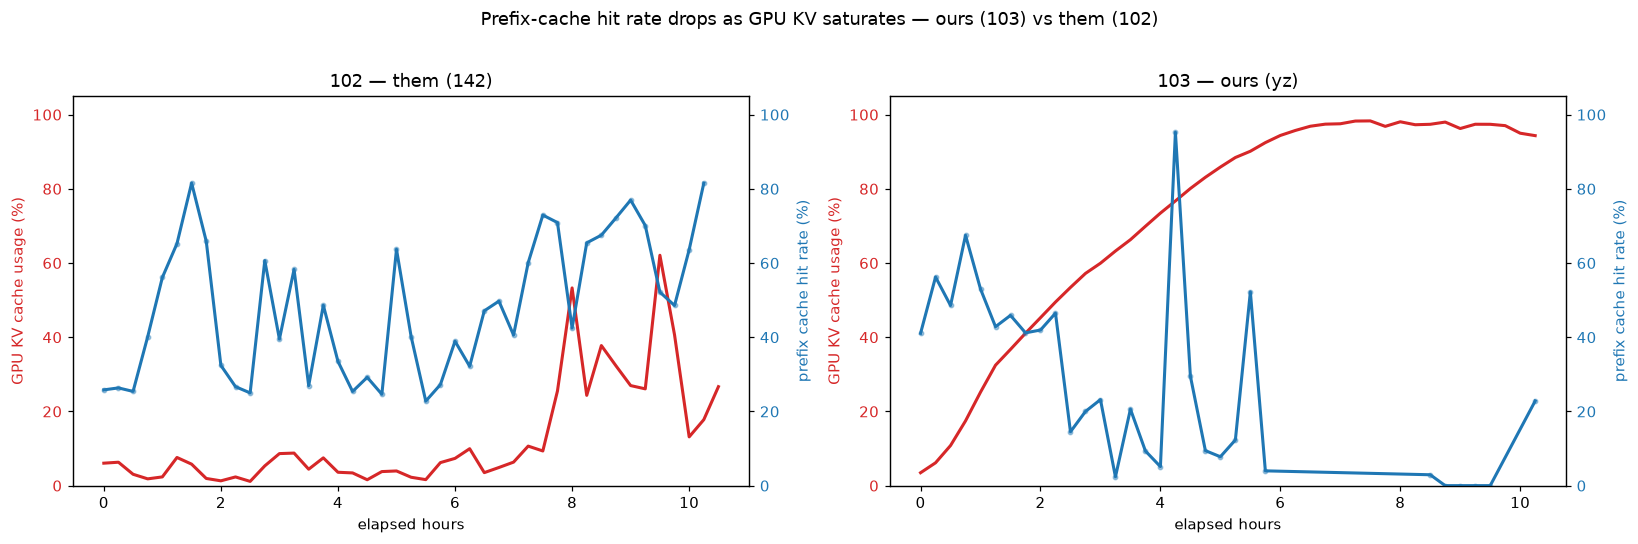

102 them-142    KV%%: early=4.5 -> late=29.0   |   prefix hit%%: early=44.9 -> late=63.2
103 ours-yz     KV%%: early=35.9 -> late=97.1   |   prefix hit%%: early=48.5 -> late=10.2


In [ ]:
def _metrics_series(exp_dir, field, prefixes, scale=1.0, agg="mean"):
    recs = []
    mp = os.path.join(exp_dir, "metrics.jsonl")
    if not os.path.exists(mp): return None
    for line in open(mp):
        line = line.strip()
        if not line: continue
        try: d = json.loads(line)
        except Exception: continue
        vals = [float(s[field]) * scale for s in d.get("samples", [])
                if any(s.get("instance","").startswith(p) for p in prefixes)
                and (s.get("instance","").endswith(":0") or s.get("instance","").endswith(":1"))
                and s.get(field) is not None]
        if vals:
            recs.append((to_dt(d["ts"]), (sum(vals)/len(vals)) if agg=="mean" else max(vals)))
    df = pd.DataFrame(recs, columns=["ts","v"]).set_index("ts").sort_index()
    if not df.empty: df["h"] = (df.index - df.index[0]).total_seconds()/3600.0
    return df

def _win(df, col="v", bin_h=0.25):
    if df is None or df.empty: return None
    g = df.copy(); g["hb"] = (g["h"]/bin_h).round()*bin_h
    return g.groupby("hb")[col].mean()

# KV usage (%)
kv102 = _win(_metrics_series(E102, "kv_cache_usage_perc", ["7.150.2.142"], scale=100.0))
_kv103_df = kv_trend(E103)                     # from vllm.log (already %)
kv103 = _win(_kv103_df.rename(columns={"kv":"v"})) if not _kv103_df.empty else None
# prefix-cache hit rate (%)
pf102 = _win(_metrics_series(E102, "prefix_cache_hit_rate", ["7.150.2.142"], scale=100.0))
pf103 = _win(_metrics_series(E103, "prefix_cache_hit_rate", ["7.150.6.33","7.150.1.218"], scale=100.0))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, (title, kv, pf) in zip(axes, [("102 — them (142)", kv102, pf102),
                                      ("103 — ours (yz)",  kv103, pf103)]):
    if kv is not None:
        ax.plot(kv.index, kv.values, color="tab:red", lw=2, label="GPU KV usage %")
    ax.set_ylabel("GPU KV cache usage (%)", color="tab:red"); ax.set_ylim(0, 105)
    ax.tick_params(axis="y", labelcolor="tab:red"); ax.set_xlabel("elapsed hours"); ax.set_title(title)
    ax2 = ax.twinx()
    if pf is not None:
        ax2.plot(pf.index, pf.values, color="tab:blue", lw=2, label="prefix hit rate %")
        ax2.scatter(pf.index, pf.values, s=8, color="tab:blue", alpha=0.4)
    ax2.set_ylabel("prefix cache hit rate (%)", color="tab:blue"); ax2.set_ylim(0, 105)
    ax2.tick_params(axis="y", labelcolor="tab:blue")
fig.suptitle("Prefix-cache hit rate drops as GPU KV saturates — ours (103) vs them (102)", y=1.02)
plt.tight_layout(); plt.show()

# quantify the drop: early vs late (first vs last third of each series)
def early_late(s):
    if s is None or len(s) < 6: return (None, None)
    n = len(s)//3
    return (round(s.iloc[:n].mean(),1), round(s.iloc[-n:].mean(),1))
for name, kv, pf in [("102 them-142", kv102, pf102), ("103 ours-yz", kv103, pf103)]:
    ke, kl = early_late(kv); pe, pl = early_late(pf)
    print(f"{name:14s}  KV%%: early={ke} -> late={kl}   |   prefix hit%%: early={pe} -> late={pl}")